In [1]:
import scanpy as sc
import anndata as ann
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors
import seaborn as sb

import os

# Define the path to the directory you want to change to
new_directory = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/UPDATED_COMBINED_ANALYSIS'

# Use os.chdir() to change the working directory
os.chdir(new_directory)

In [2]:
from upsetplot import plot
from upsetplot import from_contents
from upsetplot import UpSet

In [3]:
save_dir = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI//DEG_analysis/NEW_OL_DEG/UPDATED_COMBINED_ANALYSIS/'

# LPC treated samples

In [4]:
OPC_demyel = pd.read_csv('./files/LPC_OPC_early_voom_wqw_UPDATED.csv', index_col=None)
OPC_demyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
OPC_demyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
OPC_demyel.shape

(8073, 7)

In [5]:
#SKIP
OPC_remyel = pd.read_csv('./files/LPC_OPC_remyel_voom.csv', index_col=None)
OPC_remyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
OPC_remyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
OPC_remyel.shape

(6812, 7)

In [6]:
LPC_demyel = pd.read_csv('./files/LPC_demyel_MOL_all_voom_wqw_UPDATED.csv', index_col=None)
LPC_demyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_demyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_demyel.shape

(11516, 7)

In [7]:
LPC_remyel = pd.read_csv('./files/LPC_remyel_MOL_all_voom_wqw_UPDATED.csv', index_col=None)
LPC_remyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_remyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_remyel.shape

(13049, 7)

In [8]:
# Specify the gene you want to search
gene_of_interest = "Ifit3b"  # replace with your gene

# Filter the DataFrame for that gene
gene_row = LPC_remyel[LPC_remyel['gene'] == gene_of_interest]

# Display the result
print(gene_row)

Empty DataFrame
Columns: [gene, logFC, AveExpr, t, Pvalue, Padj, B]
Index: []


In [9]:
Cupr_demyel = pd.read_csv('./files/Cupr_demyel_MOL_all_voom_wqw_UPDATED.csv', index_col=None)
Cupr_demyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
Cupr_demyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
Cupr_demyel.shape

(10536, 7)

In [10]:
#SKIP
Cupr_remyel = pd.read_csv('./files/Cupr_remyel_MOL_shen_voom.csv', index_col=None)
Cupr_remyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
Cupr_remyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
Cupr_remyel.shape

(8749, 7)

In [11]:
OPC_demyel.head()

,gene,logFC,AveExpr,t,Pvalue,Padj,B
0,C4b,4.969368,5.166741,17.924959,1.262250e-11,1.019015e-07,15.945492
1,Serpina3n,5.016019,5.574485,16.228265,5.319566e-11,1.760439e-07,15.141963
2,Dbndd2,4.443583,4.783055,15.996605,6.541952e-11,1.760439e-07,14.739335
3,Col16a1,2.322603,5.886618,15.566910,9.670652e-11,1.951779e-07,14.773279
4,Unc13c,-2.726557,6.612704,-13.557444,6.896989e-10,9.751585e-07,12.696653


In [12]:
# Filter for upregulated genes
OPC_de_up = OPC_demyel[(OPC_demyel.Padj < 0.05) & (OPC_demyel.logFC >= 0.585)]
print(OPC_de_up.shape)

# Filter for downregulated genes
OPC_de_down = OPC_demyel[(OPC_demyel.Padj < 0.05) & (OPC_demyel.logFC <= -0.585)]
print(OPC_de_down.shape)

(553, 7)
(1012, 7)


In [13]:
# Filter for upregulated genes
OPC_re_up = OPC_remyel[(OPC_remyel.Padj < 0.05) & (OPC_remyel.logFC >= 0.585)]
print(OPC_re_up.shape)

# Filter for downregulated genes
OPC_re_down = OPC_remyel[(OPC_remyel.Padj < 0.05) & (OPC_remyel.logFC <= -0.585)]
print(OPC_re_down.shape)

(5, 7)
(0, 7)


In [14]:
# Filter for upregulated genes
LPC_de_up = LPC_demyel[(LPC_demyel.Padj < 0.05) & (LPC_demyel.logFC >= 0.585)]
print(LPC_de_up.shape)

# Filter for downregulated genes
LPC_de_down = LPC_demyel[(LPC_demyel.Padj < 0.05) & (LPC_demyel.logFC <= -0.585)]
print(LPC_de_down.shape)

(553, 7)
(349, 7)


In [15]:
# Filter for upregulated genes
LPC_re_up = LPC_remyel[(LPC_remyel.Padj < 0.05) & (LPC_remyel.logFC >= 0.585)]
print(LPC_re_up.shape)

# Filter for downregulated genes
LPC_re_down = LPC_remyel[(LPC_remyel.Padj < 0.05) & (LPC_remyel.logFC <= -0.585)]
print(LPC_re_down.shape)

(590, 7)
(454, 7)


In [16]:
# Filter for upregulated genes
Cupr_de_up = Cupr_demyel[(Cupr_demyel.Padj < 0.05) & (Cupr_demyel.logFC >= 0.585)]
print(Cupr_de_up.shape)

# Filter for downregulated genes
Cupr_de_down = Cupr_demyel[(Cupr_demyel.Padj < 0.05) & (Cupr_demyel.logFC <= -0.585)]
print(Cupr_de_down.shape)

(2364, 7)
(1866, 7)


In [17]:
# Filter for upregulated genes
Cupr_re_up = Cupr_remyel[(Cupr_remyel.Padj < 0.05) & (Cupr_remyel.logFC >= 0.585)]
print(Cupr_re_up.shape)

# Filter for downregulated genes
Cupr_re_down = Cupr_remyel[(Cupr_remyel.Padj < 0.05) & (Cupr_remyel.logFC <= -0.585)]
print(Cupr_re_down.shape)

(26, 7)
(531, 7)


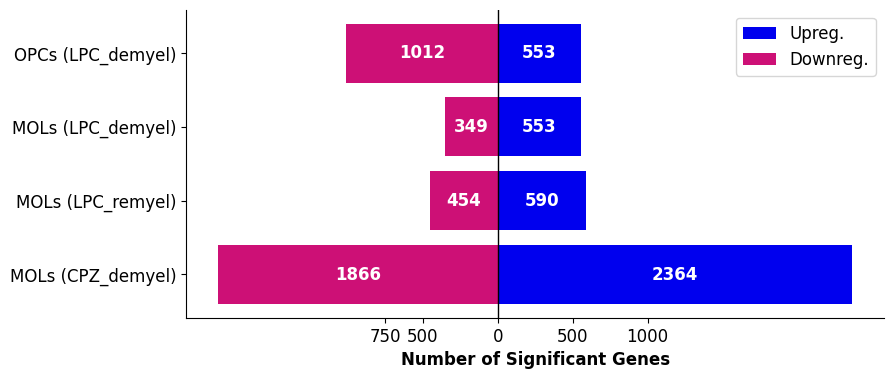

In [18]:
# Data
conditions = ["OPCs (LPC_demyel)", "MOLs (LPC_demyel)", "MOLs (LPC_remyel)", "MOLs (CPZ_demyel)"]

up_genes = np.array([553, 553, 590, 2364])
down_genes = np.array([-1012, -349, -454, -1866])  # negative for left alignment

# Reverse all data
conditions = conditions[::-1]
up_genes = up_genes[::-1]
down_genes = down_genes[::-1]

# Bar width (increased) and figure size (shorter height)
bar_width = 0.8
fig, ax = plt.subplots(figsize=(9, 4))  # Reduce height to save space

# Plot downregulated genes (left side)
bars_down = ax.barh(
    conditions,
    down_genes,
    color='#CD1076',
    label="Downregulated Genes",
    height=bar_width
)

# Plot upregulated genes (right side)
bars_up = ax.barh(
    conditions,
    up_genes,
    color='#0000EE',
    label="Upregulated Genes",
    height=bar_width
)

# Add number labels (always white)
for bar, value in zip(bars_down, down_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(abs(value)),
        ha='center',
        va='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

for bar, value in zip(bars_up, up_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        ha='center',
        va='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

# Formatting
ax.set_yticks(np.arange(len(conditions)))
ax.set_yticklabels(conditions, fontsize=12)
ax.set_xlabel("Number of Significant Genes", fontsize=12, fontweight='bold')

# Adjust x-axis to show only -1000, -500, 0, 500, 1000
ax.set_xticks([-750, -500, 0, 500, 1000])
ax.set_xticklabels([750, 500, 0, 500, 1000], fontsize=12)

ax.axvline(0, color='black', linewidth=1)  # Zero line

# Remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Remove grid lines
ax.grid(False)

# Properly reorder the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    [handles[1], handles[0]],
    ["Upreg.", "Downreg."],
    loc="upper right",
    fontsize=12
)

# Save the plot
plt.savefig("./figures/mmMOL_OPC_DEG_bar_chart_bulked.png", dpi=300, bbox_inches='tight')  # Save with high quality

# Show plot
plt.show()

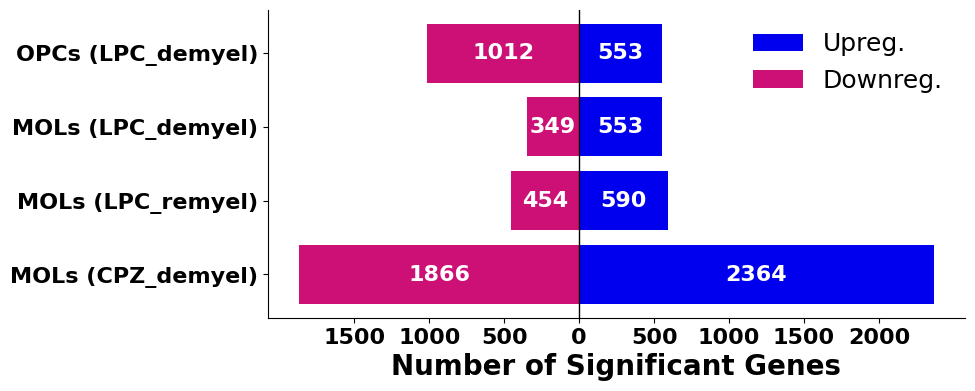

In [19]:
# Data
conditions = ["OPCs (LPC_demyel)", "MOLs (LPC_demyel)", "MOLs (LPC_remyel)", "MOLs (CPZ_demyel)"]

up_genes = np.array([553, 553, 590, 2364])
down_genes = np.array([-1012, -349, -454, -1866])  # negative for left alignment

# Reverse all data
conditions = conditions[::-1]
up_genes = up_genes[::-1]
down_genes = down_genes[::-1]

# Bar width (increased) and figure size (shorter height)
bar_width = 0.8
fig, ax = plt.subplots(figsize=(9, 4))  # Reduce height to save space

# Plot downregulated genes (left side)
bars_down = ax.barh(
    conditions,
    down_genes,
    color='#CD1076',
    label="Downregulated Genes",
    height=bar_width
)

# Plot upregulated genes (right side)
bars_up = ax.barh(
    conditions,
    up_genes,
    color='#0000EE',
    label="Upregulated Genes",
    height=bar_width
)

# Add number labels (always white)
for bar, value in zip(bars_down, down_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(abs(value)),
        ha='center',
        va='center',
        color='white',
        fontsize=16,           # bigger number labels
        fontweight='bold'
    )

for bar, value in zip(bars_up, up_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        ha='center',
        va='center',
        color='white',
        fontsize=16,           # bigger number labels
        fontweight='bold'
    )

# Formatting axis labels and ticks
ax.set_yticks(np.arange(len(conditions)))
ax.set_yticklabels(conditions, fontsize=16, fontweight='bold')  # Bigger Y tick labels
ax.set_xlabel("Number of Significant Genes", fontsize=20, fontweight='bold')  # Bigger X label

# Adjust x-axis to show only -1000, -500, 0, 500, 1000
ax.set_xticks([-1500, -1000, -500, 0, 500, 1000, 1500, 2000])
ax.set_xticklabels([1500, 1000, 500, 0, 500, 1000, 1500, 2000],
                   fontsize=16, fontweight='bold')

ax.axvline(0, color='black', linewidth=1)  # Zero line

# Remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Remove grid lines
ax.grid(False)

# Properly reorder the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    [handles[1], handles[0]],
    ["Upreg.", "Downreg."],
    loc="upper right",
    fontsize=18,          # Bigger legend text
    frameon=False         # Cleaner look
)

# Save the plot
plt.savefig("./figures/mmMOL_OPC_DEG_bar_chart_bulked.png", dpi=300, bbox_inches='tight')  # Save with high quality

# Show plot
plt.show()

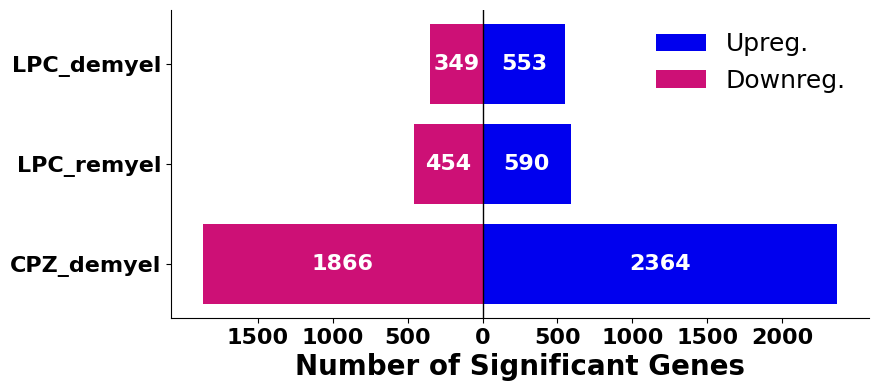

In [21]:
# Data
conditions = ["LPC_demyel", "LPC_remyel", "CPZ_demyel"]

up_genes = np.array([553, 590, 2364])
down_genes = np.array([-349, -454, -1866])  # negative for left alignment

# Reverse all data
conditions = conditions[::-1]
up_genes = up_genes[::-1]
down_genes = down_genes[::-1]

# Bar width (increased) and figure size (shorter height)
bar_width = 0.8
fig, ax = plt.subplots(figsize=(9, 4))  # Reduce height to save space

# Plot downregulated genes (left side)
bars_down = ax.barh(
    conditions,
    down_genes,
    color='#CD1076',
    label="Downregulated Genes",
    height=bar_width
)

# Plot upregulated genes (right side)
bars_up = ax.barh(
    conditions,
    up_genes,
    color='#0000EE',
    label="Upregulated Genes",
    height=bar_width
)

# Add number labels (always white)
for bar, value in zip(bars_down, down_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(abs(value)),
        ha='center',
        va='center',
        color='white',
        fontsize=16,           # bigger number labels
        fontweight='bold'
    )

for bar, value in zip(bars_up, up_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        ha='center',
        va='center',
        color='white',
        fontsize=16,           # bigger number labels
        fontweight='bold'
    )

# Formatting axis labels and ticks
ax.set_yticks(np.arange(len(conditions)))
ax.set_yticklabels(conditions, fontsize=16, fontweight='bold')  # Bigger Y tick labels
ax.set_xlabel("Number of Significant Genes", fontsize=20, fontweight='bold')  # Bigger X label

# Adjust x-axis to show only -1000, -500, 0, 500, 1000
ax.set_xticks([-1500, -1000, -500, 0, 500, 1000, 1500, 2000])
ax.set_xticklabels([1500, 1000, 500, 0, 500, 1000, 1500, 2000],
                   fontsize=16, fontweight='bold')

ax.axvline(0, color='black', linewidth=1)  # Zero line

# Remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Remove grid lines
ax.grid(False)

# Properly reorder the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    [handles[1], handles[0]],
    ["Upreg.", "Downreg."],
    loc="upper right",
    fontsize=18,          # Bigger legend text
    frameon=False         # Cleaner look
)

# Save the plot
plt.savefig("./figures/mmMOL_only_DEG_bar_chart_bulked.png", dpi=300, bbox_inches='tight')  # Save with high quality

# Show plot
plt.show()

# SKIP Upset plots- OPCs and DAO DEGs

In [26]:
from upsetplot import plot
from upsetplot import from_contents
from upsetplot import UpSet

In [19]:
OPC_de_up

,gene,logFC,AveExpr,t,Pvalue,Padj,B
0,C4b,4.969368,5.166741,17.924959,1.262250e-11,1.019015e-07,15.945492
1,Serpina3n,5.016019,5.574485,16.228265,5.319566e-11,1.760439e-07,15.141963
2,Dbndd2,4.443583,4.783055,15.996605,6.541952e-11,1.760439e-07,14.739335
3,Col16a1,2.322603,5.886618,15.566910,9.670652e-11,1.951779e-07,14.773279
5,Josd2,3.069189,4.524543,13.509795,7.247555e-10,9.751585e-07,12.741819
...,...,...,...,...,...,...,...
1852,Snrpe,0.838071,6.117254,2.878805,1.137124e-02,4.951820e-02,-3.405094
1854,Rpl28,1.113905,7.301860,2.876458,1.142566e-02,4.972472e-02,-3.483847
1864,Edrf1,0.649942,4.692564,2.871790,1.153467e-02,4.992995e-02,-3.300980
1866,Rps12,1.170718,7.160993,2.871130,1.155015e-02,4.994324e-02,-3.495888


In [18]:
# Create gene lists from the dfs:
genes_OPC_de_up = OPC_de_up['gene'].tolist()
genes_OPC_re_up = OPC_re_up['gene'].tolist()
genes_LPC_de_up = LPC_de_up['gene'].tolist()
genes_LPC_re_up = LPC_re_up['gene'].tolist()
genes_Cupr_de_up = Cupr_de_up['gene'].tolist()
genes_Cupr_re_up = Cupr_re_up['gene'].tolist()

In [19]:
# Create DataFrames for each gene list
# Define the function to create a DataFrame
def create_gene_df(genes_list, column_name):
    return pd.DataFrame(genes_list, columns=[column_name])

# Create DataFrames for each gene list
OPC_de_up_df = create_gene_df(genes_OPC_de_up, 'OPC_de_up')
OPC_re_up_df = create_gene_df(genes_OPC_re_up, 'OPC_re_up')
LPC_de_up_df = create_gene_df(genes_LPC_de_up, 'LPC_de_up')
LPC_re_up_df = create_gene_df(genes_LPC_re_up, 'LPC_re_up')
Cupr_de_up_df = create_gene_df(genes_Cupr_de_up, 'Cupr_de_up')
Cupr_re_up_df = create_gene_df(genes_Cupr_re_up, 'Cupr_re_up')

In [20]:
# Create DataFrames for each gene list using the new gene lists
OPC_de_up_df = pd.DataFrame({'OPC_de_up': True, 'Name': genes_OPC_de_up})
OPC_re_up_df = pd.DataFrame({'OPC_re_up': True, 'Name': genes_OPC_re_up})
LPC_de_up_df = pd.DataFrame({'LPC_de_up': True, 'Name': genes_LPC_de_up})
LPC_re_up_df = pd.DataFrame({'LPC_re_up': True, 'Name': genes_LPC_re_up})
Cupr_de_up_df = pd.DataFrame({'Cupr_de_up': True, 'Name': genes_Cupr_de_up})
Cupr_re_up_df = pd.DataFrame({'Cupr_re_up': True, 'Name': genes_Cupr_re_up})

In [24]:
# Merge all the DataFrames hierarchically
up_df = OPC_de_up_df.merge(
    OPC_re_up_df.merge(
        LPC_de_up_df.merge(
            LPC_re_up_df.merge(
                Cupr_de_up_df.merge(
                    Cupr_re_up_df, on='Name', how='outer'
                ), on='Name', how='outer'
            ), on='Name', how='outer'
        ), on='Name', how='outer'
    ), on='Name', how='outer'
)

# Replace NaN with False
up_df = up_df.fillna(False)

# Set index for the data frame
up_df_plot = up_df.set_index([
    'OPC_de_up', 'OPC_re_up', 'LPC_de_up', 'LPC_re_up', 'Cupr_de_up', 'Cupr_re_up'
])

# Print the merged DataFrame
print("Upregulated genes DataFrame:")
print(up_df_plot)

Upregulated genes DataFrame:
                                                                        Name
OPC_de_up OPC_re_up LPC_de_up LPC_re_up Cupr_de_up Cupr_re_up               
False     False     False     False     True       False       0610009B22Rik
                                                   False       0610010K14Rik
                    True      False     False      False       0610012G03Rik
True      False     False     True      False      False       1110008P14Rik
False     False     False     False     True       False       1110012L19Rik
...                                                                      ...
                              True      True       False              Zswim3
                              False     True       False              Zswim4
                                                   False              Zswim7
                                                   False               Zwint
                                               

/tmp/2168548.1.long/ipykernel_3988282/1404460635.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  up_df = up_df.fillna(False)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

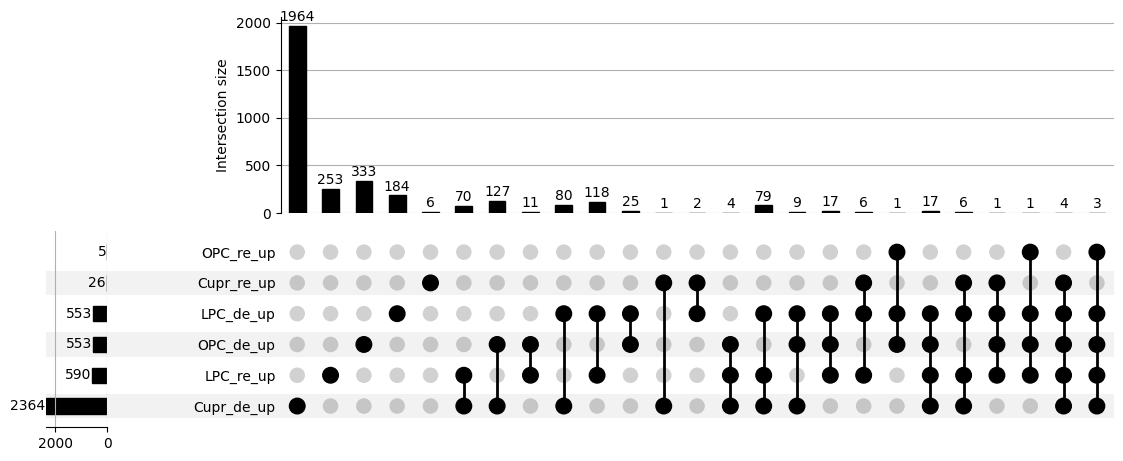

In [25]:
upset_plot = UpSet(up_df_plot, subset_size='count', show_counts=True,).plot()

In [26]:
# Dictionary to map old index names to new index names
index_name_map = {
    'OPC_de_up': 'LPC_OPC_demyel',
    'OPC_re_up': 'LPC_OPC_remyel',
    'LPC_de_up': 'LPC_MOL_demyel',
    'LPC_re_up': 'LPC_MOL_remyel',
    'Cupr_de_up': 'Cupr_MOL_demyel',
    'Cupr_re_up': 'Cupr_MOL_remyel'
}

# Rename the index levels using the dictionary
up_df_plot.index = up_df_plot.index.rename(index_name_map)

print("Updated Upregulated genes DataFrame:")
print(up_df_plot)

Updated Upregulated genes DataFrame:
                                                                                                      Name
LPC_OPC_demyel LPC_OPC_remyel LPC_MOL_demyel LPC_MOL_remyel Cupr_MOL_demyel Cupr_MOL_remyel               
False          False          False          False          True            False            0610009B22Rik
                                                                            False            0610010K14Rik
                              True           False          False           False            0610012G03Rik
True           False          False          True           False           False            1110008P14Rik
False          False          False          False          True            False            1110012L19Rik
...                                                                                                    ...
                                             True           True            False                   Zswim3


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

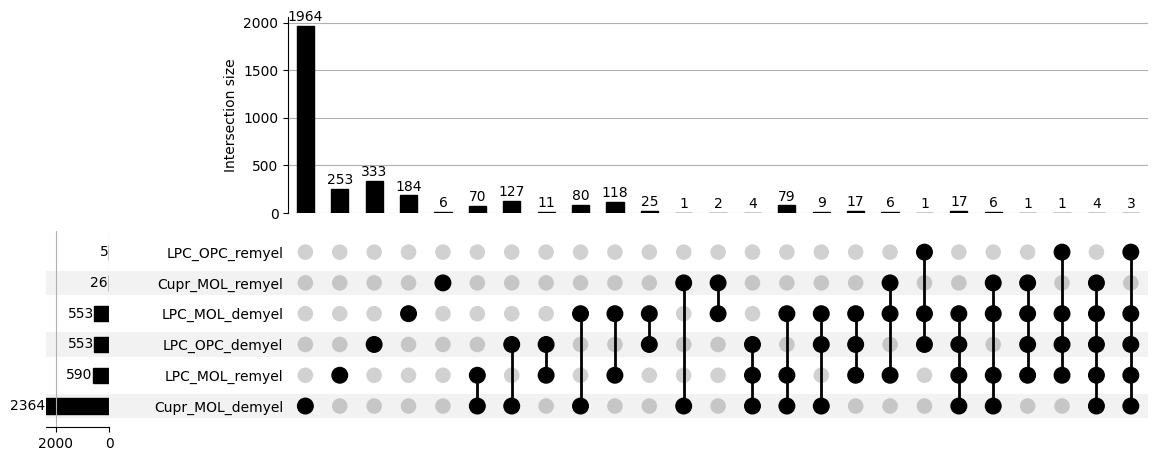

In [27]:
upset_plot = UpSet(up_df_plot, subset_size='count', show_counts=True,).plot()

# Save the plot as PDF
#plt.savefig('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/UPDATED_NOMENCLATURE/figures/upset_up_ALL.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [28]:
# Merge all the DataFrames hierarchically
up_df = OPC_de_up_df.merge(
    LPC_de_up_df.merge(
        LPC_re_up_df.merge(
            Cupr_de_up_df, on='Name', how='outer'
        ), on='Name', how='outer'
    ), on='Name', how='outer'
)

# Replace NaN with False
up_df = up_df.fillna(False)

# Set index for the data frame
up_df_plot = up_df.set_index([
    'OPC_de_up', 'LPC_de_up', 'LPC_re_up', 'Cupr_de_up'
])

# Print the merged DataFrame
print("Upregulated genes DataFrame:")
print(up_df_plot)

Upregulated genes DataFrame:
                                                   Name
OPC_de_up LPC_de_up LPC_re_up Cupr_de_up               
False     False     False     True        0610009B22Rik
                              True        0610010K14Rik
          True      False     False       0610012G03Rik
True      False     True      False       1110008P14Rik
False     False     False     True        1110012L19Rik
...                                                 ...
                    True      True               Zswim3
                    False     True               Zswim4
                              True               Zswim7
                              True                Zwint
                              True                  Zyx

[3316 rows x 1 columns]


/tmp/2168548.1.long/ipykernel_3988282/3677752216.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  up_df = up_df.fillna(False)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

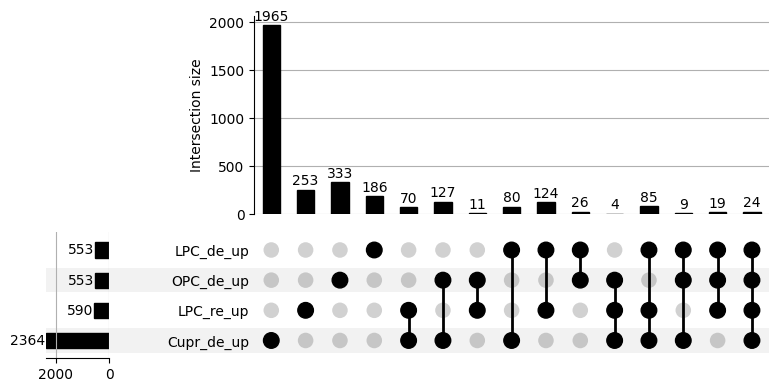

In [29]:
upset_plot = UpSet(up_df_plot, subset_size='count', show_counts=True,).plot()

In [30]:
# Merge all the DataFrames hierarchically
up_df = LPC_de_up_df.merge(
    LPC_re_up_df.merge(
        Cupr_de_up_df, on='Name', how='outer'
    ), on='Name', how='outer'
)

# Replace NaN with False
up_df = up_df.fillna(False)

# Set index for the data frame
up_df_plot = up_df.set_index([
    'LPC_de_up', 'LPC_re_up', 'Cupr_de_up'
])

# Print the merged DataFrame
print("Upregulated genes DataFrame:")
print(up_df_plot)

Upregulated genes DataFrame:
                                         Name
LPC_de_up LPC_re_up Cupr_de_up               
False     False     True        0610009B22Rik
                    True        0610010K14Rik
True      False     False       0610012G03Rik
False     True      False       1110008P14Rik
          False     True        1110012L19Rik
...                                       ...
          True      True               Zswim3
          False     True               Zswim4
                    True               Zswim7
                    True                Zwint
                    True                  Zyx

[2983 rows x 1 columns]


/tmp/2168548.1.long/ipykernel_3988282/2016814767.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  up_df = up_df.fillna(False)


# Overlap Up MOL ONLY

In [ ]:
## IMPORTANT FILTER FOR GENES TESTING IN ALL CONDITIONS

genes_all_conditions = set(LPC_demyel['gene']) & \
                       set(LPC_remyel['gene']) & \
                       set(Cupr_demyel['gene'])

len(genes_all_conditions)

In [ ]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all_conditions)]

# Apply filtering to each DEG DataFrame
LPC_demyel_shared = filter_genes(LPC_demyel)
LPC_remyel_shared = filter_genes(LPC_remyel)
Cupr_demyel_shared = filter_genes(Cupr_demyel)

print(LPC_demyel_shared.shape)
print(LPC_remyel_shared.shape)
print(Cupr_demyel_shared.shape)

In [ ]:
# Filter for upregulated genes
LPC_de_up = LPC_demyel_shared[(LPC_demyel_shared.Padj < 0.05) & (LPC_demyel_shared.logFC >= 0.585)]
print(LPC_de_up.shape)

# Filter for downregulated genes
LPC_de_down = LPC_demyel_shared[(LPC_demyel_shared.Padj < 0.05) & (LPC_demyel_shared.logFC <= -0.585)]
print(LPC_de_down.shape)

In [ ]:
# Filter for upregulated genes
LPC_re_up = LPC_remyel_shared[(LPC_remyel_shared.Padj < 0.05) & (LPC_remyel_shared.logFC >= 0.585)]
print(LPC_re_up.shape)

# Filter for downregulated genes
LPC_re_down = LPC_remyel_shared[(LPC_remyel_shared.Padj < 0.05) & (LPC_remyel_shared.logFC <= -0.585)]
print(LPC_re_down.shape)

In [ ]:
# Filter for upregulated genes
Cupr_de_up = Cupr_demyel[(Cupr_demyel.Padj < 0.05) & (Cupr_demyel.logFC >= 0.585)]
print(Cupr_de_up.shape)

# Filter for downregulated genes
Cupr_de_down = Cupr_demyel[(Cupr_demyel.Padj < 0.05) & (Cupr_demyel.logFC <= -0.585)]
print(Cupr_de_down.shape)

In [20]:
# Create gene lists from the new DataFrames
genes_LPC_de_up = LPC_de_up['gene'].tolist()
genes_LPC_re_up = LPC_re_up['gene'].tolist()
genes_Cupr_de_up = Cupr_de_up['gene'].tolist()

# Define a function to create a DataFrame with a 'Name' column and a specific label
def create_gene_df(genes_list, column_name):
    return pd.DataFrame({'Name': genes_list, column_name: True})

# Create DataFrames for each gene list with their respective labels
LPC_de_up_df = create_gene_df(genes_LPC_de_up, 'LPC_de_up')
LPC_re_up_df = create_gene_df(genes_LPC_re_up, 'LPC_re_up')
Cupr_de_up_df = create_gene_df(genes_Cupr_de_up, 'Cupr_de_up')

In [21]:
# Merge all the DataFrames hierarchically
up_df = LPC_de_up_df.merge(
    LPC_re_up_df.merge(
        Cupr_de_up_df, on='Name', how='outer'
    ), on='Name', how='outer'
)

# Replace NaN with False
up_df = up_df.fillna(False)

# Set index for the data frame
up_df_plot = up_df.set_index([
    'LPC_de_up', 'LPC_re_up', 'Cupr_de_up'
])

# Print the merged DataFrame
print("Upregulated genes DataFrame:")
print(up_df_plot)

Upregulated genes DataFrame:
                                         Name
LPC_de_up LPC_re_up Cupr_de_up               
False     False     True        0610009B22Rik
                    True        0610010K14Rik
True      False     False       0610012G03Rik
False     True      False       1110008P14Rik
          False     True        1110012L19Rik
...                                       ...
          True      True               Zswim3
          False     True               Zswim4
                    True               Zswim7
                    True                Zwint
                    True                  Zyx

[2983 rows x 1 columns]


/tmp/2310260.1.long/ipykernel_404292/2016814767.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  up_df = up_df.fillna(False)


In [22]:
# Dictionary to map old index names to new index names
index_name_map = {
    'LPC_de_up': 'LPC_demyel',
    'LPC_re_up': 'LPC_remyel',
    'Cupr_de_up': 'CPZ_demyel',
}

# Rename the index levels using the dictionary
up_df_plot.index = up_df_plot.index.rename(index_name_map)

print("Updated Upregulated genes DataFrame:")
print(up_df_plot)

Updated Upregulated genes DataFrame:
                                           Name
LPC_demyel LPC_remyel CPZ_demyel               
False      False      True        0610009B22Rik
                      True        0610010K14Rik
True       False      False       0610012G03Rik
False      True       False       1110008P14Rik
           False      True        1110012L19Rik
...                                         ...
           True       True               Zswim3
           False      True               Zswim4
                      True               Zswim7
                      True                Zwint
                      True                  Zyx

[2983 rows x 1 columns]


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

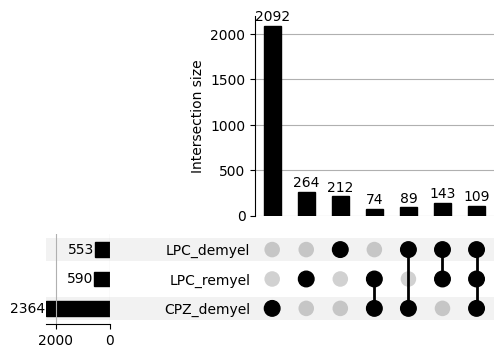

In [23]:
upset_plot = UpSet(up_df_plot, subset_size='count', show_counts=True,).plot()

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

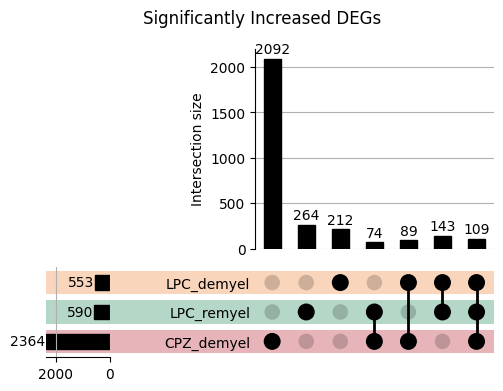

In [24]:
# Create UpSet plot
upset = UpSet(up_df_plot, subset_size='count', show_counts=True, facecolor="black", min_subset_size=10)

# Style the subsets
upset.style_categories(
    'LPC_demyel',
    shading_facecolor="#f9d5bb",
)

# Style the subsets
upset.style_categories(
    'LPC_remyel',
    shading_facecolor="#b4d7c7",
)

# Style the subsets
upset.style_categories(
    'CPZ_demyel',
    shading_facecolor="#e7b5b9",
)

# Plot the UpSet plot
upset.plot()
plt.suptitle("Significantly Increased DEGs")

# Save the plot as PDF
plt.savefig('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/UPDATED_COMBINED_ANALYSIS/figures/upset_plot_up_NEW_LABELS.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [25]:
# Create gene lists from the new DataFrames
genes_LPC_de_up = LPC_de_up['gene'].tolist()
genes_LPC_re_up = LPC_re_up['gene'].tolist()
genes_Cupr_de_up = Cupr_de_up['gene'].tolist()

In [26]:
# Convert lists to sets for upregulated genes
set_LPC_de_up = set(genes_LPC_de_up)
set_LPC_re_up = set(genes_LPC_re_up)
set_Cupr_de_up = set(genes_Cupr_de_up)

In [27]:
# Overlap all
overlap_all = set_LPC_de_up & set_LPC_re_up & set_Cupr_de_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 109
Overlapping upregulated genes: {'H2-D1', 'Srxn1', 'Cd44', 'Tsc22d1', 'AI506816', 'Aldh1l2', 'Bbc3', 'Vim', 'Adamtsl3', 'Nav3', 'Sema4f', 'Cpq', 'Cd151', 'Inppl1', 'Steap3', 'Tspan4', 'Vav3', 'Serpina3n', 'Arpc1b', 'Sox4', 'Astn2', 'Arhgap28', 'Tram2', 'Mmp11', 'Rras2', 'Gm13889', 'Rgs20', 'Tent5a', 'Grik3', 'Rab3b', 'B2m', 'Fgfrl1', 'Abca5', 'Rhoc', 'Chl1', 'Stat1', 'Phlda1', 'Pros1', 'Cebpd', 'Gadd45b', 'Mxra7', 'Cacng5', 'Myof', 'Me1', 'Nrcam', 'Plvap', 'Gadd45g', 'Inpp4a', 'Plpp3', 'Cmtm3', 'Rasip1', 'Fam124a', 'Lhfpl3', 'Cela1', 'Anxa2', 'Amotl1', 'Tspan6', 'Irf9', 'Ptprg', 'Vat1', 'Dner', 'Pdzrn4', 'Cav2', 'Slc16a2', 'C4b', 'Gm4285', 'Lbh', 'Smurf1', 'Lrrc49', 'Trim46', 'Sbno2', 'Stat3', 'Gpd1', 'Serp2', 'Tiparp', 'Faxc', 'Ntrk2', 'Mt2', 'Slc9a3r2', 'Parp12', 'Msra', 'Gm45338', 'Pcdh7', 'Syne2', 'Gadd45a', 'Masp1', 'Cdh13', 'Cacna1h', 'Scn8a', 'Tmsb10', 'Apba2', 'Klhl32', 'Thoc6', 'Eno2', 'Parp3', 'Klk6', 'Dscam', 'Tma16', 'Pvt1', 'Socs

In [28]:
# Overlap of upregulated genes
overlap_LPC = set_LPC_de_up & set_LPC_re_up - set_Cupr_de_up
print("Number of overlapping upregulated genes:", len(overlap_LPC))
print("Overlapping upregulated genes:", overlap_LPC)

Number of overlapping upregulated genes: 143
Overlapping upregulated genes: {'Sat2', 'Dynll1', 'Zfp469', 'Irgm1', 'Cstb', 'Dgka', 'Plekha1', 'Dlk2', 'Bmp1', 'Sel1l3', 'A330102I10Rik', 'Tmem202', 'Ogdhl', 'Fam13c', 'Trpv4', 'Gm40841', 'Plscr3', 'Cacnb3', 'Ltbp1', 'Vamp5', 'Adssl1', 'Slc7a14', 'Thbs3', 'Cerk', 'Fam71e1', 'Lgi4', 'Cacna1a', 'Srd5a1', 'Scrn1', 'Gm42788', 'Sbk3', 'Angpt4', 'Tmod1', 'Flot1', 'Sema4g', 'St3gal1', 'Prxl2b', 'Msrb1', 'Col6a2', 'Ppp2r2b', 'Uap1l1', 'Rnf122', 'Il33', 'Neat1', 'Stat2', 'Vwa1', 'Sh3rf3', 'Tnxb', 'Rgl1', 'Ephb2', 'Cachd1', 'Parvb', 'Acot11', 'Man1a', 'Sspo', 'Myzap', 'Col23a1', 'Mamstr', 'Farp1', 'Apoe', 'Aldh3b1', 'Far2', 'Piezo2', 'Hmox1', 'H2-T22', 'Cadps2', 'Nlrc5', 'Dgat2', 'Tgif2', 'Unc13b', '2310002F09Rik', 'Socs2', 'Mark1', 'Elfn2', 'Cldn14', 'Grasp', 'Trib1', 'Syngr3', '2210011C24Rik', 'Nnat', 'Col27a1', 'Sema7a', 'Kirrel3', 'Cmbl', 'Diras1', 'Zc3hav1', 'Crtac1', 'Klk8', 'S100a10', 'Sorcs2', 'Zfp579', 'Galnt18', 'Fxyd1', 'Klhdc8a', 'Irgm2',

In [29]:
# Overlap of upregulated genes
overlap_LPC_demyel_unique = set_LPC_de_up - set_LPC_re_up - set_Cupr_de_up
print("Number of overlapping upregulated genes:", len(overlap_LPC_demyel_unique))
print("Overlapping upregulated genes:", overlap_LPC_demyel_unique)

Number of overlapping upregulated genes: 212
Overlapping upregulated genes: {'Ifit3b', 'Fmnl2', 'Flt3l', 'Itih3', 'Cacnb4', 'Lrtm2', 'Cox6b2', 'Gm26673', 'Slc26a11', 'Herc6', 'Ap2a1', 'Ifit3', 'Fkbp1a', 'Cyp46a1', 'Rbp1', 'Serpine2', 'Cyp4f16', 'Dnm1', 'Ndnf', 'Gbp7', 'Grm8', '4430402I18Rik', 'AI197445', 'Klhl35', 'Mgll', 'Acyp1', 'Ldlrap1', 'Bfsp2', 'Tnr', 'Spa17', 'Tulp4', 'Top1mt', 'Iars', 'Pcdhb21', '0610012G03Rik', 'Fbl', 'Tmem125', 'Cers1', 'Sema3b', 'Strip2', 'Wdsub1', 'Trrap', 'Sik3', 'Prune2', 'Ifi27l2a', 'Gm16316', 'Gamt', 'Mfsd7a', 'Gnb4', 'AU041133', 'Mmd2', 'Gm10863', 'Reck', 'Ddr1', 'Phyhipl', 'Ly6g6e', 'Gdnf', 'Slc38a3', 'Ifit1', 'Shcbp1l', 'Abhd17a', 'Gpr61', 'Ptprs', 'Usp18', 'Gm10602', 'Gde1', 'Hcn1', 'Rnd2', 'Gsn', 'Uck2', '4930599N23Rik', 'Xrcc3', 'Unc5d', 'Sytl2', 'Myh7b', 'Lcat', 'Chsy3', 'Far2os2', 'Zfyve28', 'Serinc5', '2210408F21Rik', 'Jpt2', 'Alk', 'Tmem63b', 'Alox5', 'Sema5a', 'Oasl2', 'Nap1l3', 'Ddx58', 'Cmip', 'Eif2ak2', '9030025P20Rik', 'Sulf2', 'Pdlim2', 

In [30]:
# Overlap of upregulated genes
overlap_LPC_remyel_unique = set_LPC_re_up - set_LPC_de_up - set_Cupr_de_up
print("Number of overlapping upregulated genes:", len(overlap_LPC_remyel_unique))
print("Overlapping upregulated genes:", overlap_LPC_remyel_unique)

Number of overlapping upregulated genes: 264
Overlapping upregulated genes: {'I730030J21Rik', 'Lrp4', 'Trim69', 'Gm44658', 'Tuba4a', 'Sox9', 'Syngr1', 'Hmgcll1', 'Gabrb3', 'Gm44710', 'Dact1', 'Gm17108', 'Gas2l1', 'Ucn2', 'Rnase1', 'Ldha', 'Plekhg2', 'Cyp26b1', 'Tmem140', '1810028F09Rik', 'Map1lc3a', 'Ptpn14', 'Prickle3', 'Npr1', 'Naprt', 'Tnfsf9', 'Per1', 'Amdhd2', 'Plp2', 'Mrgpre', 'Spry1', 'Sftpc', 'Rsad2', 'Rassf3', 'Dtx1', 'Kit', 'Ctsa', '9330151L19Rik', 'Gm29358', 'Elf4', 'Hist1h2ac', 'Gm16174', 'Foxj1', 'Arxes2', 'Gm36757', 'Cebpb', 'Gm13479', 'Irx5', 'Zfp703', 'Dclk2', 'Trp53inp2', 'C330013E15Rik', 'Hist1h4a', '4930513N10Rik', 'Socs1', 'Tnni1', 'Fads2', 'Gas6', 'Kntc1', 'Hist1h2ap', 'Gm26665', 'Sh3bp2', 'Acox3', 'Arhgef19', 'B930095G15Rik', 'Snhg3', 'Cast', 'Tmem200c', 'Gm33370', 'Reep2', 'Adamts5', 'Tspyl5', 'Bmp4', 'C1qtnf1', 'Mapk4', 'Timeless', 'Inava', 'Sema4b', 'Dgkz', 'Car14', 'Slc8b1', 'Trerf1', 'Dck', 'Pknox2', 'Cd9', 'Tmem210', 'Abcc4', 'A230020J21Rik', '1700037F03Rik'

In [45]:
# Specify the gene you want to search
gene_of_interest = "Cebpb"  # replace with your gene

# Filter the DataFrame for that gene
gene_row = LPC_demyel[LPC_demyel['gene'] == gene_of_interest]

# Display the result
print(gene_row)

Empty DataFrame
Columns: [gene, logFC, AveExpr, t, Pvalue, Padj, B]
Index: []


In [46]:
# Make labeled DataFrames from your three sets
df_overlap = pd.DataFrame({
    "gene": list(overlap_LPC),
    "Category": "Shared_upregulated"
})

df_demyel_unique = pd.DataFrame({
    "gene": list(overlap_LPC_demyel_unique),
    "Category": "Demyel_unique_up"
})

df_remyel_unique = pd.DataFrame({
    "gene": list(overlap_LPC_remyel_unique),
    "Category": "Remyel_unique_up"
})

# Combine them into one table
combined_overlap_df = pd.concat([df_overlap, df_demyel_unique, df_remyel_unique], ignore_index=True)

# Merge logFC and Padj values from both datasets
combined_overlap_df = (
    combined_overlap_df
    .merge(LPC_demyel[['gene', 'logFC', 'Padj']], on='gene', how='left')
    .rename(columns={'logFC': 'logFC_demyel', 'Padj': 'Padj_demyel'})
    .merge(LPC_remyel[['gene', 'logFC', 'Padj']], on='gene', how='left')
    .rename(columns={'logFC': 'logFC_remyel', 'Padj': 'Padj_remyel'})
)

# Optional: Save to file
combined_overlap_df.to_csv("LPC_overlap_summary.csv", index=False)

print(" Combined table created with shape:", combined_overlap_df.shape)
print(combined_overlap_df.head())

 Combined table created with shape: (308, 6)
      gene            Category  logFC_demyel  Padj_demyel  logFC_remyel  \
0     Irf1  Shared_upregulated      3.047973     0.000007      4.054600   
1     Cstb  Shared_upregulated      1.103838     0.002790      0.857842   
2  Zc3hav1  Shared_upregulated      1.394016     0.013631      2.624895   
3   Atp8b5  Shared_upregulated      1.773867     0.000017      1.305692   
4     Apoe  Shared_upregulated      1.799196     0.001433      1.960135   

   Padj_remyel  
0     0.000202  
1     0.014085  
2     0.001475  
3     0.002997  
4     0.004110  


In [47]:
# Make labeled DataFrames from your three sets
df_overlap = pd.DataFrame({
    "gene": list(overlap_LPC),
    "Category": "Shared_upregulated"
})

# Combine them into one table
combined_overlap_df = pd.concat([df_overlap, df_demyel_unique, df_remyel_unique], ignore_index=True)

# Merge logFC and Padj values from both datasets
df_overlap = (
    df_overlap
    .merge(LPC_demyel[['gene', 'logFC', 'Padj']], on='gene', how='left')
    .rename(columns={'logFC': 'logFC_demyel', 'Padj': 'Padj_demyel'})
    .merge(LPC_remyel[['gene', 'logFC', 'Padj']], on='gene', how='left')
    .rename(columns={'logFC': 'logFC_remyel', 'Padj': 'Padj_remyel'})
)

# Optional: Save to file
#df_overlap.to_csv("LPC_overlap_summary.csv", index=False)

print(" Combined table created with shape:", df_overlap.shape)
print(df_overlap.head())

 Combined table created with shape: (90, 6)
      gene            Category  logFC_demyel  Padj_demyel  logFC_remyel  \
0     Irf1  Shared_upregulated      3.047973     0.000007      4.054600   
1     Cstb  Shared_upregulated      1.103838     0.002790      0.857842   
2  Zc3hav1  Shared_upregulated      1.394016     0.013631      2.624895   
3   Atp8b5  Shared_upregulated      1.773867     0.000017      1.305692   
4     Apoe  Shared_upregulated      1.799196     0.001433      1.960135   

   Padj_remyel  
0     0.000202  
1     0.014085  
2     0.001475  
3     0.002997  
4     0.004110  


In [48]:
# Sort the DataFrame by 'logFC_CPZ_de' descending (highest first)
combined_overlap_sorted = df_overlap.sort_values(by='logFC_demyel', ascending=False)

# Get the top 50 genes as a comma-separated string in quotes
top_genes = combined_overlap_sorted['gene'].head(55).dropna().tolist()
print('"' + '", "'.join(top_genes) + '"')

"2210011C24Rik", "Irf1", "Nrtn", "Nnat", "Gdf11", "Rtp4", "St3gal1", "Fam13c", "Ephb2", "Cachd1", "Col23a1", "Fabp5", "Ogdhl", "Slc39a14", "Thbs3", "H2-T22", "Zfp579", "Dynll1", "Apoe", "Cldn14", "Atp8b5", "Cacna1a", "Nol3", "Piezo2", "Parvb", "Mark1", "Mfap3l", "H2-K1", "Flot1", "Fmn1", "Col27a1", "Plscr3", "Cmbl", "Vamp5", "Col9a3", "Nsg1", "Dgat2", "Vwa1", "Sel1l3", "Cadps2", "Klhdc8a", "Ppp2r2b", "Smad3", "S100a1", "Zc3hav1", "Pik3r3", "Far2", "Ifi27", "Uap1l1", "Srd5a1", "Cnih3", "Crtac1", "Prxl2b", "Adssl1", "Chst8"


In [49]:
# Overlap of upregulated genes
overlap_LPC_de_CPZ = set_LPC_de_up & set_Cupr_de_up - set_LPC_re_up
print("Number of overlapping upregulated genes:", len(overlap_LPC_de_CPZ))
print("Overlapping upregulated genes:", overlap_LPC_de_CPZ)

Number of overlapping upregulated genes: 83
Overlapping upregulated genes: {'Tubb3', 'Ndn', 'Xylt1', 'Lpo', 'Psrc1', 'Pcdhb16', 'Trf', 'Kif9', 'Ip6k2', 'Bace2', 'Col5a3', 'Lyplal1', 'Kcnip3', 'Ccng1', 'Cyb5r2', 'Dhx16', 'Dynlt3', 'Tle6', 'Gsto2', 'Stmn3', 'Gm15706', 'Asns', 'Phf21b', 'Gm12216', 'Ric3', 'Cdkn1a', 'Slc12a4', 'Nradd', 'Vwa5a', 'Soga3', 'Apod', 'E330034G19Rik', 'Epha5', 'Lmna', 'Odc1', 'St8sia5', 'Adgrl3', 'Cotl1', 'Tle3', 'Med12l', 'Tubb2b', '1700025G04Rik', 'Lpin1', 'Chst2', 'Bcat1', 'Ss18l2', 'Pcdh1', 'Gale', 'Dok7', 'Pcdhb17', 'Cpe', 'Lrrc8c', '3010003L21Rik', 'Tenm3', 'Pcdhb14', 'Cdkl2', 'Mapk10', 'Nudt22', 'Flywch2', 'Arap2', 'Pcyox1l', 'Tubb4b', 'Pomc', 'Slc13a5', 'A030001D20Rik', 'Tubb2a', 'Kcnc3', 'Vat1l', 'S100a6', 'Samd4b', 'Cnksr3', 'Trim68', 'Ghr', 'Btc', 'Ephx1', 'Cryz', 'Plat', 'Klhl29', 'Ccnd1', 'Notch1', 'Mdm2', 'Sinhcaf', 'Gpc1'}


In [50]:
# Overlap of upregulated genes
overlap_LPC_re_CPZ = set_LPC_re_up & set_Cupr_de_up - set_LPC_de_up
print("Number of overlapping upregulated genes:", len(overlap_LPC_re_CPZ))
print("Overlapping upregulated genes:", overlap_LPC_re_CPZ)

Number of overlapping upregulated genes: 62
Overlapping upregulated genes: {'D830025C05Rik', 'Cadps', 'Adgrg1', 'Stx3', 'Arid5a', 'Ltbr', 'Nfil3', 'Nupr1', 'Btg2', 'Slc7a6', 'Klf4', 'Zswim3', 'Ier2', 'Rras', 'Junb', 'Jun', 'Adamts1', 'AC166172.1', 'C030006K11Rik', 'D230022J07Rik', 'Dclre1c', 'Hist4h4', 'Mvp', 'Abhd11', 'Tshz3', 'Prkce', 'Gm7467', 'Gpx1', 'Gsto1', 'Irf2bpl', 'Gm11110', 'Btbd16', 'Them6', 'Pou6f1', 'Cyb5r1', 'Btbd19', 'Dnttip1', 'Zfp36', 'E230016M11Rik', 'Egr2', 'Rnase4', 'Gm3448', 'Hspa2', 'Gm12703', 'Hist1h1c', 'Kank3', 'Tspo', 'Osbpl6', 'Gm15492', 'Lmo4', 'Dedd2', 'Tex14', 'Abca1', 'Rab34', 'Brinp3', 'Tnfrsf12a', 'Fos', 'Ubb', 'Adrm1', 'Itpkc', 'Gm13830', 'Akap12'}


In [51]:
# Overlap of upregulated genes
unique_CPZ = set_Cupr_de_up - set_LPC_re_up - set_LPC_de_up
print("Number of overlapping upregulated genes:", len(unique_CPZ))
print("Overlapping upregulated genes:", unique_CPZ)

Number of overlapping upregulated genes: 2110
Overlapping upregulated genes: {'BC025920', 'Bcl2l13', 'Trappc13', 'Pno1', 'Wdr48', 'Azin1', 'Eif2s1', 'Zfp213', '4930505N22Rik', 'Eif2b4', 'Ints14', 'Eprs', 'Gm50333', 'Ndufaf6', 'Tmem218', 'Ngfr', '2900060B14Rik', 'Dpagt1', 'Plcd3', 'Bud31', 'Nexmif', 'Rpsa', 'Sdhaf2', 'Serbp1', 'Chchd6', 'Rab12', 'Tbrg4', 'Ddx24', 'Serpine3', 'Ublcp1', 'Tmem185a', 'Asb13', 'Pycr1', 'Nsun2', 'Gm20470', 'Rela', 'Coq8b', 'B930036N10Rik', 'Rbbp6', 'Slc1a5', 'Fam220a-1', 'Cyb561d2', 'Sp1', 'Mettl3', 'Ap4s1', 'Mpdu1', 'Prkag1', 'Igflr1', 'Zdhhc16', 'Fam89b', 'Lsg1', '4930550C14Rik', 'Ssbp3', 'Cryba1', 'Cdc40', 'Snap25', 'Emd', 'Tmem183a', 'Zbtb43', 'Hspa1a', 'Ppfia1', 'Cbfb', 'Btg1', 'Wasl', '1700001K19Rik', 'Tox4', 'Sac3d1', 'Gm37240', 'Camk2n2', 'Galnt2', 'Fyn', 'Nars', 'Fbxo33', 'Katnal2', 'Cct4', 'Psmb5', 'Exosc3', 'Polr3d', 'Supt6', 'Sms', 'Ddx18', 'Syt4', 'Sf3b2', 'Slc4a7', 'Zfp654', 'Abcf3', 'Gnai3', 'Sf3a1', 'Ranbp2', 'Tnc', 'Trmt112', 'Rabep2', 'Cib1'

In [52]:
# Make labeled DataFrames from your three sets
df_overlap = pd.DataFrame({
    "gene": list(unique_CPZ),
    "Category": "CPZ_unique"
})

# Merge logFC and Padj values from both datasets
df_overlap = (
    df_overlap
    .merge(Cupr_demyel[['gene', 'logFC', 'Padj']], on='gene', how='left')
    .rename(columns={'logFC': 'logFC_CPZ_de', 'Padj': 'Padj_CPZ_remyel'})
    .merge(LPC_demyel[['gene', 'logFC', 'Padj']], on='gene', how='left')
    .rename(columns={'logFC': 'logFC_LPC_demyel', 'Padj': 'Padj_LPC_demyel'})
    .merge(LPC_remyel[['gene', 'logFC', 'Padj']], on='gene', how='left')
    .rename(columns={'logFC': 'logFC_LPC_remyel', 'Padj': 'Padj_LPC_remyel'})
)

# Optional: Save to file
df_overlap.to_csv("CPZ_summary.csv", index=False)

print(" Combined table created with shape:", df_overlap.shape)
print(df_overlap.head())

 Combined table created with shape: (2110, 8)
       gene    Category  logFC_CPZ_de  Padj_CPZ_remyel  logFC_LPC_demyel  \
0  BC025920  CPZ_unique      0.881463         0.005569         -0.487093   
1   Bcl2l13  CPZ_unique      0.816296         0.004488         -0.639425   
2  Trappc13  CPZ_unique      0.609300         0.002861         -0.091420   
3      Pno1  CPZ_unique      1.056190         0.000347         -0.013824   
4     Wdr48  CPZ_unique      0.650428         0.001761          0.062086   

   Padj_LPC_demyel  logFC_LPC_remyel  Padj_LPC_remyel  
0         0.582021         -0.018359         0.976428  
1         0.052977         -0.290009         0.248525  
2         0.754990         -0.071438         0.747686  
3         0.980631          0.279151         0.201388  
4         0.885629         -0.417010         0.118207  


In [53]:
# Sort the DataFrame by 'logFC_CPZ_de' descending (highest first)
df_overlap_sorted = df_overlap.sort_values(by='logFC_CPZ_de', ascending=False)

# Get the top 50 genes as a comma-separated string in quotes
top_genes = df_overlap_sorted['gene'].head(55).dropna().tolist()
print('"' + '", "'.join(top_genes) + '"')

"Syt4", "Moxd1", "Trib3", "Eif4ebp1", "Tagln2", "Gdf15", "Igfbp3", "Gm26688", "Gm42047", "Dthd1", "Fam181b", "Pqlc3", "Hspb8", "Tafa2", "Slc7a5", "Fzd1", "Pycr1", "Slc7a1", "Sox21", "Ppp1r14c", "Cxadr", "Olfm2", "Map3k20", "Sdc2", "Plcd3", "Bcl2", "Shc3", "Myc", "Afap1l2", "Sox6", "Hspa1a", "Cd109", "Slc1a4", "Tmem255a", "Svop", "Gm16223", "Tenm4", "Tril", "Traf4", "Gm49774", "Atf5", "Btbd11", "Id1", "Gm4876", "Sesn2", "Eda2r", "Rcc2", "Gria3", "Rgcc", "Tead1", "Snhg15", "Angpt1", "Btg1", "Gm41556", "Chic2"


# Now down

In [31]:
# Create gene lists from the new DataFrames
genes_LPC_de_down = LPC_de_down['gene'].tolist()
genes_LPC_re_down = LPC_re_down['gene'].tolist()
genes_Cupr_de_down = Cupr_de_down['gene'].tolist()

# Define a function to create a DataFrame with a 'Name' column and a specific label
def create_gene_df(genes_list, column_name):
    return pd.DataFrame({'Name': genes_list, column_name: True})

# Create DataFrames for each gene list with their respective labels
LPC_de_down_df = create_gene_df(genes_LPC_de_down, 'LPC_de_down')
LPC_re_down_df = create_gene_df(genes_LPC_re_down, 'LPC_re_down')
Cupr_de_down_df = create_gene_df(genes_Cupr_de_down, 'Cupr_de_down')

In [32]:
# Merge all the DataFrames hierarchically
down_df = LPC_de_down_df.merge(
    LPC_re_down_df.merge(
        Cupr_de_down_df, on='Name', how='outer'
    ), on='Name', how='outer'
)

# Replace NaN with False
down_df = down_df.fillna(False)

# Set index for the data frame
down_df_plot = down_df.set_index([
    'LPC_de_down', 'LPC_re_down', 'Cupr_de_down'
])

# Print the merged DataFrame
print("Downregulated genes DataFrame:")
print(down_df_plot)

Downregulated genes DataFrame:
                                               Name
LPC_de_down LPC_re_down Cupr_de_down               
False       False       True          0610040J01Rik
                        True          1110065P20Rik
                        True          1190005I06Rik
                        True          1190007I07Rik
                        True          1500004A13Rik
...                                             ...
                        True                  Zmym4
                        True                 Zmynd8
                        True                  Zrsr1
            True        False                Zswim5
                        False                Zyg11b

[2219 rows x 1 columns]


/tmp/2310260.1.long/ipykernel_404292/1278892778.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  down_df = down_df.fillna(False)


In [33]:
# Dictionary to map old index names to new index names
index_name_map = {
    'LPC_de_down': 'LPC_demyel',
    'LPC_re_down': 'LPC_remyel',
    'Cupr_de_down': 'CPZ_demyel',
}

# Rename the index levels using the dictionary
down_df_plot.index = down_df_plot.index.rename(index_name_map)

print("Updated Upregulated genes DataFrame:")
print(down_df_plot)

Updated Upregulated genes DataFrame:
                                           Name
LPC_demyel LPC_remyel CPZ_demyel               
False      False      True        0610040J01Rik
                      True        1110065P20Rik
                      True        1190005I06Rik
                      True        1190007I07Rik
                      True        1500004A13Rik
...                                         ...
                      True                Zmym4
                      True               Zmynd8
                      True                Zrsr1
           True       False              Zswim5
                      False              Zyg11b

[2219 rows x 1 columns]


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

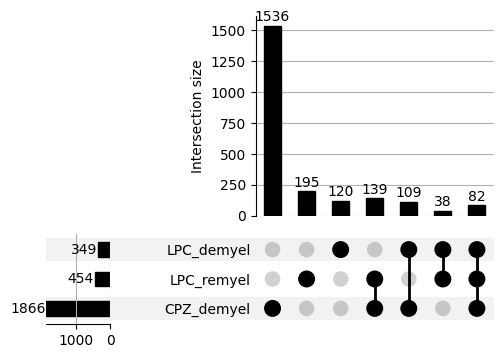

In [34]:
upset_plot = UpSet(down_df_plot, subset_size='count', show_counts=True,).plot()

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

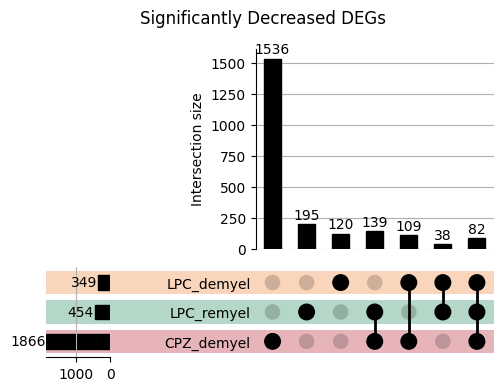

In [35]:
# Create UpSet plot
upset = UpSet(down_df_plot, subset_size='count', show_counts=True, facecolor="black", min_subset_size=10)

# Style the subsets
upset.style_categories(
    'LPC_demyel',
    shading_facecolor="#f9d5bb",
)

# Style the subsets
upset.style_categories(
    'LPC_remyel',
    shading_facecolor="#b4d7c7",
)

# Style the subsets
upset.style_categories(
    'CPZ_demyel',
    shading_facecolor="#e7b5b9",
)

# Plot the UpSet plot
upset.plot()
plt.suptitle("Significantly Decreased DEGs")

# Save the plot as PDF
plt.savefig('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/UPDATED_COMBINED_ANALYSIS/figures/upset_plot_down_NEW_LABELS.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [36]:
# Create gene lists from the new DataFrames
genes_LPC_de_down = LPC_de_down['gene'].tolist()
genes_LPC_re_down = LPC_re_down['gene'].tolist()
genes_Cupr_de_down = Cupr_de_down['gene'].tolist()

In [37]:
# Convert lists to sets for upregulated genes
set_LPC_de_down = set(genes_LPC_de_down)
set_LPC_re_down = set(genes_LPC_re_down)
set_Cupr_de_down = set(genes_Cupr_de_down)

In [38]:
# Overlap all
overlap_all = set_LPC_de_down & set_LPC_re_down & set_Cupr_de_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 82
Overlapping upregulated genes: {'9330117O12Rik', 'Gm48508', 'Ptpre', 'Alcam', '1500015L24Rik', '4732471J01Rik', 'Mycbp2', 'Plagl1', 'Wasf3', 'Lama2', 'Bche', 'Daam2', '9330111N05Rik', 'Kctd4', 'Arhgap24', 'Grm3', 'Dhtkd1', 'Gm49519', 'Slc12a8', 'Shtn1', 'Dock5', 'Rapgef5', 'Jph1', 'Slc8a1', 'Tet1', '9330199G10Rik', 'Slc5a11', 'Cdh20', 'Agmo', 'Ldlr', 'Folh1', 'Nphp3', 'Rasl12', 'Gpm6b', 'A330072L02Rik', 'Cc2d2a', 'Gm12689', 'Lsamp', 'Depdc7', 'Kif6', 'Gnai1', 'Dlg2', 'Mir99ahg', 'Gabrr2', 'Gm816', 'A230001M10Rik', 'Ctnna3', 'Kcnu1', 'Amer2', '9330159F19Rik', 'Stard9', 'Gpld1', 'Fbn2', 'Csmd3', 'AC163347.1', 'Opcml', 'Apbb1ip', 'Atg4c', 'Prtg', 'Deptor', 'Asah2', 'Ino80dos', '4930420G21Rik', 'Gm29455', 'Gm16168', 'Prim2', 'Il1rapl1', 'Slc1a3', 'Tmem97', 'Cdh10', 'Apbb2', 'Zcchc24', 'Dclk1', 'Gm48371', 'Nlgn1', 'Naaa', 'Ankub1', 'Adamts20', 'Slc24a3', 'Prrg1', 'Zc3h6', 'Anln'}


In [39]:
# Overlap of upregulated genes
overlap_LPC = set_LPC_de_down & set_LPC_re_down - set_Cupr_de_down
print("Number of overlapping upregulated genes:", len(overlap_LPC))
print("Overlapping upregulated genes:", overlap_LPC)

Number of overlapping upregulated genes: 38
Overlapping upregulated genes: {'Lats2', 'Setbp1', 'Lgr4', 'Dennd2a', 'Zfp462', 'Rbpjl', 'Sorcs3', 'Atf7', 'Nucb2', 'Adgrg2', 'Fyb', 'Sowaha', 'Ccser1', 'Lrp11', 'Greb1l', 'Syne1', 'Tacc1', 'Castor2', 'Trim7', '1700012D14Rik', 'Adgrg6', 'Pbx3', 'Insr', 'Fam126b', 'Lingo2', 'Art3', 'Gm43242', 'Slc35f1', 'Gm49375', 'Gphn', 'Pdgfc', 'Arl4d', 'Adgrb3', 'Arhgap21', 'Nfib', 'B4galt6', 'Gm13052', 'Plek'}


In [40]:
# Overlap of upregulated genes
unique_CPZ = set_Cupr_de_down - set_LPC_re_down - set_LPC_de_down
print("Number of overlapping upregulated genes:", len(unique_CPZ))
print("Overlapping upregulated genes:", unique_CPZ)

Number of overlapping upregulated genes: 1536
Overlapping upregulated genes: {'Edil3', 'Dync1i1', 'Zfpm1', '2210408I21Rik', 'Itih3', 'Tecpr2', 'Fkbp2', 'Carmil3', 'Stx17', 'Nsmf', 'Kdm8', 'Neil1', 'Ifnar1', 'Myo9a', 'Selenbp1', 'Nprl3', 'Gm16189', 'Pde7a', 'Pfn4', 'Paqr6', 'Coro2b', 'Mrpl14', 'Cpeb3', 'Reep4', 'Opalin', 'Nudt14', 'Fcho2', 'Slpi', 'Dpy19l4', 'Agl', 'Tmem50a', 'Fez1', 'T2', '1190005I06Rik', 'Pik3ip1', 'Rassf3', 'Ube2e2', '2210409D07Rik', 'Kansl1l', 'Abhd12', 'Slc48a1', 'Srsf9', 'Gls2', 'Tmcc3', 'Ebp', 'Ccdc13', 'Fgf1', 'Tex2', 'Gamt', 'Sec62', 'Ccdc28b', 'Gna12', 'Nlk', 'Amotl2', 'Abl1', 'Dgkq', 'Glmp', 'Smap2', 'Rabgap1', 'Gm48678', 'Gm10791', 'Adora1', 'Zmat1', 'Btbd8', 'Gcnt7', 'Myo9b', 'Gm44386', 'Lrrc45', 'Retreg3', 'Dscaml1', 'Cenpp', '4833408A19Rik', 'A830052D11Rik', 'Pola2', 'Adap1', 'Pan3', 'Gm26747', 'Tmem258', 'Zfp286', 'Rtl8a', '0610040J01Rik', 'Pantr1', 'Mef2b', 'Wdr17', 'Hdac7', '2310022B05Rik', 'Lrrc4b', 'Idh2', '1500004A13Rik', 'Tmem88b', 'Rtn3', 'Naaladl

In [41]:
# Make labeled DataFrames from your three sets
df_overlap = pd.DataFrame({
    "gene": list(unique_CPZ),
    "Category": "CPZ_unique"
})

# Merge logFC and Padj values from both datasets
df_overlap = (
    df_overlap
    .merge(Cupr_demyel[['gene', 'logFC', 'Padj']], on='gene', how='left')
    .rename(columns={'logFC': 'logFC_CPZ_de', 'Padj': 'Padj_CPZ_remyel'})
    .merge(LPC_demyel[['gene', 'logFC', 'Padj']], on='gene', how='left')
    .rename(columns={'logFC': 'logFC_LPC_demyel', 'Padj': 'Padj_LPC_demyel'})
    .merge(LPC_remyel[['gene', 'logFC', 'Padj']], on='gene', how='left')
    .rename(columns={'logFC': 'logFC_LPC_remyel', 'Padj': 'Padj_LPC_remyel'})
)

# Optional: Save to file
df_overlap.to_csv("CPZ_summary.csv", index=False)

print(" Combined table created with shape:", df_overlap.shape)
print(df_overlap.head())

 Combined table created with shape: (1536, 8)
            gene    Category  logFC_CPZ_de  Padj_CPZ_remyel  logFC_LPC_demyel  \
0          Edil3  CPZ_unique     -0.954152         0.000380         -0.527112   
1        Dync1i1  CPZ_unique     -2.401610         0.001150         -0.357013   
2          Zfpm1  CPZ_unique     -1.320372         0.002218          0.236699   
3  2210408I21Rik  CPZ_unique     -0.636544         0.017456         -0.091541   
4          Itih3  CPZ_unique     -2.646285         0.014367          0.719270   

   Padj_LPC_demyel  logFC_LPC_remyel  Padj_LPC_remyel  
0         0.052942         -0.414399         0.084846  
1         0.260203         -0.525028         0.062035  
2         0.248223          0.161518         0.428684  
3         0.827278         -0.452910         0.084549  
4         0.018435         -0.140478         0.548229  


In [42]:
# Sort the DataFrame by 'logFC_CPZ_de' descending (highest first)
df_overlap_sorted = df_overlap.sort_values(by='logFC_CPZ_de', ascending=False)

# Get the top 50 genes as a comma-separated string in quotes
top_genes = df_overlap_sorted['gene'].head(55).dropna().tolist()
print('"' + '", "'.join(top_genes) + '"')

"Slc12a2", "Wdfy3", "Gramd3", "Zfp94", "Bfsp2", "Zfp955b", "Gjb1", "Atat1", "Vldlr", "Tfeb", "Ndufa7", "Adamts4", "Trim23", "St6gal1", "Morc4", "Ap5z1", "Tmem175", "Sirt2", "Tfdp2", "Zfp182", "Gm42372", "Pkp4", "B230217C12Rik", "Syt11", "Prox1", "Arhgap39", "Slco3a1", "Adam19", "Scaper", "Etnk1", "Efnb3", "Nfia", "Ptgr2", "Dusp16", "Sorl1", "Tm7sf3", "Mgrn1", "Gfpt1", "Nudt16l1", "Slc26a11", "Dop1a", "Sp3os", "Rusc2", "Zer1", "Calcoco1", "Aebp1", "Zfyve16", "Tcta", "R3hcc1", "Enah", "Rap1gds1", "Cpeb2", "R3hdm1", "Ehhadh", "Tbl1xr1"


# NEW VENN DIAGRAMS

In [43]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles

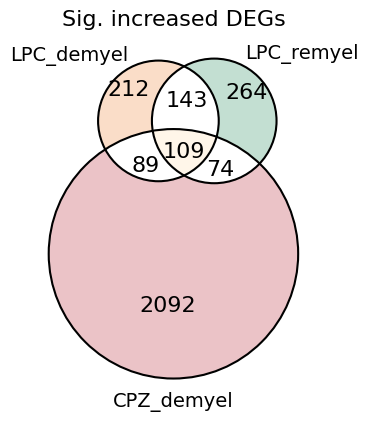

In [44]:
# Convert lists to sets
set_LPC_de_MOL_up = set(genes_LPC_de_up)
set_LPC_re_MOL_up = set(genes_LPC_re_up)
set_Cupr_de_up = set(genes_Cupr_de_up)

# Calculate the lengths of unique and shared elements
length_LPC_de = len(set_LPC_de_MOL_up - set_LPC_re_MOL_up - set_Cupr_de_up)
length_LPC_re = len(set_LPC_re_MOL_up - set_LPC_de_MOL_up - set_Cupr_de_up)
length_Cupr_de = len(set_Cupr_de_up - set_LPC_de_MOL_up - set_LPC_re_MOL_up)

length_LPC_de_LPC_re = len(set_LPC_de_MOL_up & set_LPC_re_MOL_up - set_Cupr_de_up)
length_LPC_de_Cupr_de = len(set_LPC_de_MOL_up & set_Cupr_de_up - set_LPC_re_MOL_up)
length_LPC_re_Cupr_de = len(set_LPC_re_MOL_up & set_Cupr_de_up - set_LPC_de_MOL_up)

length_common = len(set_LPC_de_MOL_up & set_LPC_re_MOL_up & set_Cupr_de_up)

# Set labels and colors
set_labels = ('LPC_demyel', 'LPC_remyel', 'CPZ_demyel')
set_colors = ('#f9d5bb', '#b4d7c7', '#e7b5b9')
    
# Draw the Venn diagram
subsets = (
    length_LPC_de,
    length_LPC_re,
    length_LPC_de_LPC_re,
    length_Cupr_de,
    length_LPC_de_Cupr_de,
    length_LPC_re_Cupr_de,
    length_common
)

venn = venn3(
    subsets=subsets,
    set_labels=set_labels,
    set_colors=set_colors,
    alpha=0.8
)

# Draw circles using the same subset values
circles = venn3_circles(subsets=subsets, linestyle='solid')

# Customize the circle appearance
for c in circles:
    if c:
        c.set_linewidth(1.5)
        c.set_edgecolor('black')
        

# Increase font size for the subset counts inside the circles
for subset in venn.subset_labels:
    if subset:  # Check if the subset label exists (not None)
        subset.set_fontsize(16)

# Increase text size for the set labels
for text in venn.set_labels:
    text.set_fontsize(14)

# Display the plot
plt.title('Sig. increased DEGs', fontsize=16)
plt.savefig('./figures/venn3_Up_MOLs.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

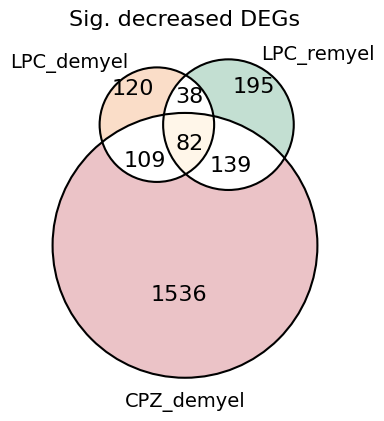

In [45]:
# Convert lists to sets
set_LPC_de_MOL_down = set(genes_LPC_de_down)
set_LPC_re_MOL_down = set(genes_LPC_re_down)
set_Cupr_de_down = set(genes_Cupr_de_down)

# Calculate the lengths of unique and shared elements
length_LPC_de = len(set_LPC_de_MOL_down - set_LPC_re_MOL_down - set_Cupr_de_down)
length_LPC_re = len(set_LPC_re_MOL_down - set_LPC_de_MOL_down - set_Cupr_de_down)
length_Cupr_de = len(set_Cupr_de_down - set_LPC_de_MOL_down - set_LPC_re_MOL_down)

length_LPC_de_LPC_re = len(set_LPC_de_MOL_down & set_LPC_re_MOL_down - set_Cupr_de_down)
length_LPC_de_Cupr_de = len(set_LPC_de_MOL_down & set_Cupr_de_down - set_LPC_re_MOL_down)
length_LPC_re_Cupr_de = len(set_LPC_re_MOL_down & set_Cupr_de_down - set_LPC_de_MOL_down)

length_common = len(set_LPC_de_MOL_down & set_LPC_re_MOL_down & set_Cupr_de_down)

# Set labels and colors
set_labels = ('LPC_demyel', 'LPC_remyel', 'CPZ_demyel')
set_colors = ('#f9d5bb', '#b4d7c7', '#e7b5b9')

# Draw the Venn diagram
subsets = (
    length_LPC_de,
    length_LPC_re,
    length_LPC_de_LPC_re,
    length_Cupr_de,
    length_LPC_de_Cupr_de,
    length_LPC_re_Cupr_de,
    length_common
)

venn = venn3(
    subsets=subsets,
    set_labels=set_labels,
    set_colors=set_colors,
    alpha=0.8
)

# Draw circles using the same subset values
circles = venn3_circles(subsets=subsets, linestyle='solid')

# Customize the circle appearance
for c in circles:
    if c:
        c.set_linewidth(1.5)
        c.set_edgecolor('black')
        

# Increase font size for the subset counts inside the circles
for subset in venn.subset_labels:
    if subset:  # Check if the subset label exists (not None)
        subset.set_fontsize(16)

# Increase text size for the set labels
for text in venn.set_labels:
    text.set_fontsize(14)

# Display the plot
plt.title('Sig. decreased DEGs', fontsize=16)
plt.savefig('./figures/venn3_Down_MOLs.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [46]:
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt

def plot_venn3_from_sets(set1, set2, set3, labels, colors, title, save_path=None):
    """
    Plots a 3-set Venn diagram with automatic circle and label styling.

    Parameters:
    - set1, set2, set3: sets of gene names
    - labels: tuple of 3 labels (str)
    - colors: tuple of 3 hex color strings
    - title: plot title (str)
    - save_path: optional path to save the figure (e.g., 'figs/my_venn.png')
    """
    # Compute subset sizes
    only1 = len(set1 - set2 - set3)
    only2 = len(set2 - set1 - set3)
    only3 = len(set3 - set1 - set2)

    shared12 = len(set1 & set2 - set3)
    shared13 = len(set1 & set3 - set2)
    shared23 = len(set2 & set3 - set1)

    shared123 = len(set1 & set2 & set3)

    subsets = (only1, only2, shared12, only3, shared13, shared23, shared123)

    # Plot Venn
    plt.figure(figsize=(6, 6))
    venn = venn3(
        subsets=subsets,
        set_labels=labels,
        set_colors=colors,
        alpha=0.8
    )

    # Circles
    circles = venn3_circles(subsets=subsets, linestyle='solid')
    for c in circles:
        if c:
            c.set_linewidth(1.5)
            c.set_edgecolor('black')

    # Subset labels (numbers inside)
    for subset in venn.subset_labels:
        if subset:
            subset.set_fontsize(22)
            subset.set_fontweight('bold')  # Make bold

    # Set labels (group names)
    for text in venn.set_labels:
        if text:
            text.set_fontsize(18)
            text.set_fontweight('bold')  # Optional — bold the group labels too

    # Title
    plt.title(title, fontsize=24, fontweight='bold')

    # Save if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='none')
        print(f"Saved Venn diagram to: {save_path}")

    plt.show()

Saved Venn diagram to: figures/up_overlap.png


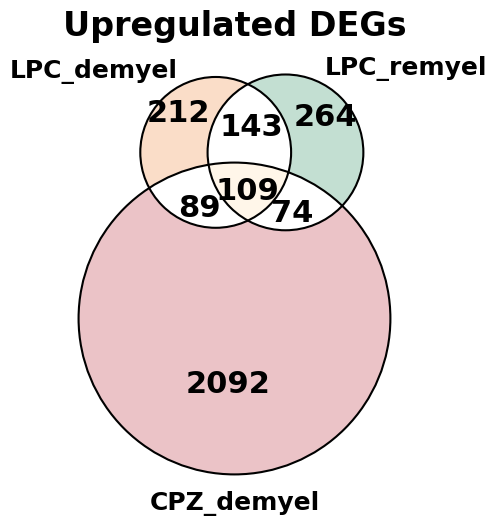

In [47]:

# Convert lists to sets
set_genes_LPC_de_up = set(genes_LPC_de_up)
set_genes_LPC_re_up = set(genes_LPC_re_up)
set_genes_Cupr_de_up = set(genes_Cupr_de_up)


plot_venn3_from_sets(
    set1=set_genes_LPC_de_up,
    set2=set_genes_LPC_re_up,
    set3=set_genes_Cupr_de_up,
    labels=('LPC_demyel', 'LPC_remyel', 'CPZ_demyel'),
    colors=('#f9d5bb', '#b4d7c7', '#e7b5b9'),
    title='Upregulated DEGs',
    save_path='figures/up_overlap.png'  # optional
)

Saved Venn diagram to: figures/down_overlap_MG.png


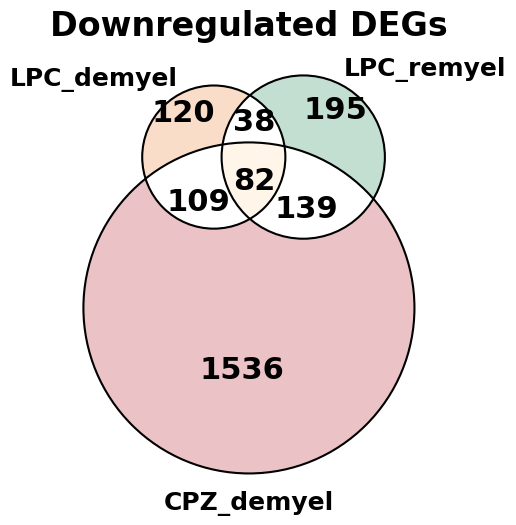

In [48]:
# Convert lists to sets
set_genes_LPC_de_down = set(genes_LPC_de_down)
set_genes_LPC_re_down = set(genes_LPC_re_down)
set_genes_Cupr_de_down = set(genes_Cupr_de_down)

plot_venn3_from_sets(
    set1=set_genes_LPC_de_down,
    set2=set_genes_LPC_re_down,
    set3=set_genes_Cupr_de_down,
    labels=('LPC_demyel', 'LPC_remyel', 'CPZ_demyel'),
    colors=('#f9d5bb', '#b4d7c7', '#e7b5b9'),
    title='Downregulated DEGs',
    save_path='figures/down_overlap_MG.png'  # optional
)

# Overlap with MHC genes?

In [28]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles

In [19]:
# Convert gene columns to sets for each dataset
lpc_de_up_genes = set(LPC_de_up['gene'])
lpc_de_down_genes = set(LPC_de_down['gene'])

lpc_re_up_genes = set(LPC_re_up['gene'])
lpc_re_down_genes = set(LPC_re_down['gene'])

cupr_de_up_genes = set(Cupr_de_up['gene'])
cupr_de_down_genes = set(Cupr_de_down['gene'])

In [20]:
MHC_I = pd.read_excel('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/MHC_class_I.xlsx', index_col=None)
MHC_I.shape

(192, 3)

In [21]:
MHC_I.head

<bound method NDFrame.head of     Gene_symbol                                   Gene_description  \
0        Fcer1g  Fc receptor, IgE, high affinity I, gamma polyp...   
1         Fcgr1  Fc receptor, IgG, high affinity I [Source:MGI ...   
2         Fcgr3  Fc receptor, IgG, low affinity III [Source:MGI...   
3         H2-K1  histocompatibility 2, K1, K region [Source:MGI...   
4         Mpeg1  macrophage expressed gene 1 [Source:MGI Symbol...   
..          ...                                                ...   
187      Lilra6           leukocyte immunoglobulin-like recepto...   
188        Pirb           paired Ig-like receptor B [Source:MGI...   
189      Lilra5           leukocyte immunoglobulin-like recepto...   
190       Cd160           CD160 antigen [Source:MGI Symbol;Acc:...   
191       Mfsd6           major facilitator superfamily domain ...   

                                               GO_term  
0    GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...  
1    GOBP_ANTIG

In [22]:
MHC_I_genes = MHC_I["Gene_symbol"].tolist()
print(MHC_I_genes)

['Fcer1g', 'Fcgr1', 'Fcgr3', 'H2-K1', 'Mpeg1', 'Tapbp', 'Ifi30', 'Mfsd6', 'H2-T27', 'H2-Q6', 'H2-Q7', 'H2-M10.3', 'B2m', 'Calr', 'Fcer1g', 'Fcgr1', 'Fcgr3', 'Pdia3', 'H2-Bl', 'H2-D1', 'H2-K1', nan, 'H2-M10.1', 'H2-M2', 'H2-M3', 'H2-M9', 'H2-Q1', 'H2-Q10', 'H2-Q2', 'H2-Q4', 'H2-Q7', 'H2-T10', 'H2-T22', 'H2-T23', 'H2-T24', 'H2-T3', 'Mr1', 'Hfe', 'Ide', 'Mpeg1', 'Raet1d', 'Raet1d', 'Raet1d', 'Tapbpl', 'Tap1', 'Tap2', 'Tapbp', 'Bag6', 'H2-M10.4', 'H2-M11', 'H2-M1', 'H2-M10.5', 'H2-M5', 'Mill2', 'Mill1', 'H2-M10.2', 'Raet1e', 'H2-M10.6', 'Raet1d', 'Ifi30', 'H60b', 'H2-T26', 'H60c', nan, '2410137M14Rik', 'Ulbp1', 'Mfsd6', 'Ciita', 'Hsph1', 'Taf7', 'Nlrp12', 'Nlrc5', 'Il33', 'B2m', 'Calr', 'Pdia3', 'Tapbpl', 'Tapbp', 'Ciita', 'Hsph1', 'Nlrp12', 'Nlrc5', 'Il33', 'H2-Q6', 'B2m', 'Calr', 'Pdia3', 'H2-D1', 'H2-K1', 'H2-Q1', 'H2-Q10', 'H2-Q2', 'H2-Q4', 'H2-Q7', 'Tapbpl', 'Tap1', 'Tap2', 'Tapbp', 'H2-Q6', 'H2-M10.3', 'B2m', 'H2-D1', 'H2-K1', nan, 'H2-M10.1', 'H2-M2', 'H2-M9', 'H2-Q1', 'H2-Q10', 'H2

In [23]:
duplicate_genes = MHC_I["Gene_symbol"].duplicated()
num_duplicates = duplicate_genes.sum()
print(f"Number of duplicated gene names: {num_duplicates}")

Number of duplicated gene names: 105


In [24]:
MHC_I_unique = MHC_I.drop_duplicates(subset="Gene_symbol", keep="first")
MHC_I_unique_genes = MHC_I_unique["Gene_symbol"].tolist()
print(MHC_I_unique_genes)

['Fcer1g', 'Fcgr1', 'Fcgr3', 'H2-K1', 'Mpeg1', 'Tapbp', 'Ifi30', 'Mfsd6', 'H2-T27', 'H2-Q6', 'H2-Q7', 'H2-M10.3', 'B2m', 'Calr', 'Pdia3', 'H2-Bl', 'H2-D1', nan, 'H2-M10.1', 'H2-M2', 'H2-M3', 'H2-M9', 'H2-Q1', 'H2-Q10', 'H2-Q2', 'H2-Q4', 'H2-T10', 'H2-T22', 'H2-T23', 'H2-T24', 'H2-T3', 'Mr1', 'Hfe', 'Ide', 'Raet1d', 'Tapbpl', 'Tap1', 'Tap2', 'Bag6', 'H2-M10.4', 'H2-M11', 'H2-M1', 'H2-M10.5', 'H2-M5', 'Mill2', 'Mill1', 'H2-M10.2', 'Raet1e', 'H2-M10.6', 'H60b', 'H2-T26', 'H60c', '2410137M14Rik', 'Ulbp1', 'Ciita', 'Hsph1', 'Taf7', 'Nlrp12', 'Nlrc5', 'Il33', 'Pira12', 'Pira13', 'Lilrb4b', 'Lilrb4a', 'Pira2', 'Lilra6', 'Pirb', 'Lilra5', 'Atp5f1a', 'Atp5f1b', 'Cd8b1', 'Klra17', 'Pilrb1', 'Cd244a', 'Tubb5', 'Pilra', 'Vcp', 'Klrk1', 'Bcap31', 'Pilrb2', 'Derl1', 'Cd8a', 'Klrc1', 'Klrc2', 'Klrd1', 'Cd160', 'Ctsh']


In [76]:
len(MHC_I_unique_genes)

87

In [25]:
mhc_i_genes_set = set(MHC_I_unique["Gene_symbol"])

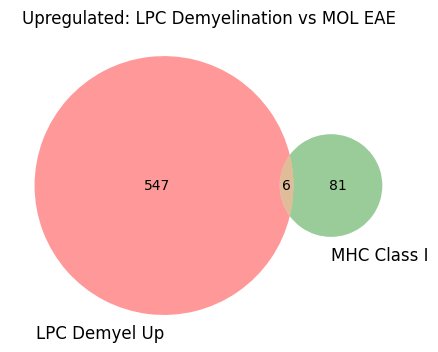

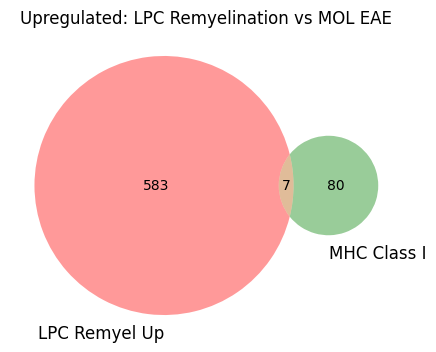

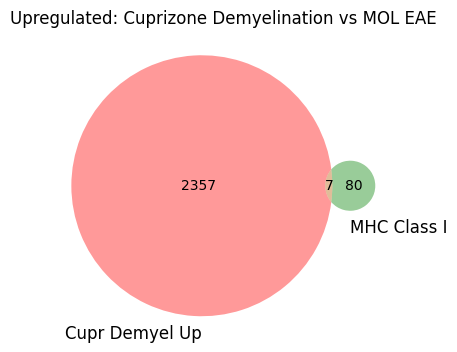

In [29]:
# -------- Venn Diagrams: UPREGULATED --------
# LPC Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([lpc_de_up_genes, mhc_i_genes_set], set_labels=('LPC Demyel Up', 'MHC Class I'))
plt.title("Upregulated: LPC Demyelination vs MOL EAE")
plt.show()

# LPC Remyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([lpc_re_up_genes, mhc_i_genes_set], set_labels=('LPC Remyel Up', 'MHC Class I'))
plt.title("Upregulated: LPC Remyelination vs MOL EAE")
plt.show()

# Cuprizone Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([cupr_de_up_genes, mhc_i_genes_set], set_labels=('Cupr Demyel Up', 'MHC Class I'))
plt.title("Upregulated: Cuprizone Demyelination vs MOL EAE")
plt.show()

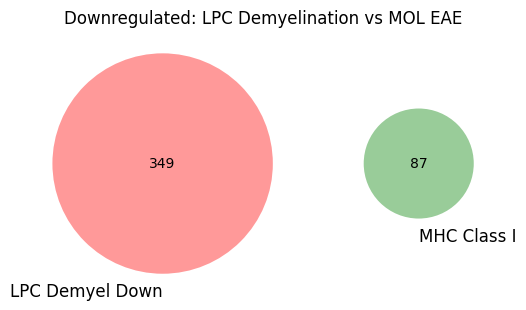

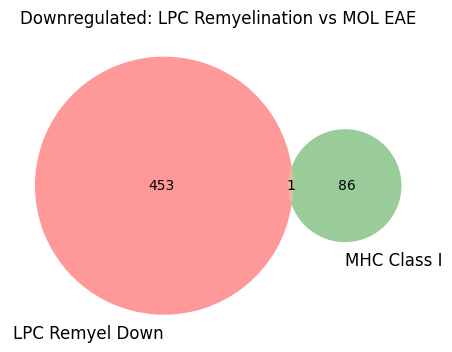

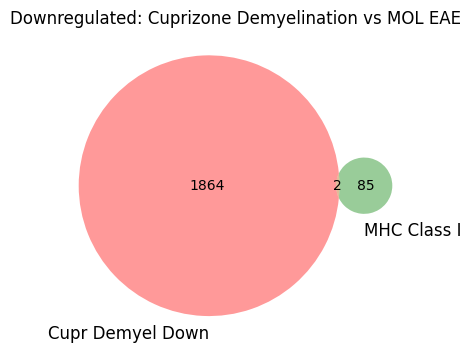

In [30]:
# -------- Venn Diagrams: UPREGULATED --------
# LPC Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([lpc_de_down_genes, mhc_i_genes_set], set_labels=('LPC Demyel Down', 'MHC Class I'))
plt.title("Downregulated: LPC Demyelination vs MOL EAE")
plt.show()

# LPC Remyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([lpc_re_down_genes, mhc_i_genes_set], set_labels=('LPC Remyel Down', 'MHC Class I'))
plt.title("Downregulated: LPC Remyelination vs MOL EAE")
plt.show()

# Cuprizone Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([cupr_de_down_genes, mhc_i_genes_set], set_labels=('Cupr Demyel Down', 'MHC Class I'))
plt.title("Downregulated: Cuprizone Demyelination vs MOL EAE")
plt.show()

In [31]:
mhc_i_lpc_de = mhc_i_genes_set & lpc_de_up_genes
print("Genes shared by all three (upregulated):", len(mhc_i_lpc_de))
print(mhc_i_lpc_de)

Genes shared by all three (upregulated): 6
{'Il33', 'Nlrc5', 'H2-T22', 'H2-D1', 'B2m', 'H2-K1'}


In [32]:
mhc_i_lpc_re = mhc_i_genes_set & lpc_re_up_genes
print("Genes shared by all three (upregulated):", len(mhc_i_lpc_re))
print(mhc_i_lpc_re)

Genes shared by all three (upregulated): 7
{'Il33', 'Nlrc5', 'H2-T22', 'H2-D1', 'B2m', 'H2-Q4', 'H2-K1'}


In [33]:
mhc_i_lpc = mhc_i_genes_set & lpc_de_up_genes & lpc_re_up_genes
print("Genes shared by all three (upregulated):", len(mhc_i_lpc))
print(mhc_i_lpc)

Genes shared by all three (upregulated): 6
{'Il33', 'Nlrc5', 'H2-T22', 'H2-D1', 'B2m', 'H2-K1'}


In [34]:
mhc_i_cpz_de = mhc_i_genes_set & cupr_de_up_genes
print("Genes shared by all three (upregulated):", len(mhc_i_cpz_de))
print(mhc_i_cpz_de)

Genes shared by all three (upregulated): 7
{'Hsph1', 'H2-D1', 'Derl1', 'B2m', 'Bag6', 'Tap2', 'Taf7'}


In [35]:
mhc_i_lpc_re_down = mhc_i_genes_set & lpc_re_down_genes
print("Genes shared by all three (upregulated):", len(mhc_i_lpc_re_down))
print(mhc_i_lpc_re_down)

Genes shared by all three (upregulated): 1
{'Ctsh'}


In [36]:
mhc_i_cpz_de_down = mhc_i_genes_set & cupr_de_down_genes
print("Genes shared by all three (upregulated):", len(mhc_i_cpz_de_down))
print(mhc_i_cpz_de_down)

Genes shared by all three (upregulated): 2
{'Mfsd6', 'Il33'}


In [37]:
MHC_II = pd.read_excel('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/MHC_class_II.xlsx', index_col=None)
MHC_II.shape

(250, 3)

In [38]:
MHC_II_genes = MHC_II["Gene_symbol"].tolist()
print(MHC_II_genes)

['H2-Ea', 'B2m', 'Ctse', 'Ctss', 'Fcer1g', 'Fcgr2b', 'H2-Aa', 'H2-Ab1', 'H2-Eb1', 'H2-DMa', 'H2-DMb1', 'H2-DMb2', 'H2-Oa', 'H2-Ob', 'Cd74', 'Pikfyve', 'Lgmn', 'Traf6', 'H2-Eb2', 'Iglc4', 'Unc93b1', 'Ifi30', 'H2-Ea', 'B2m', 'Ctse', 'Ctss', 'Fcer1g', 'Fcgr2b', 'H2-Aa', 'H2-Ab1', 'H2-Eb1', 'H2-DMa', 'H2-DMb1', 'H2-DMb2', 'H2-Oa', 'H2-Ob', 'Cd74', 'Pikfyve', 'Lgmn', 'Thbs1', 'Traf6', 'H2-Eb2', 'Iglc4', 'Unc93b1', 'Ifi30', 'Pycard', 'Arl8b', 'Marchf8', 'Marchf1', 'Trem2', 'Ciita', 'Cdk5r1', 'Ifng', 'Il10', 'Il4', 'Jak2', 'Slc11a1', 'Spi1', 'Tmem106a', 'Tlr4', 'Cd40lg', 'Xbp1', 'Taf7', 'Marchf8', 'Nfx1', 'Il33', 'Sirt1', 'Il10', 'Spi1', 'Taf7', 'Marchf8', 'Nfx1', 'H2-Ea', 'B2m', 'H2-Aa', 'H2-Ab1', 'H2-Eb1', 'H2-DMa', 'H2-DMb1', 'H2-DMb2', 'H2-Oa', 'H2-Ob', 'H2-Eb2', 'Iglc4', 'Ciita', 'Cdk5r1', 'Ifng', 'Il10', 'Il4', 'Jak2', 'Tmem106a', 'Tlr4', 'Cd40lg', 'Xbp1', 'Il33', 'Sirt1', 'H2-Oa', 'H2-Ob', 'Thbs1', 'Pycard', 'Trem2', 'H2-Ea', 'B2m', 'H2-Aa', 'H2-Ab1', 'H2-Eb1', 'H2-DMa', 'H2-DMb1', 'H2

In [39]:
duplicate_genes = MHC_II["Gene_symbol"].duplicated()
num_duplicates = duplicate_genes.sum()
print(f"Number of duplicated gene names: {num_duplicates}")

Number of duplicated gene names: 102


In [40]:
MHC_II_unique = MHC_II.drop_duplicates(subset="Gene_symbol", keep="first")
MHC_II_unique_genes = MHC_II_unique["Gene_symbol"].tolist()
print(MHC_II_unique_genes)

['H2-Ea', 'B2m', 'Ctse', 'Ctss', 'Fcer1g', 'Fcgr2b', 'H2-Aa', 'H2-Ab1', 'H2-Eb1', 'H2-DMa', 'H2-DMb1', 'H2-DMb2', 'H2-Oa', 'H2-Ob', 'Cd74', 'Pikfyve', 'Lgmn', 'Traf6', 'H2-Eb2', 'Iglc4', 'Unc93b1', 'Ifi30', 'Thbs1', 'Pycard', 'Arl8b', 'Marchf8', 'Marchf1', 'Trem2', 'Ciita', 'Cdk5r1', 'Ifng', 'Il10', 'Il4', 'Jak2', 'Slc11a1', 'Spi1', 'Tmem106a', 'Tlr4', 'Cd40lg', 'Xbp1', 'Taf7', 'Nfx1', 'Il33', 'Sirt1', 'Cd4', 'Cd81', 'Col2a1', 'Lag3', 'Fcrl6', 'Sec24b', 'Tubb6', 'Ap2a2', 'Ap1m1', 'Ap1m2', 'Klc4', 'Kif20a', 'Ap1s1', 'Kif5b', 'Ctsd', 'Ap2s1', 'Dynll1', 'Ap1b1', 'Kif11', 'Capza2', 'Tubb1', 'Ctsa', 'Kif3a', 'Dync1h1', 'Canx', 'Sar1b', 'Dynll2', 'Kif3c', 'Sec23a', 'Actr10', 'Tubal3', 'Klc1', 'Kif26a', 'Ctsl', 'Kif2a', 'Ctsb', 'Ap2m1', 'Tuba1b', 'Racgap1', 'Dctn4', 'Klc2', 'Actr1a', 'Dctn2', 'Tuba4a', 'Kifap3', 'Dnm1', 'Dync1i2', 'Kif18a', 'Kif3b', 'Ctso', 'Ctsk', 'Dctn3', 'Clta', 'Sh3gl2', 'Kif2c', 'Capzb', 'Dync1i1', 'Tuba8', 'Sec13', 'Ctsc', 'Kif22', 'Dctn5', 'Ap1s2', 'Dctn6', 'Ap1g1', 'D

In [41]:
len(MHC_II_unique_genes)

148

In [42]:
mhc_ii_genes_set = set(MHC_II_unique["Gene_symbol"])

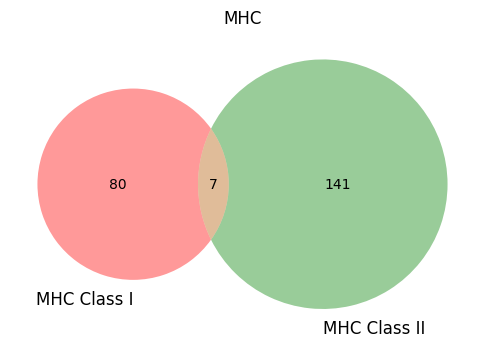

In [43]:
plt.figure(figsize=(6, 4))
venn2([mhc_i_genes_set, mhc_ii_genes_set], set_labels=('MHC Class I', 'MHC Class II'))
plt.title("MHC")
plt.show()

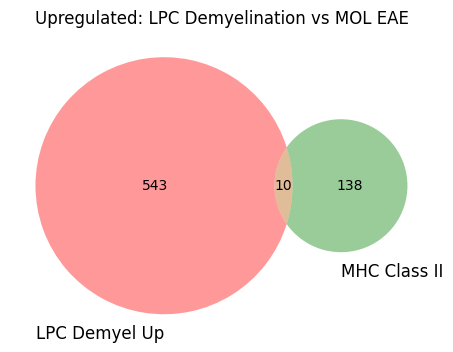

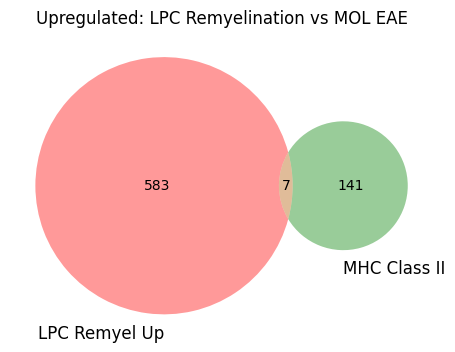

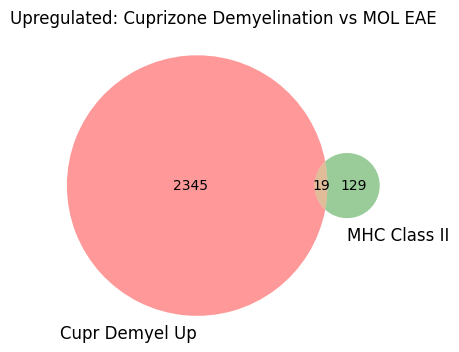

In [44]:
# -------- Venn Diagrams: UPREGULATED --------
# LPC Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([lpc_de_up_genes, mhc_ii_genes_set], set_labels=('LPC Demyel Up', 'MHC Class II'))
plt.title("Upregulated: LPC Demyelination vs MOL EAE")
plt.show()

# LPC Remyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([lpc_re_up_genes, mhc_ii_genes_set], set_labels=('LPC Remyel Up', 'MHC Class II'))
plt.title("Upregulated: LPC Remyelination vs MOL EAE")
plt.show()

# Cuprizone Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([cupr_de_up_genes, mhc_ii_genes_set], set_labels=('Cupr Demyel Up', 'MHC Class II'))
plt.title("Upregulated: Cuprizone Demyelination vs MOL EAE")
plt.show()

In [45]:
mhc_ii_lpc_de = mhc_ii_genes_set & lpc_de_up_genes
print("Genes shared by all three (upregulated):", len(mhc_ii_lpc_de))
print(mhc_ii_lpc_de)

Genes shared by all three (upregulated): 10
{'Tubb4b', 'Il33', 'Ap2a1', 'Dnm1', 'Dynll1', 'Tubb2b', 'B2m', 'Tubb2a', 'Tubb3', 'Tuba1a'}


In [46]:
mhc_ii_lpc_re = mhc_ii_genes_set & lpc_re_up_genes
print("Genes shared by all three (upregulated):", len(mhc_ii_lpc_re))
print(mhc_ii_lpc_re)

Genes shared by all three (upregulated): 7
{'Tuba4a', 'Il33', 'Kif22', 'Ctsa', 'Dynll1', 'B2m', 'Ctsb'}


In [47]:
mhc_ii_lpc = mhc_ii_genes_set & lpc_de_up_genes & lpc_re_up_genes
print("Genes shared by all three (upregulated):", len(mhc_ii_lpc))
print(mhc_ii_lpc)

Genes shared by all three (upregulated): 3
{'Dynll1', 'B2m', 'Il33'}


In [48]:
mhc_ii_cpz_de = mhc_ii_genes_set & cupr_de_up_genes
print("Genes shared by all three (upregulated):", len(mhc_ii_cpz_de))
print(mhc_ii_cpz_de)

Genes shared by all three (upregulated): 19
{'Tubb4b', 'Tubb2b', 'Xbp1', 'Ctsl', 'Kif5b', 'Tubb3', 'Ap1s1', 'Sirt1', 'Tuba1b', 'Klc2', 'Dync1li1', 'Sec31a', 'Sec24d', 'Dnm2', 'Taf7', 'Arf1', 'Ctsd', 'B2m', 'Tubb2a'}


In [49]:
mhc_ii_all = mhc_ii_genes_set & cupr_de_up_genes & lpc_de_up_genes & lpc_re_up_genes
print("Genes shared by all three (upregulated):", len(mhc_ii_all))
print(mhc_ii_all)

Genes shared by all three (upregulated): 1
{'B2m'}


# Overlap with EAE

In [50]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns

In [51]:
# Create gene lists from the dfs:
genes_LPC_de_up = LPC_de_up['gene'].tolist()
genes_LPC_re_up = LPC_re_up['gene'].tolist()
genes_Cupr_de_up = Cupr_de_up['gene'].tolist()

# Convert lists to sets for upregulated genes
set_LPC_de_up = set(genes_LPC_de_up)
set_LPC_re_up = set(genes_LPC_re_up)
set_Cupr_de_up = set(genes_Cupr_de_up)

In [52]:
# Create gene lists from the dfs:
genes_LPC_de_down = LPC_de_down['gene'].tolist()
genes_LPC_re_down = LPC_re_down['gene'].tolist()
genes_Cupr_de_down = Cupr_de_down['gene'].tolist()

# Convert lists to sets for downregulated genes
set_LPC_de_down = set(genes_LPC_de_down)
set_LPC_re_down = set(genes_LPC_re_down)
set_Cupr_de_down = set(genes_Cupr_de_down)

In [53]:
MOL_EAE = pd.read_excel('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/EAE_MOLs.xlsx', index_col=None)
MOL_EAE = MOL_EAE.rename(columns={'Unnamed: 0': 'gene'})

print(MOL_EAE.shape)
MOL_EAE.head

(1688, 2)


<bound method NDFrame.head of          gene  EAE_MOLs
0       H2-D1     30.55
1         B2m     29.35
2         C4b     25.10
3       H2-K1     22.15
4      Phyhd1     13.65
...       ...       ...
1683    Ncam1     -1.95
1684    Bace1     -1.95
1685  Zfp280c     -1.95
1686     Gdi1     -1.95
1687  Gm12060     -1.95

[1688 rows x 2 columns]>

In [54]:
MOL_EAE["gene"] = MOL_EAE["gene"].replace("Serpi03n", "Serpina3n")

# Safely filter, ignoring NaN values
MOL_EAE[MOL_EAE["gene"].str.contains("Serp", case=False, na=False)]

,gene,EAE_MOLs
6,Serpina3n,11.50
206,Serping1,2.85
443,Serpi03f,1.85
738,Serpi03c,1.00


In [55]:
# MOL
# Upregulated genes
MOL_EAE_up = MOL_EAE[MOL_EAE['EAE_MOLs'] > 0]['gene'].tolist()

# Downregulated genes
MOL_EAE_down = MOL_EAE[MOL_EAE['EAE_MOLs'] < 0]['gene'].tolist()

# Check length
print("MOL_EAE_up:", len(MOL_EAE_up))
print("MOL_EAE_down:", len(MOL_EAE_down))

MOL_EAE_up: 808
MOL_EAE_down: 880


/tmp/2306306.1.long/ipykernel_2666386/645218033.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='EAE_MOLs', y='gene', data=subset, palette='coolwarm', orient='h')


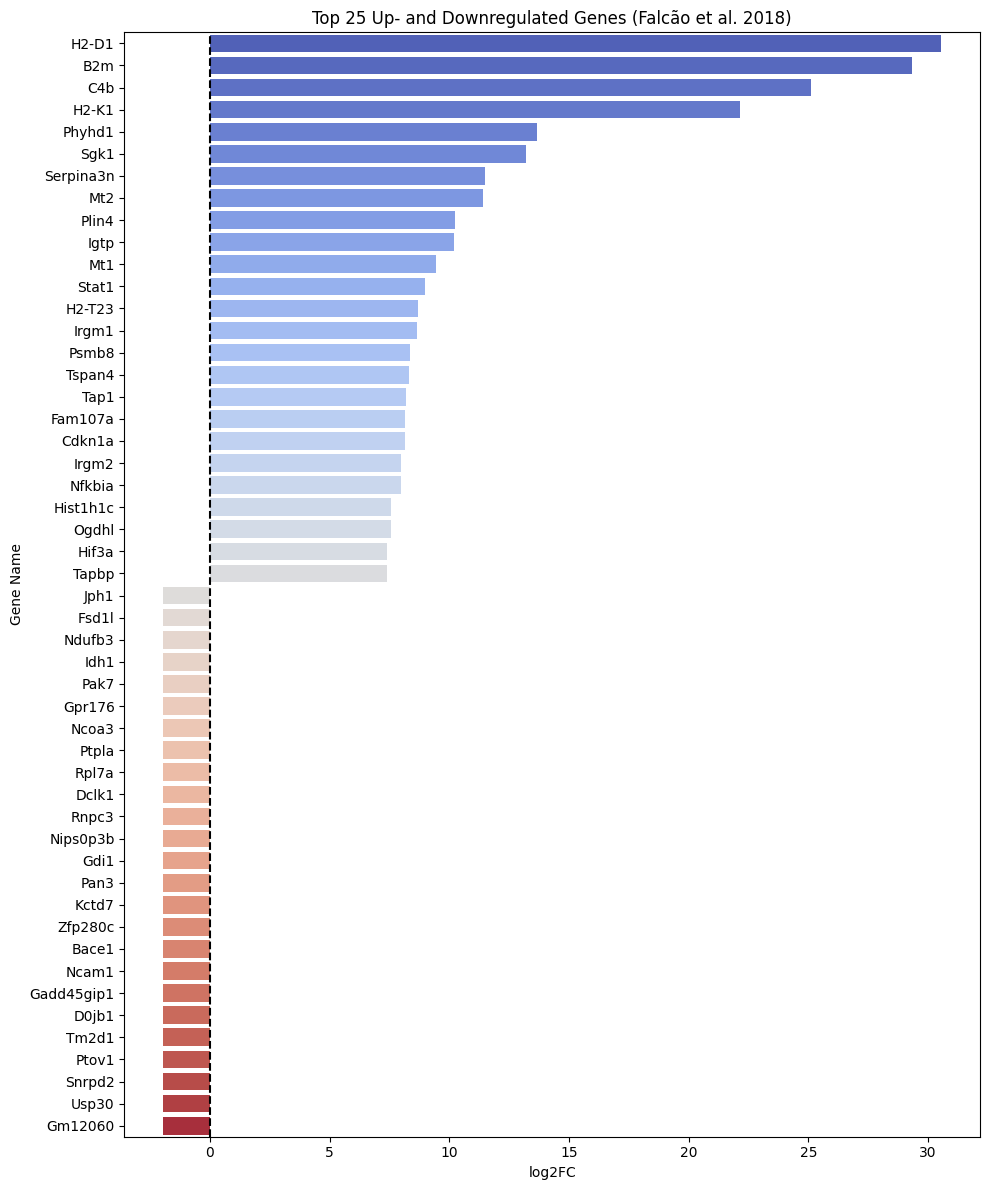

In [27]:
MOL_EAE_sorted = MOL_EAE.sort_values('EAE_MOLs', ascending=True)

# Take top 25 and bottom 25
top_25 = MOL_EAE_sorted.head(25)
bottom_25 = MOL_EAE_sorted.tail(25)

# Combine them
subset = pd.concat([top_25, bottom_25])

# Sort for better plotting (optional: by absolute value or just for aesthetics)
subset = subset.sort_values('EAE_MOLs', ascending=False)

# Plot
plt.figure(figsize=(10, 12))
sns.barplot(x='EAE_MOLs', y='gene', data=subset, palette='coolwarm', orient='h')
plt.axvline(0, color='black', linestyle='--')
plt.title('Top 25 Up- and Downregulated Genes (Falcão et al. 2018)')
plt.xlabel('log2FC')
plt.ylabel('Gene Name')
plt.tight_layout()
plt.show()

In [28]:
%%R
library(readxl)

mol_eae <- read_excel("/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/EAE_MOLs.xlsx")
names(mol_eae) <- c("gene", "logFC")
head(mol_eae)

UsageError: Cell magic `%%R` not found.


In [29]:
%%R

mol_eae <- mol_eae %>%
  mutate(gene = ifelse(gene == "Serpi03n", "Serpina3n", gene))

head(mol_eae)

UsageError: Cell magic `%%R` not found.


In [33]:
%%R

mol_eae[grep("Serp", mol_eae$gene, ignore.case = TRUE), ]

# A tibble: 4 × 2
  gene      logFC
  <chr>     <dbl>
1 Serpina3n 11.5 
2 Serping1   2.85
3 Serpi03f   1.85
4 Serpi03c   1   


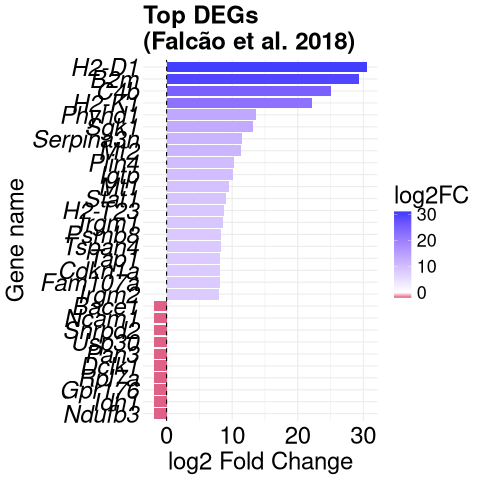

In [36]:
%%R
library(scales)

# Define the 10 downregulated genes of interest
genes_to_select <- c(
  "Ncam1", "Bace1", "Ndufb3", "Idh1", "Gpr176", "Pan3",
  "Dclk1", "Usp30", "Snrpd2", "Rpl7a"
)

# Filter bottom genes by these 10 gene names (if they exist in your data)
bottom_selected <- mol_eae %>% filter(gene %in% genes_to_select)

# Take top 20 upregulated genes
top_25 <- mol_eae %>% arrange(desc(logFC)) %>% head(20)

# Combine
subset <- bind_rows(bottom_selected, top_25)

# Order gene factor for plotting (by increasing logFC)
subset$gene <- factor(subset$gene, levels = subset %>% arrange(logFC) %>% pull(gene))

# Manually cap values for color mapping
subset$fill_color <- pmax(pmin(subset$logFC, 2), -2)  # cap between -2 and +2

# Plot
p <- ggplot(subset, aes(x = logFC, y = gene, fill = logFC)) +
  geom_bar(stat = "identity") +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_fill_gradientn(
    colors = c("#de5d83", "white", "#3b3bff"),
    values = rescale(c(-2, 0, 31)),  # Uneven spacing
    limits = c(-2, 31),
    name = "log2FC"
  ) +
  labs(
    title = "Top DEGs\n(Falcão et al. 2018)",
    x = "log2 Fold Change",
    y = "Gene name"
  ) +
    theme_minimal() +
    theme(
      plot.title = element_text(size = 24, face = "bold"),
      axis.title.x = element_text(size = 24),
      axis.title.y = element_text(size = 24),
      axis.text.x = element_text(size = 24, colour = "black"),
      axis.text.y = element_text(size = 24, face = "italic", colour = "black"),  # ← italicize gene names
      legend.title = element_text(size = 24),
      legend.text = element_text(size = 18, colour = "black")
    )
# Save to PDF and PNG
ggsave("./figures/EAE_MOL_DEG_plot.png", plot = p, width = 8, height = 10, dpi = 300)

# Show the plot
print(p)

In [56]:
# Convert MOL EAE lists to sets
mol_eae_up_genes = set(MOL_EAE_up)
mol_eae_down_genes = set(MOL_EAE_down)

# Convert gene columns to sets for each dataset
lpc_de_up_genes = set(LPC_de_up['gene'])
lpc_de_down_genes = set(LPC_de_down['gene'])

lpc_re_up_genes = set(LPC_re_up['gene'])
lpc_re_down_genes = set(LPC_re_down['gene'])

cupr_de_up_genes = set(Cupr_de_up['gene'])
cupr_de_down_genes = set(Cupr_de_down['gene'])

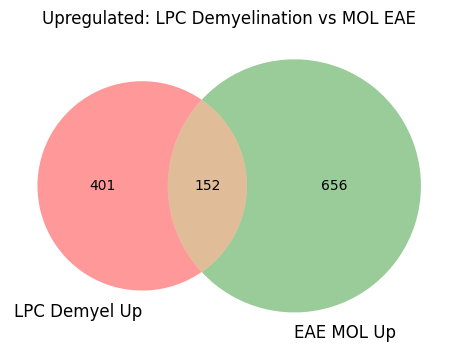

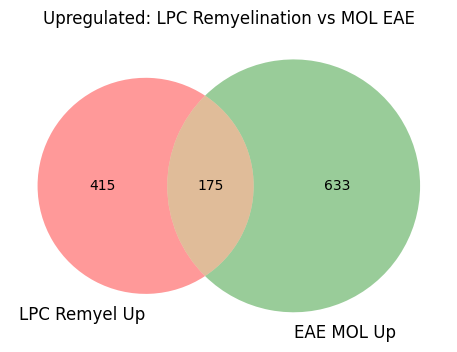

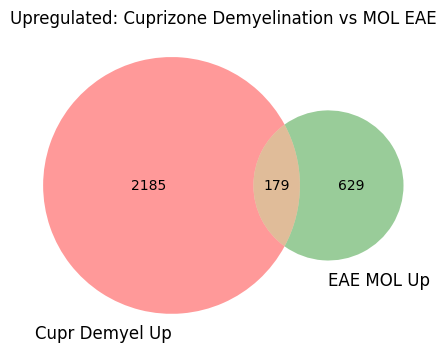

In [30]:
# -------- Venn Diagrams: UPREGULATED --------
# LPC Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([lpc_de_up_genes, mol_eae_up_genes], set_labels=('LPC Demyel Up', 'EAE MOL Up'))
plt.title("Upregulated: LPC Demyelination vs MOL EAE")
plt.show()

# LPC Remyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([lpc_re_up_genes, mol_eae_up_genes], set_labels=('LPC Remyel Up', 'EAE MOL Up'))
plt.title("Upregulated: LPC Remyelination vs MOL EAE")
plt.show()

# Cuprizone Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([cupr_de_up_genes, mol_eae_up_genes], set_labels=('Cupr Demyel Up', 'EAE MOL Up'))
plt.title("Upregulated: Cuprizone Demyelination vs MOL EAE")
plt.show()

In [28]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles

def plot_venn2_from_sets(set1, set2, labels, colors, title, save_path=None):
    """
    Plots a 2-set Venn diagram with consistent styling matching venn3 visualization.
    """

    # Compute subset sizes
    only1 = len(set1 - set2)
    only2 = len(set2 - set1)
    both = len(set1 & set2)
    subsets = (only1, only2, both)

    # Plot Venn
    plt.figure(figsize=(6, 6))
    venn = venn2(
        subsets=subsets,
        set_labels=labels,
        set_colors=colors,
        alpha=0.8
    )

    # Circle outlines
    circles = venn2_circles(subsets=subsets, linestyle='solid')
    for c in circles:
        if c:
            c.set_linewidth(1.5)
            c.set_edgecolor('black')

    # Subset labels (numbers inside circles)
    for subset in venn.subset_labels:
        if subset:
            subset.set_fontsize(22)
            subset.set_fontweight('bold')

    # Set labels (group names)
    for text in venn.set_labels:
        if text:
            text.set_fontsize(18)
            text.set_fontweight('bold')

    # Title
    plt.title(title, fontsize=24, fontweight='bold')

    # Save figure (optional)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='none')
        print(f"Saved Venn diagram to: {save_path}")

    plt.show()

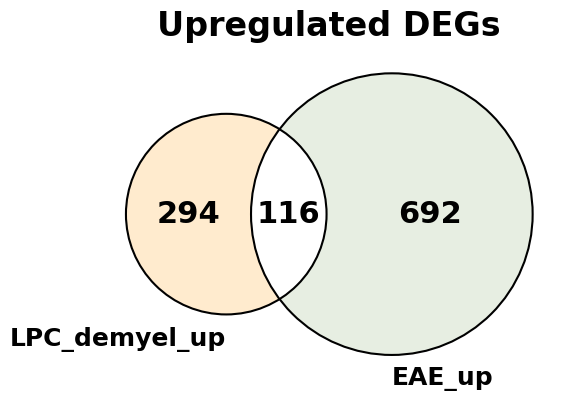

In [100]:
# Define your gene sets
set_mol_eae_up_genes = set(MOL_EAE_up)
set_lpc_de_up_genes = set(LPC_de_up['gene'])

plot_venn2_from_sets(
    set1=set_lpc_de_up_genes,
    set2=set_mol_eae_up_genes,
    labels=('LPC_demyel_up', 'EAE_up'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Upregulated DEGs',
    #save_path='figures/up_overlap.png'  # optional
)

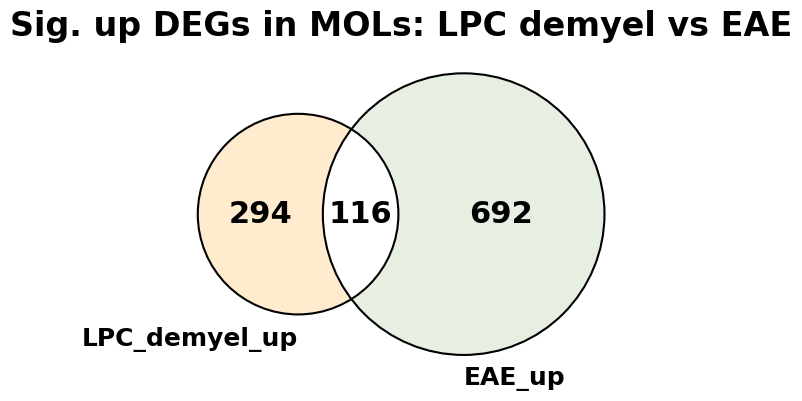

In [101]:
# Define your gene sets
set_mol_eae_up_genes = set(MOL_EAE_up)
set_lpc_de_up_genes = set(LPC_de_up['gene'])

# Call the function
plot_venn2_from_sets(
    set1=set_lpc_de_up_genes,
    set2=set_mol_eae_up_genes,
    labels=('LPC_demyel_up', 'EAE_up'),
    colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs: LPC demyel vs EAE'
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

Saved Venn diagram to: ./figures/venn2_CPZ_demyel_EAE_up.png


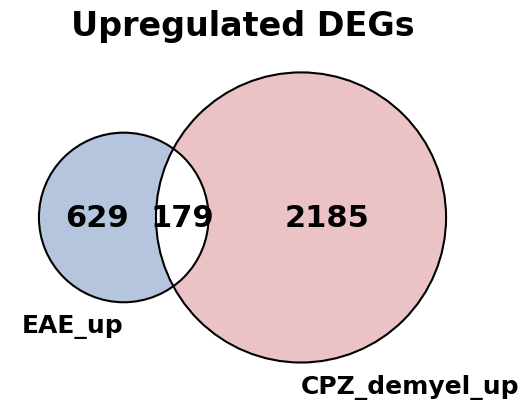

In [31]:
# Define your gene sets
set_mol_eae_up_genes = set(MOL_EAE_up)
set_Cupr_de_up = set(genes_Cupr_de_up)

# Call the function
plot_venn2_from_sets(
    set1=set_mol_eae_up_genes,
    set2=set_Cupr_de_up,
    labels=('EAE_up', 'CPZ_demyel_up'),
    colors=('#a3b7d5', '#e7b5b9'),
    title='Upregulated DEGs',
    save_path='./figures/venn2_CPZ_demyel_EAE_up.png'  # None
)

Saved Venn diagram to: ./figures/venn2_CPZ_demyel_EAE_down.png


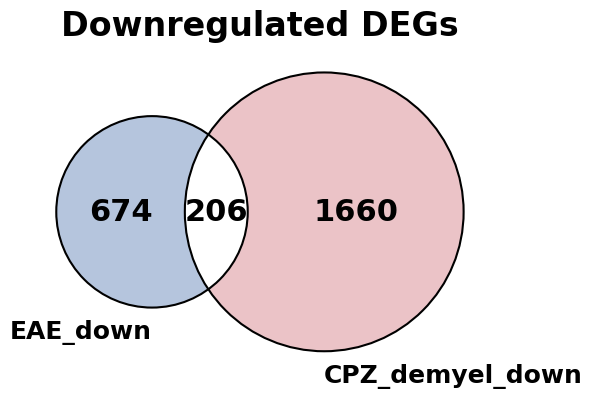

In [32]:
set_mol_eae_down_genes = set(MOL_EAE_down)

# Call the function
plot_venn2_from_sets(
    set1=set_mol_eae_down_genes,
    set2=set_Cupr_de_down,
    labels=('EAE_down', 'CPZ_demyel_down'),
    colors=('#a3b7d5', '#e7b5b9'),
    title='Downregulated DEGs',
    save_path='./figures/venn2_CPZ_demyel_EAE_down.png'  # None
)

In [29]:
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt

def plot_venn3_from_sets(set1, set2, set3, labels, colors, title, save_path=None):
    """
    Plots a 3-set Venn diagram with automatic circle and label styling.

    Parameters:
    - set1, set2, set3: sets of gene names
    - labels: tuple of 3 labels (str)
    - colors: tuple of 3 hex color strings
    - title: plot title (str)
    - save_path: optional path to save the figure (e.g., 'figs/my_venn.png')
    """
    # Compute subset sizes
    only1 = len(set1 - set2 - set3)
    only2 = len(set2 - set1 - set3)
    only3 = len(set3 - set1 - set2)

    shared12 = len(set1 & set2 - set3)
    shared13 = len(set1 & set3 - set2)
    shared23 = len(set2 & set3 - set1)

    shared123 = len(set1 & set2 & set3)

    subsets = (only1, only2, shared12, only3, shared13, shared23, shared123)

    # Plot Venn
    plt.figure(figsize=(6, 6))
    venn = venn3(
        subsets=subsets,
        set_labels=labels,
        set_colors=colors,
        alpha=0.8
    )

    # Circles
    circles = venn3_circles(subsets=subsets, linestyle='solid')
    for c in circles:
        if c:
            c.set_linewidth(1.5)
            c.set_edgecolor('black')

    # Subset labels (numbers inside)
    for subset in venn.subset_labels:
        if subset:
            subset.set_fontsize(22)
            subset.set_fontweight('bold')  # Make bold

    # Set labels (group names)
    for text in venn.set_labels:
        if text:
            text.set_fontsize(18)
            text.set_fontweight('bold')  # Optional — bold the group labels too

    # Title
    plt.title(title, fontsize=24, fontweight='bold')

    # Save if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='none')
        print(f"Saved Venn diagram to: {save_path}")

    plt.show()

Saved Venn diagram to: figures/up_overlap_LPC_EAE.png


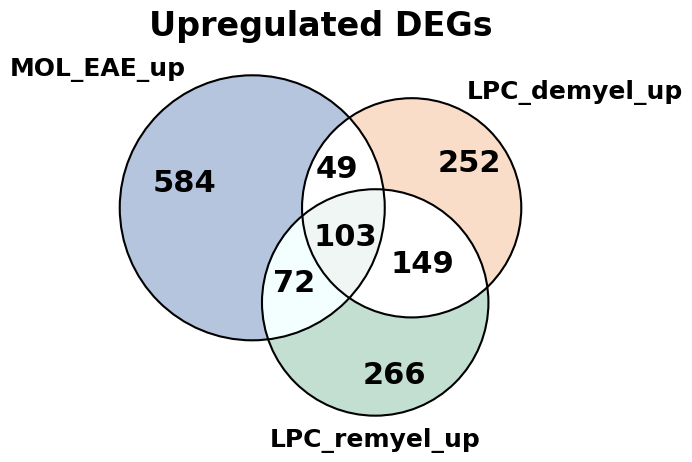

In [33]:
# Example: Up-regulated gene Venn
#set_colors = ('#f9d5bb', '#b4d7c7', '#e7b5b9')

plot_venn3_from_sets(
    set1=mol_eae_up_genes,
    set2=lpc_de_up_genes,
    set3=lpc_re_up_genes,
    labels=('MOL_EAE_up', 'LPC_demyel_up', 'LPC_remyel_up'),
    colors=('#a3b7d5', '#f9d5bb', '#b4d7c7'),
    title='Upregulated DEGs',
    save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

Saved Venn diagram to: figures/down_overlap_LPC_EAE.png


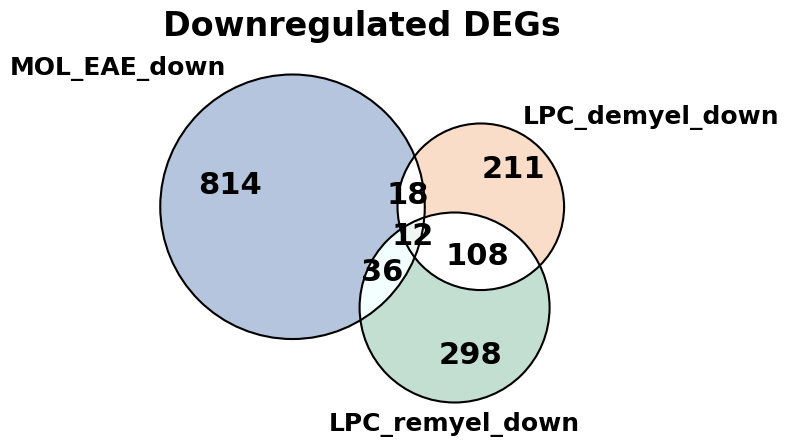

In [34]:
# Example: Down-regulated gene Venn
plot_venn3_from_sets(
    set1=mol_eae_down_genes,
    set2=lpc_de_down_genes,
    set3=lpc_re_down_genes,
    labels=('MOL_EAE_down', 'LPC_demyel_down', 'LPC_remyel_down'),
    colors=('#a3b7d5', '#f9d5bb', '#b4d7c7'),
    title='Downregulated DEGs',
    save_path='figures/down_overlap_LPC_EAE.png'  # optional
)

In [107]:
shared_lpc = mol_eae_up_genes & lpc_de_up_genes & lpc_re_up_genes
print("Genes shared by all three (upregulated):", len(shared_lpc))
print(shared_lpc)

Genes shared by all three (upregulated): 103
{'Stat2', 'Dner', 'H2-D1', 'Klhdc8a', 'Ifi27', 'Klk6', 'Nol3', 'Cerk', 'B2m', 'Cntfr', 'Stat1', 'Mt2', 'Nlrc5', 'Socs3', 'Gpd1', 'Rhoj', 'Pros1', 'Srd5a1', 'Anxa2', 'S100a10', 'Acot11', 'Irgm2', 'St3gal1', 'Ltbp3', 'Bcl3', 'Zc3hav1', 'Vwa1', 'Rhoc', 'Msrb1', 'Stat3', 'Irf1', 'Gadd45b', 'Serpina3n', 'Piezo2', 'Farp1', 'Inpp4a', 'Dgka', 'Col23a1', 'Mt1', 'Thbs3', 'Mfap3l', 'Grik3', 'Steap3', 'Rab3b', 'Srxn1', 'Apoe', 'Nsg1', 'Gadd45a', 'Rasip1', 'Dgat2', 'Vim', 'Trpv4', 'Grasp', 'H2-K1', 'Cstb', 'Cacng5', 'Trib1', 'Cd63', 'Irgm1', 'Ppl', 'Lbh', 'Chst8', 'Rtp4', 'Slc16a2', 'Syne2', 'Cadps2', 'Irf9', 'Diras1', 'Adamtsl3', 'Slc39a14', 'Adssl1', 'Klk9', 'Parp3', 'Rgs20', 'Flnc', 'Hmox1', 'Sspo', 'Cebpd', 'Cmbl', 'Ogdhl', 'Slc9a3r2', 'Plscr3', 'Arpc1b', 'Plvap', 'Ndst1', 'Tspan4', 'Fjx1', 'Cela1', 'C4b', 'Parp12', 'Fxyd1', 'Mamstr', 'Il33', 'Aldh3b1', 'Uap1l1', 'Snx10', 'Fgfr4', 'Neat1', 'Lgi4', 'Cd151', 'Vamp5', 'Ifi35', 'Plekha1'}


In [108]:
cupr_eae_up = mol_eae_up_genes & cupr_de_up_genes
print("Genes shared by Cupr_G and EAE (upregulated):", len(cupr_eae_up))
print(cupr_eae_up)

Genes shared by Cupr_G and EAE (upregulated): 179
{'Bap1', 'Dner', 'H2-D1', 'Gfra1', 'Alkbh3', 'Casp7', 'Klk6', 'Slc12a4', 'Rims2', 'B2m', 'Stat1', 'Psmd13', 'Mmachc', 'Lrrc8c', 'Ppp2r5d', 'Pxylp1', 'Mt2', 'Etf1', 'Fyn', 'Rheb', 'Eif4e3', 'Socs3', 'Por', 'Gpd1', 'Supt6', 'Rhoj', 'Pros1', 'Rnf125', 'Gm15417', 'Ltbr', 'Ddx24', 'Anxa2', 'Jade2', 'Tap2', 'Rnf115', 'Btbd16', 'Api5', 'Sgk1', 'Vwa5a', 'Apod', 'Odc1', 'Ltbp3', 'Afap1l2', 'Lamp2', 'Rhoc', 'Stat3', 'Arf3', 'Cdkn1a', 'Prkce', 'Lysmd2', 'Bcat1', 'Tmem38a', 'Zbtb7b', 'Scg3', 'Gdap1', 'Klf15', 'Gadd45b', 'Tgfbr3', 'Rras', 'Laptm4a', 'Gpatch4', 'Serpina3n', 'Polr2a', 'Bcan', 'Soga3', 'Nsf', 'Txnrd1', 'Inpp4a', 'Nme1', 'Gpx1', 'Junb', 'Mt1', 'Grik3', 'Cpne3', 'Dnm2', 'Mvp', 'Steap3', 'Rab3b', 'Srxn1', 'Gadd45a', 'Lrrtm2', 'Chchd10', 'Rasip1', 'Galnt2', 'Ric3', 'Vim', 'Sptan1', 'Tspo', 'Mcm4', 'Cyb5r3', 'Zyx', 'Eprs', 'Tle3', 'Egr1', 'Cacng5', 'Cd63', 'Hist1h1c', 'Irf3', 'Tmem199', 'Qsox2', 'Crip2', 'Chmp1a', 'Coq9', 'Emd', 'Lbh', 'Dpp

In [109]:
lpc_not_cupr = shared_lpc- cupr_eae_up
print("Genes shared by LPC not cupr UP:", len(lpc_not_cupr))
print(lpc_not_cupr)

Genes shared by LPC not cupr UP: 60
{'Irgm1', 'Stat2', 'Ppl', 'Irf1', 'Ndst1', 'Klhdc8a', 'Ifi27', 'Fjx1', 'Nol3', 'Chst8', 'Cerk', 'H2-K1', 'Rtp4', 'Cntfr', 'Piezo2', 'Farp1', 'Fxyd1', 'Mamstr', 'Dgka', 'Nlrc5', 'Il33', 'Cadps2', 'Diras1', 'Aldh3b1', 'Col23a1', 'Thbs3', 'Mfap3l', 'Slc39a14', 'Adssl1', 'Klk9', 'Uap1l1', 'Srd5a1', 'Snx10', 'Fgfr4', 'S100a10', 'Apoe', 'Acot11', 'Flnc', 'Irgm2', 'Nsg1', 'Neat1', 'Hmox1', 'Lgi4', 'Dgat2', 'Sspo', 'Vamp5', 'Ifi35', 'St3gal1', 'Cmbl', 'Trpv4', 'Ogdhl', 'Bcl3', 'Plscr3', 'Grasp', 'Zc3hav1', 'Vwa1', 'Cstb', 'Msrb1', 'Trib1', 'Plekha1'}


In [110]:
cupr_not_lpc = cupr_eae_up - shared_lpc
print("Genes shared by LPC not cupr UP:", len(cupr_not_lpc))
print(cupr_not_lpc)

Genes shared by LPC not cupr UP: 136
{'Bap1', 'Gfra1', 'Alkbh3', 'Casp7', 'Slc12a4', 'Rims2', 'Psmd13', 'Mmachc', 'Lrrc8c', 'Ppp2r5d', 'Pxylp1', 'Etf1', 'Fyn', 'Rheb', 'Eif4e3', 'Por', 'Supt6', 'Gm15417', 'Rnf125', 'Ltbr', 'Ddx24', 'Jade2', 'Tap2', 'Rnf115', 'Btbd16', 'Api5', 'Sgk1', 'Vwa5a', 'Apod', 'Odc1', 'Afap1l2', 'Lamp2', 'Arf3', 'Cdkn1a', 'Prkce', 'Lysmd2', 'Bcat1', 'Tmem38a', 'Zbtb7b', 'Scg3', 'Gdap1', 'Klf15', 'Tgfbr3', 'Rras', 'Laptm4a', 'Gpatch4', 'Polr2a', 'Bcan', 'Soga3', 'Nsf', 'Txnrd1', 'Nme1', 'Gpx1', 'Junb', 'Cpne3', 'Dnm2', 'Mvp', 'Lrrtm2', 'Chchd10', 'Galnt2', 'Ric3', 'Sptan1', 'Tspo', 'Mcm4', 'Cyb5r3', 'Zyx', 'Eprs', 'Tle3', 'Egr1', 'Hist1h1c', 'Irf3', 'Tmem199', 'Qsox2', 'Crip2', 'Chmp1a', 'Coq9', 'Emd', 'Dpp9', 'Slc35f6', 'Tex261', 'Rlim', 'Dhx16', 'Stmn3', 'Gale', 'Maml2', 'Mzt2', 'A930015D03Rik', 'Ogfr', 'Psmc2', 'Gdap1l1', 'Klf9', 'Gria2', 'Nupr1', 'Psmd2', 'Tceal8', 'Leo1', 'Mafk', 'Pqlc3', 'Arap2', 'Irf2bpl', 'Ddx52', 'Erap1', 'Xpnpep1', 'Dhrs7', 'Ubb', 'Smpd

In [111]:
shared_all = mol_eae_up_genes & lpc_de_up_genes & lpc_re_up_genes & cupr_de_up_genes
print("Genes shared by all three (upregulated):", len(shared_all))
print(shared_all)

Genes shared by all three (upregulated): 43
{'Plvap', 'Dner', 'H2-D1', 'Tspan4', 'Gadd45b', 'Lbh', 'Klk6', 'Cela1', 'Serpina3n', 'C4b', 'B2m', 'Stat1', 'Parp12', 'Slc16a2', 'Inpp4a', 'Mt2', 'Syne2', 'Irf9', 'Socs3', 'Adamtsl3', 'Gpd1', 'Mt1', 'Grik3', 'Rhoj', 'Pros1', 'Anxa2', 'Parp3', 'Steap3', 'Rab3b', 'Srxn1', 'Rgs20', 'Gadd45a', 'Rasip1', 'Cd151', 'Cebpd', 'Vim', 'Slc9a3r2', 'Ltbp3', 'Arpc1b', 'Rhoc', 'Cacng5', 'Stat3', 'Cd63'}


In [112]:
shared_lpc_down = mol_eae_down_genes & lpc_de_down_genes & lpc_re_down_genes
print("Genes shared by all (upregulated):", len(shared_lpc_down))
print(shared_lpc_down)

Genes shared by all (upregulated): 12
{'Adamts20', 'Kcnu1', 'Lama2', 'Cdh10', 'Slc1a3', 'Tet1', 'Cdh20', 'Trim7', 'Dclk1', 'Slc5a11', 'Lgr4', 'Jph1'}


In [113]:
shared_cpz_down = mol_eae_down_genes & cupr_de_down_genes
print("Genes shared by all three (upregulated):", len(shared_cpz_down))
print(shared_cpz_down)

Genes shared by all three (upregulated): 206
{'Shroom3', 'Tenm2', 'Prkcz', 'Srgap1', 'Ddah2', 'Cdc14b', 'Creg2', 'Dact3', 'Tbc1d14', 'Dip2a', 'Mpdz', 'Mboat1', 'Iffo1', 'Pag1', 'Dgkq', 'Rffl', 'Dlg1', 'Ncoa3', 'Exoc6b', 'Ndufa7', 'Tfdp2', 'Glod4', 'Stxbp6', 'Mef2a', 'Agrn', 'Tmem144', 'Abl1', 'Kctd7', 'Pcsk6', 'Magi2', 'Adap1', 'Tmem256', 'Bfsp2', 'Apba1', 'Pan3', 'Rnf220', 'Rasgrp3', 'Arhgef28', 'Nsdhl', 'Dach2', 'Bicd2', 'Dip2b', 'Hs6st1', 'Col9a1', 'Sil1', 'Tspan5', 'Hipk2', 'Tecpr2', 'Macrod1', 'Eif4g3', 'Fgd3', 'Gprc5b', 'Usp30', 'Sgip1', 'Itgb4', 'Phlpp1', 'Pqbp1', 'Pld1', 'Shroom2', 'Gpr137b', 'Scmh1', 'Llgl1', 'Pnmal1', 'Psd3', 'Jph1', 'Luzp2', 'Scg5', 'Cdh10', 'Scamp5', 'Pea15a', 'Tet1', 'Sel1l3', 'Fnip1', 'Ahcyl1', 'Mast4', 'Amph', 'Gabbr1', 'Zfp280c', 'Slc1a3', 'Ssr4', 'Osbpl1a', 'Dclk1', 'Tln2', 'Ppm1h', 'Slc5a11', 'Cttnbp2', 'Plekhh1', 'Hdac11', 'Ank', 'Rbak', 'Chdh', 'Abhd17b', 'Fcho2', 'Il18', 'E130307A14Rik', 'Pogk', 'Tma7', 'Ell2', 'Stk38', 'Frmd4b', 'Nxt2', 'Tirap', '

In [114]:
shared_all_down = mol_eae_down_genes & lpc_de_down_genes & lpc_re_down_genes & cupr_de_down_genes
print("Genes shared by all (upregulated):", len(shared_all_down))
print(shared_all_down)

Genes shared by all (upregulated): 10
{'Adamts20', 'Kcnu1', 'Lama2', 'Cdh10', 'Slc1a3', 'Tet1', 'Cdh20', 'Dclk1', 'Slc5a11', 'Jph1'}


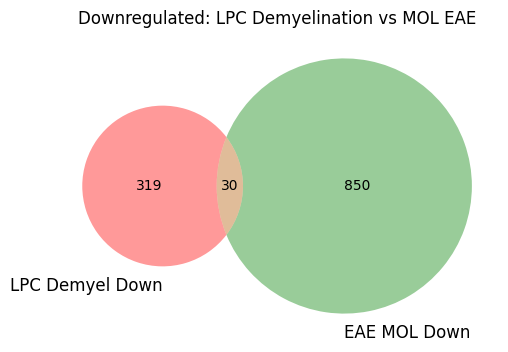

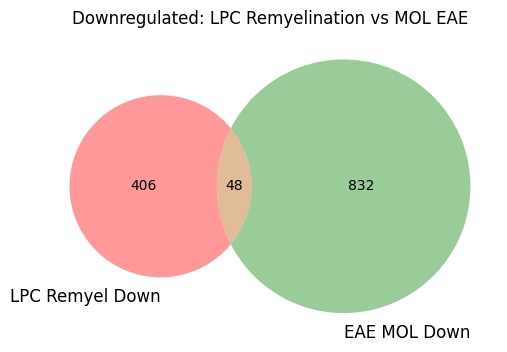

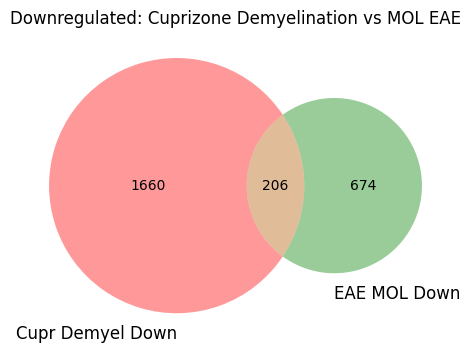

In [110]:
# -------- Venn Diagrams: DOWNREGULATED --------
# LPC Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([lpc_de_down_genes, mol_eae_down_genes], set_labels=('LPC Demyel Down', 'EAE MOL Down'))
plt.title("Downregulated: LPC Demyelination vs MOL EAE")
plt.show()

# LPC Remyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([lpc_re_down_genes, mol_eae_down_genes], set_labels=('LPC Remyel Down', 'EAE MOL Down'))
plt.title("Downregulated: LPC Remyelination vs MOL EAE")
plt.show()

# Cuprizone Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([cupr_de_down_genes, mol_eae_down_genes], set_labels=('Cupr Demyel Down', 'EAE MOL Down'))
plt.title("Downregulated: Cuprizone Demyelination vs MOL EAE")
plt.show()

In [122]:
cupr_eae_down = mol_eae_down_genes & cupr_de_down_genes
print("Genes shared by Cupr_G and EAE (upregulated):", len(cupr_eae_down))
print(cupr_eae_down)

Genes shared by Cupr_G and EAE (upregulated): 206
{'Pkn1', 'Cdh10', 'Exoc6b', 'Sgip1', 'Phlpp1', 'Ell2', 'Rps6ka1', 'Tecpr2', 'Jph1', 'Cdc14b', 'Gpr155', 'Gm13293', 'Hipk2', 'Npat', 'Rbak', 'Ank', 'Slc1a3', 'Cttnbp2', 'Kctd7', 'Ncoa3', 'Ssr4', 'Sil1', 'Tns1', 'Arhgef28', 'Mast4', 'Pak7', 'Stard5', 'Jak2', 'Tmem256', 'Cd59a', 'Dram2', 'Fam102a', 'Rab11fip3', 'Phc1', 'Pacs2', 'Pcyt2', 'Cds1', 'Ptk2', 'Myo1d', 'E130307A14Rik', 'Ano4', 'Rffl', 'Sdf2l1', 'Gpr137b', 'Tfdp2', 'Dlg1', 'Pag1', 'Mapre2', 'Mpp2', 'Dock3', 'Gnptab', 'Dnmt3a', 'Ddah2', 'Tmem117', 'Tspan5', 'Gdi1', 'Dcps', 'Creg2', 'Srgap1', 'Ddr1', 'St13', 'Abca8b', 'Dip2b', 'Psd3', 'Lrp1b', 'Plxnb3', 'Arnt2', 'Adam18', 'Snx30', 'Atat1', 'Plekhh1', 'Papss1', 'Fsd1l', 'Kcnu1', 'Prkcz', 'Itgb4', 'Vps29', 'Ccdc82', 'Dach2', 'Il17rb', 'Adap1', 'Rbbp9', 'Slc35a5', 'Adamts20', 'Tst', 'Dgkq', 'Ppm1h', 'Map7d1', 'Fnip1', 'Dip2a', 'Ap5z1', 'Tln2', 'Nxt2', 'Lama2', 'Luzp2', 'Pea15a', 'Tspan15', 'Sybu', 'Fcho2', 'Otud7b', 'Zdhhc9', 'Agrn', 'O

In [142]:
cupr_eae_down_unique = mol_eae_down_genes & cupr_de_down_genes - lpc_de_down_genes - lpc_re_down_genes 
print("Genes shared by Cupr_G and EAE (upregulated):", len(cupr_eae_down_unique))
print(cupr_eae_down_unique)

Genes shared by Cupr_G and EAE (upregulated): 168
{'Pkn1', 'Exoc6b', 'Phlpp1', 'Ell2', 'Rps6ka1', 'Tecpr2', 'Gpr155', 'Gm13293', 'Hipk2', 'Npat', 'Rbak', 'Ank', 'Kctd7', 'Ncoa3', 'Ssr4', 'Sil1', 'Tns1', 'Arhgef28', 'Mast4', 'Stard5', 'Jak2', 'Tmem256', 'Cd59a', 'Dram2', 'Fam102a', 'Rab11fip3', 'Phc1', 'Pacs2', 'Pcyt2', 'Cds1', 'Ptk2', 'Myo1d', 'E130307A14Rik', 'Ano4', 'Rffl', 'Sdf2l1', 'Gpr137b', 'Tfdp2', 'Dlg1', 'Pag1', 'Mpp2', 'Gnptab', 'Dnmt3a', 'Ddah2', 'Gdi1', 'Dcps', 'Srgap1', 'Ddr1', 'St13', 'Abca8b', 'Dip2b', 'Psd3', 'Arnt2', 'Plxnb3', 'Snx30', 'Atat1', 'Papss1', 'Prkcz', 'Itgb4', 'Vps29', 'Ccdc82', 'Il17rb', 'Adap1', 'Rbbp9', 'Slc35a5', 'Dgkq', 'Tst', 'Ppm1h', 'Map7d1', 'Fnip1', 'Dip2a', 'Ap5z1', 'Nxt2', 'Pea15a', 'Tspan15', 'Sybu', 'Fcho2', 'Otud7b', 'Zdhhc9', 'Agrn', 'Osbpl1a', 'Rabgap1l', 'Firre', 'Porcn', 'Hs6st1', 'Lipa', 'Itgav', 'Msrb2', 'Kif21a', 'Gprc5b', 'Cdk5', 'Glod4', 'Apba1', 'Abhd17b', 'Luc7l2', 'Stk38', 'Rap1b', 'Dad1', 'Sv2a', 'Tenm2', 'Pigp', 'Nsdhl', 'Mtf1',

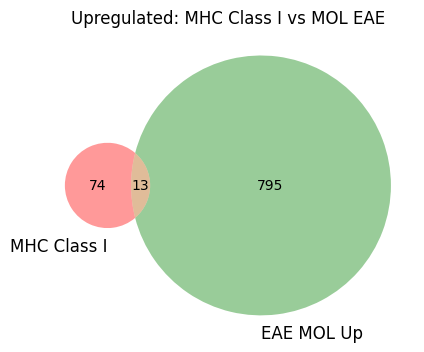

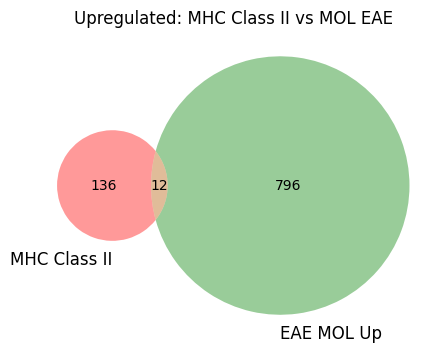

In [111]:
# -------- Venn Diagrams: EAE and MHC --------
# LPC Demyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([mhc_i_genes_set, mol_eae_up_genes], set_labels=('MHC Class I', 'EAE MOL Up'))
plt.title("Upregulated: MHC Class I vs MOL EAE")
plt.show()

# LPC Remyelination vs MOL EAE
plt.figure(figsize=(6, 4))
venn2([mhc_ii_genes_set, mol_eae_up_genes], set_labels=('MHC Class II', 'EAE MOL Up'))
plt.title("Upregulated: MHC Class II vs MOL EAE")
plt.show()

In [114]:
mhc_i_eae = mol_eae_up_genes & mhc_i_genes_set
print("Genes shared by all three (upregulated):", len(mhc_i_eae))
print(mhc_i_eae)

Genes shared by all three (upregulated): 13
{'H2-D1', 'Nlrc5', 'H2-K1', 'Tapbpl', 'Tap2', 'Il33', 'Tapbp', 'Tap1', 'B2m', 'Derl1', 'Hfe', 'H2-T24', 'H2-T23'}


In [115]:
mhc_ii_eae = mol_eae_up_genes & mhc_ii_genes_set
print("Genes shared by all three (upregulated):", len(mhc_ii_eae))
print(mhc_ii_eae)

Genes shared by all three (upregulated): 12
{'Ctss', 'H2-Eb1', 'Dnm2', 'Ctsb', 'Tubb3', 'Unc93b1', 'Il33', 'Tuba4a', 'B2m', 'H2-Ab1', 'Ctso', 'Sec24c'}


# NEW PSEUDOBULK HEATMAP OF KEY GENES

## Macnair like figure?

In [16]:
adata_lpc = sc.read('./pb_adata_LPC_all_NEW_CELL_TYPES.h5ad')
adata_lpc

AnnData object with n_obs × n_vars = 31 × 18877
    obs: 'publication', 'label', 'cell_type', 'replicate_cat', 'sample', 'sample_rep', 'batch', 'lib_size', 'log_lib_size', 'replicate'
    uns: 'cell_type_colors', 'label_colors', 'log1p', 'pca', 'publication_colors', 'replicate_cat_colors', 'sample_colors', 'sample_rep_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [17]:
adata_lpc.obs[:5]

,publication,label,cell_type,replicate_cat,sample,sample_rep,batch,lib_size,log_lib_size,replicate
donor_ctrl_1_0-0,(this study),ctrl,MOL,1,ctrl_1,LPC_Saline_2,0,2632365,14.783393,1
donor_ctrl_2_0-0,(this study),ctrl,MOL,2,ctrl_2,LPC_Saline_1,0,5214473,15.466949,2
donor_ctrl_3_0-0,Pandey et al. 2022,ctrl,MOL,3,ctrl_3,LPC_ctrl_3,0,7503756,15.830914,3
donor_ctrl_4_0-0,Pandey et al. 2022,ctrl,MOL,4,ctrl_4,LPC_ctrl_2,0,35250126,17.377980,4
donor_ctrl_5_0-0,Pandey et al. 2022,ctrl,MOL,5,ctrl_5,LPC_ctrl_1,0,20518780,16.836851,5


In [18]:
adata_cpz = sc.read('./pb_adata_CUPR_all_NEW_CELL_TYPES.h5ad')
adata_cpz

AnnData object with n_obs × n_vars = 18 × 19913
    obs: 'publication', 'label', 'cell_type', 'replicate_cat', 'sample', 'sample_rep', 'batch', 'lib_size', 'log_lib_size', 'replicate'
    uns: 'cell_type_colors', 'label_colors', 'log1p', 'pca', 'publication_colors', 'replicate_cat_colors', 'sample_colors', 'sample_rep_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [19]:
adata_cpz.obs[:5]

,publication,label,cell_type,replicate_cat,sample,sample_rep,batch,lib_size,log_lib_size,replicate
donor_ctrl_1_0-0,(this study),ctrl,MOL,1,ctrl_1,Cupr_ctrl_Adams_1,0,1312170,14.087193,1
donor_ctrl_2_0-0,(this study),ctrl,MOL,2,ctrl_2,Cupr_ctrl_Adams_2,0,530939,13.182402,2
donor_ctrl_3_0-0,Shen et al. 2021,ctrl,MOL,3,ctrl_3,Cupr_ctrl_Shen_2,0,8205413,15.920305,3
donor_ctrl_4_0-0,Shen et al. 2021,ctrl,MOL,4,ctrl_4,Cupr_ctrl_Shen_1,0,12472042,16.339000,4
donor_ctrl_5_0-0,Shen et al. 2021,ctrl,MOL,5,ctrl_5,Cupr_ctrl_Shen_3,0,8216113,15.921608,5


In [20]:
import anndata as ad
adata_merged = ad.concat([adata_lpc, adata_cpz], join='inner', label='source', keys=['lpc', 'cpz'], index_unique='-')
adata_merged

AnnData object with n_obs × n_vars = 49 × 18877
    obs: 'publication', 'label', 'cell_type', 'replicate_cat', 'sample', 'sample_rep', 'batch', 'lib_size', 'log_lib_size', 'replicate', 'source'
    obsm: 'X_pca'
    layers: 'counts'

In [21]:
adata_merged.obs[:5]

,publication,label,cell_type,replicate_cat,sample,sample_rep,batch,lib_size,log_lib_size,replicate,source
donor_ctrl_1_0-0-lpc,(this study),ctrl,MOL,1,ctrl_1,LPC_Saline_2,0,2632365,14.783393,1,lpc
donor_ctrl_2_0-0-lpc,(this study),ctrl,MOL,2,ctrl_2,LPC_Saline_1,0,5214473,15.466949,2,lpc
donor_ctrl_3_0-0-lpc,Pandey et al. 2022,ctrl,MOL,3,ctrl_3,LPC_ctrl_3,0,7503756,15.830914,3,lpc
donor_ctrl_4_0-0-lpc,Pandey et al. 2022,ctrl,MOL,4,ctrl_4,LPC_ctrl_2,0,35250126,17.377980,4,lpc
donor_ctrl_5_0-0-lpc,Pandey et al. 2022,ctrl,MOL,5,ctrl_5,LPC_ctrl_1,0,20518780,16.836851,5,lpc


In [22]:
# Extract the data as a pandas DataFrame
df = adata_merged.obs[['cell_type', 'label']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'label']).size().unstack(fill_value=0)
summary_table

/tmp/2110800.1.long/ipykernel_1690081/3552265499.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df.groupby(['cell_type', 'label']).size().unstack(fill_value=0)


label,ctrl,stim
cell_type,,
MOL,10,20
OPCs,7,12


In [23]:
adata_MOL = adata_merged[np.in1d(adata_merged.obs['cell_type'], 
                           ['MOL'])].copy()

print("Dimensions of adata:", adata_MOL.shape)

Dimensions of adata: (30, 18877)


In [24]:
pub_map = {
    '(this study)': 'Adams',
    'Pandey et al. 2022': 'Pandey',
    'Shen et al. 2021': 'Shen'
}

# Update the 'treatment_meta' column based on the mapping
adata_MOL.obs['batch'] = adata_MOL.obs['publication'].map(pub_map)

In [25]:
# Check if the 'sample_rep' column exists
if 'sample_rep' in adata_MOL.obs.columns:
    # Set the 'sample_rep' column as the index
    adata_MOL.obs.set_index('sample_rep', inplace=True)
else:
    print("The column 'sample_rep' does not exist in adata_sub.obs.")

adata_MOL.obs.index.name = None

In [26]:
adata_MOL.obs[:5]

,publication,label,cell_type,replicate_cat,sample,batch,lib_size,log_lib_size,replicate,source
LPC_Saline_2,(this study),ctrl,MOL,1,ctrl_1,Adams,2632365,14.783393,1,lpc
LPC_Saline_1,(this study),ctrl,MOL,2,ctrl_2,Adams,5214473,15.466949,2,lpc
LPC_ctrl_3,Pandey et al. 2022,ctrl,MOL,3,ctrl_3,Pandey,7503756,15.830914,3,lpc
LPC_ctrl_2,Pandey et al. 2022,ctrl,MOL,4,ctrl_4,Pandey,35250126,17.377980,4,lpc
LPC_ctrl_1,Pandey et al. 2022,ctrl,MOL,5,ctrl_5,Pandey,20518780,16.836851,5,lpc


In [27]:
print(adata_MOL.obs_names.unique())

CategoricalIndex(['LPC_Saline_2', 'LPC_Saline_1', 'LPC_ctrl_3', 'LPC_ctrl_2',
                  'LPC_ctrl_1', 'LPC_7d_2', 'LPC_14d_2', 'LPC_5d_4',
                  'LPC_7d_1', 'LPC_5d_1', 'LPC_5d_3', 'LPC_28d_3', 'LPC_28d_1',
                  'LPC_5d_2', 'LPC_28d_2', 'LPC_14d_1', 'Cupr_ctrl_Adams_1',
                  'Cupr_ctrl_Adams_2', 'Cupr_ctrl_Shen_2', 'Cupr_ctrl_Shen_1',
                  'Cupr_ctrl_Shen_3', 'Cupr_5w_1', 'Cupr_5w_2', 'Cupr_4+3w_1',
                  'Cupr_4w_3', 'Cupr_4w_2', 'Cupr_4+3w_3', 'Cupr_4w_4',
                  'Cupr_4+3w_2', 'Cupr_4w_1'],
                 categories=['Cupr_4+3w_1', 'Cupr_4+3w_2', 'Cupr_4+3w_3', 'Cupr_4w_1', ..., 'LPC_Saline_2', 'LPC_ctrl_1', 'LPC_ctrl_2', 'LPC_ctrl_3'], ordered=False, dtype='category')


In [28]:
# Define the terms to subset by
subset_terms = [
    'Cupr_ctrl_Adams_1', 'Cupr_ctrl_Adams_2', 
    'Cupr_ctrl_Shen_2', 'Cupr_ctrl_Shen_1', 'Cupr_ctrl_Shen_3', 
    'Cupr_5w_1', 'Cupr_5w_2', 
    'Cupr_4w_3', 'Cupr_4w_2', 'Cupr_4w_1', 'Cupr_4w_4', 
    'LPC_Saline_2', 'LPC_Saline_1', 
    'LPC_ctrl_3', 'LPC_ctrl_2', 'LPC_ctrl_1', 
    'LPC_5d_3', 'LPC_5d_4', 'LPC_5d_2', 'LPC_5d_1', 
    'LPC_7d_2', 'LPC_7d_1',
    'LPC_28d_3', 'LPC_28d_1', 'LPC_28d_2'
]

# Subset the AnnData object by the index
adata_sub = adata_MOL[np.in1d(adata_MOL.obs.index, subset_terms)].copy()

# Print the dimensions of the subsetted AnnData object
print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (25, 18877)


## Create log2CPM df

In [29]:
# Calculate library size
lib_size = adata_sub.layers['counts'].sum(axis=1)
cpm = (adata_sub.layers['counts'].T / lib_size).T * 1e6

# Take log2(CPM + 1)
log2cpm = np.log2(cpm + 1)

# Store it (optional)
adata_sub.layers['log2CPM'] = log2cpm

In [30]:
# Define sample to pseudobulk group mapping
group_map = {
    'LPC_baseline': ['LPC_ctrl_1', 'LPC_ctrl_2', 'LPC_ctrl_3', 'LPC_Saline_1', 'LPC_Saline_2'],
    'LPC_demyel': ['LPC_5d_1', 'LPC_5d_2', 'LPC_5d_3', 'LPC_5d_4', 'LPC_7d_1', 'LPC_7d_2'],
    'LPC_remyel': ['LPC_28d_1', 'LPC_28d_2', 'LPC_28d_3'],
    'CPZ_baseline': ['Cupr_ctrl_Adams_1', 'Cupr_ctrl_Adams_2', 'Cupr_ctrl_Shen_1', 'Cupr_ctrl_Shen_2', 'Cupr_ctrl_Shen_3'],
    'CPZ_demyel': ['Cupr_4w_1', 'Cupr_4w_2', 'Cupr_4w_3', 'Cupr_4w_4', 'Cupr_5w_1', 'Cupr_5w_2']
}

# Create a new column with the pseudobulk group
def map_group(sample):
    for group, samples in group_map.items():
        if sample in samples:
            return group
    return 'Unknown'

adata_sub.obs['pseudobulk_group'] = adata_sub.obs.index.map(map_group)

In [31]:
# Create a DataFrame from log2CPM layer (genes x samples)
log2cpm_df = pd.DataFrame(
    adata_sub.layers['log2CPM'],
    index=adata_sub.obs.index,
    columns=adata_sub.var_names
)

# Add group labels to the DataFrame
log2cpm_df['group'] = adata_sub.obs['pseudobulk_group'].values

# Group by pseudobulk group and average
pseudobulk_df = log2cpm_df.groupby('group').mean().T  # Now genes x groups
pseudobulk_df.head

<bound method NDFrame.head of group          CPZ_baseline  CPZ_demyel  LPC_baseline  LPC_demyel  LPC_remyel
0610005C13Rik      0.628403    1.879981      1.030603    0.592142    0.606207
0610006L08Rik      0.170505    0.000000      0.052265    0.050682    0.161880
0610009B22Rik      3.887765    5.252618      3.887144    5.011341    5.843057
0610009E02Rik      0.807338    0.968965      1.121252    1.233057    1.077776
0610009L18Rik      2.655666    2.914056      2.933719    2.852216    3.728072
...                     ...         ...           ...         ...         ...
mt-Nd3             5.123267    5.900791      6.114294    6.239626    9.274332
mt-Nd4             6.290149    9.146204      6.765844    8.280024   11.116999
mt-Nd4l            3.886796    5.735563      5.214846    5.954513    8.580850
mt-Nd5             4.234390    6.848981      5.117811    5.762520    7.799392
mt-Nd6             2.003368    4.720225      3.285885    3.305475    4.559185

[18877 rows x 5 columns]>

In [32]:
pseudobulk_df.columns

Index(['CPZ_baseline', 'CPZ_demyel', 'LPC_baseline', 'LPC_demyel',
       'LPC_remyel'],
      dtype='object', name='group')

## Combine dfs for sig genes

In [33]:
LPC_demyel = pd.read_csv('./files/LPC_demyel_MOL_all_voom_wqw_UPDATED.csv', index_col=None)
LPC_demyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_demyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_demyel.shape

(11516, 7)

In [34]:
LPC_remyel = pd.read_csv('./files/LPC_remyel_MOL_all_voom_wqw_UPDATED.csv', index_col=None)
LPC_remyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_remyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_remyel.shape

(13049, 7)

In [35]:
Cupr_demyel = pd.read_csv('./files/Cupr_demyel_MOL_all_voom_wqw_UPDATED.csv', index_col=None)
Cupr_demyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
Cupr_demyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
Cupr_demyel.shape

(10536, 7)

In [36]:
LPC_demyel.head

<bound method NDFrame.head of             gene     logFC   AveExpr          t        Pvalue          Padj  \
0      Serpina3n  6.846376  6.343200  25.451413  2.798568e-12  2.293260e-08   
1          Masp1  3.692606  5.577334  24.741189  3.982737e-12  2.293260e-08   
2            C4b  4.153437  6.984800  23.125094  9.231433e-12  3.138267e-08   
3        Col16a1  2.868299  4.100386  22.817795  1.090055e-11  3.138267e-08   
4          Pros1  3.613816  4.020028  21.369416  2.458354e-11  5.662080e-08   
...          ...       ...       ...        ...           ...           ...   
11511      Acad9  0.000169  3.747521   0.000799  9.993748e-01  9.996749e-01   
11512      Ap5s1  0.000356  1.150338   0.000693  9.994580e-01  9.996749e-01   
11513      Maml2  0.000187  4.205177   0.000637  9.995013e-01  9.996749e-01   
11514     Topbp1 -0.000161  3.724362  -0.000461  9.996390e-01  9.997258e-01   
11515    Sigmar1  0.000104  1.729463   0.000255  9.998008e-01  9.998008e-01   

               B  
0 

In [37]:
# Keep only gene, logFC, Padj
df_lpc_demyel = LPC_demyel[['gene', 'logFC', 'Padj']].copy()
df_lpc_remyel = LPC_remyel[['gene', 'logFC', 'Padj']].copy()
df_cupr_demyel = Cupr_demyel[['gene', 'logFC', 'Padj']].copy()

# Rename columns to avoid name conflicts
df_lpc_demyel.columns = ['gene', 'logFC_LPC_demyel', 'Padj_LPC_demyel']
df_lpc_remyel.columns = ['gene', 'logFC_LPC_remyel', 'Padj_LPC_remyel']
df_cupr_demyel.columns = ['gene', 'logFC_Cupr_demyel', 'Padj_Cupr_demyel']

In [38]:
# Merge the three dataframes on gene
deg_merged = df_lpc_demyel.merge(df_lpc_remyel, on='gene', how='outer')
deg_merged = deg_merged.merge(df_cupr_demyel, on='gene', how='outer')

In [39]:
deg_merged.shape

(13131, 7)

In [40]:
# Subset: keep genes where any Padj column is < 0.05
deg_sig = deg_merged[
    (deg_merged['Padj_LPC_demyel'] <= 0.05) |
    (deg_merged['Padj_LPC_remyel'] <= 0.05) |
    (deg_merged['Padj_Cupr_demyel'] <= 0.05)
].copy()

deg_sig.shape

(6391, 7)

In [41]:
# Define DEG status per condition
deg_sig['DEG_LPC_demyel'] = (
    (deg_sig['Padj_LPC_demyel'] <= 0.05) &
    (deg_sig['logFC_LPC_demyel'].abs() >= 0.585)
)

deg_sig['DEG_LPC_remyel'] = (
    (deg_sig['Padj_LPC_remyel'] <= 0.05) &
    (deg_sig['logFC_LPC_remyel'].abs() >= 0.585)
)

deg_sig['DEG_Cupr_demyel'] = (
    (deg_sig['Padj_Cupr_demyel'] <= 0.05) &
    (deg_sig['logFC_Cupr_demyel'].abs() >= 0.585)
)

In [42]:
def get_sig_symbol(padj, deg):
    if not deg or pd.isnull(padj):
        return ''
    elif padj < 0.001:
        return '***'
    elif padj < 0.01:
        return '**'
    elif padj < 0.05:
        return '*'
    else:
        return ''

# Apply this for each condition
deg_sig['Sig_LPC_demyel'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['Padj_LPC_demyel'], row['DEG_LPC_demyel']), axis=1
)

deg_sig['Sig_LPC_remyel'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['Padj_LPC_remyel'], row['DEG_LPC_remyel']), axis=1
)

deg_sig['Sig_Cupr_demyel'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['Padj_Cupr_demyel'], row['DEG_Cupr_demyel']), axis=1
)

deg_sig.head

<bound method NDFrame.head of                 gene  logFC_LPC_demyel  Padj_LPC_demyel  logFC_LPC_remyel  \
0      0610009B22Rik          0.312578         0.618239          0.200095   
4      0610010K14Rik         -0.073897         0.938292          0.311130   
5      0610012G03Rik          0.910847         0.008920          0.228667   
9      0610040J01Rik         -3.109843         0.097726         -0.327542   
14     1110004F10Rik          0.067189         0.840716         -0.133375   
...              ...               ...              ...               ...   
13102         Zswim5         -0.247963         0.538240         -0.648435   
13104         Zswim7          0.101667         0.787084          0.332271   
13110          Zwint         -0.165404         0.691521         -0.027014   
13113         Zyg11b         -0.509898         0.196093         -0.616357   
13114            Zyx          0.416340         0.112566          0.050956   

       Padj_LPC_remyel  logFC_Cupr_demyel  Pa

## Combine the DEG sig and pseudobulk dfs

In [43]:
# Merge by gene name
merged_df = deg_sig.merge(
    pseudobulk_df, 
    left_on='gene', 
    right_index=True,  # pseudobulk_df uses gene names as index
    how='left'
)

merged_df.head

<bound method NDFrame.head of                 gene  logFC_LPC_demyel  Padj_LPC_demyel  logFC_LPC_remyel  \
0      0610009B22Rik          0.312578         0.618239          0.200095   
4      0610010K14Rik         -0.073897         0.938292          0.311130   
5      0610012G03Rik          0.910847         0.008920          0.228667   
9      0610040J01Rik         -3.109843         0.097726         -0.327542   
14     1110004F10Rik          0.067189         0.840716         -0.133375   
...              ...               ...              ...               ...   
13102         Zswim5         -0.247963         0.538240         -0.648435   
13104         Zswim7          0.101667         0.787084          0.332271   
13110          Zwint         -0.165404         0.691521         -0.027014   
13113         Zyg11b         -0.509898         0.196093         -0.616357   
13114            Zyx          0.416340         0.112566          0.050956   

       Padj_LPC_remyel  logFC_Cupr_demyel  Pa

### Test heatmap!

In [44]:
# Paste your gene lists
genes_lpc_tnfa = ["Cebpd", "Cdkn1a", "Fjx1", "Bcl3", "Socs3", "Irf1", "Trib1", "Cd44", "Tsc22d1"]
genes_lpc_ifny = ["Ifi35", "Cdkn1a", "Irf9", "Mt2", "Rtp4", "Socs3", "Irf1", "Nlrc5", "Stat3", "H2-D1", "Gbp3", "B2m", "Eif2ak2", "Parp12", "Vamp5", "Usp18", "Trim21", "Ifi27", "Stat1", "Stat2", "Ddx60"]
genes_lpc_ifna = ["Ifi35", "Irf9", "Rtp4", "Irf1", "Gbp3", "B2m", "Eif2ak2", "Parp12", "Usp18", "Trim21", "Csf1", "Ifi27", "Stat2", "Ddx60"]
genes_remyel_tnfa = ["Cebpd", "Socs3", "Bcl3", "Gadd45b", "Gadd45a", "Tsc22d1", "Irf1", "Tnfsf9", "Junb", "Zfp36", "Phlda1", "Fosl2", "Klf4", "Fos", "Slc16a6", "Abca1", "Myc", "Bcl6", "Kdm6b", "Nfil3", "Trib1", "Btg2"]
genes_remyel_ifny = ["Socs3", "B2m", "Irf1", "H2-D1", "Nlrc5", "Fgl2", "Mvp", "Mt2", "Ifi35", "Stat1", "Stat3", "Vamp8", "Trim25", "Irf9", "Vamp5", "Stat2", "Rsad2", "Ifi27"]
genes_cpz_tnfa = ["Cdkn1a", "Cebpd", "Ccnd1", "Btg3", "Cd44", "Vegfa", "Gadd45a", "Tsc22d1", "Nfil3", "Gadd45b", "Klf9", "Tubb2a", "Tiparp", "Egr2", "Socs3", "Plk2", "Klf4", "Myc", "Rcan1", "Btg1", "Tnc", "Phlda1", "Ppp1r15a", "Dusp1", "Egr1", "Fos", "Jun", "Plpp3", "Junb", "Klf6", "Btg2", "Rela", "Ier2", "Zfp36", "Yrdc"]
genes_cpz_ifny = ["Cdkn1a", "Mthfd2", "Mt2", "Casp3", "Casp7", "Socs3", "Arl4a", "Isoc1", "Stat3", "Btg1", "H2-D1", "Rapgef6", "Pfkp", "Txnip", "Arid5b", "B2m", "Irf9"]

# Combine and get unique genes
all_genes = set(
    genes_lpc_tnfa + genes_lpc_ifny + genes_lpc_ifna + 
    genes_remyel_tnfa + genes_remyel_ifny + 
    genes_cpz_tnfa + genes_cpz_ifny
)

In [45]:
# Subset merged_df
heatmap_df = merged_df[merged_df['gene'].isin(all_genes)].set_index('gene')

# Keep only relevant log2CPM columns (reorder if needed)
log2cpm_cols = ['LPC_demyel', 'LPC_remyel', 'CPZ_demyel', 'LPC_baseline', 'CPZ_baseline']
heatmap_data = heatmap_df[log2cpm_cols]

In [46]:
# Create a matrix of significance markers to overlay
sig_map = pd.DataFrame('', index=heatmap_df.index, columns=log2cpm_cols)

# Map Sig_* to the correct columns
sig_map['LPC_demyel'] = heatmap_df['Sig_LPC_demyel']
sig_map['LPC_remyel'] = heatmap_df['Sig_LPC_remyel']
sig_map['CPZ_demyel'] = heatmap_df['Sig_Cupr_demyel']

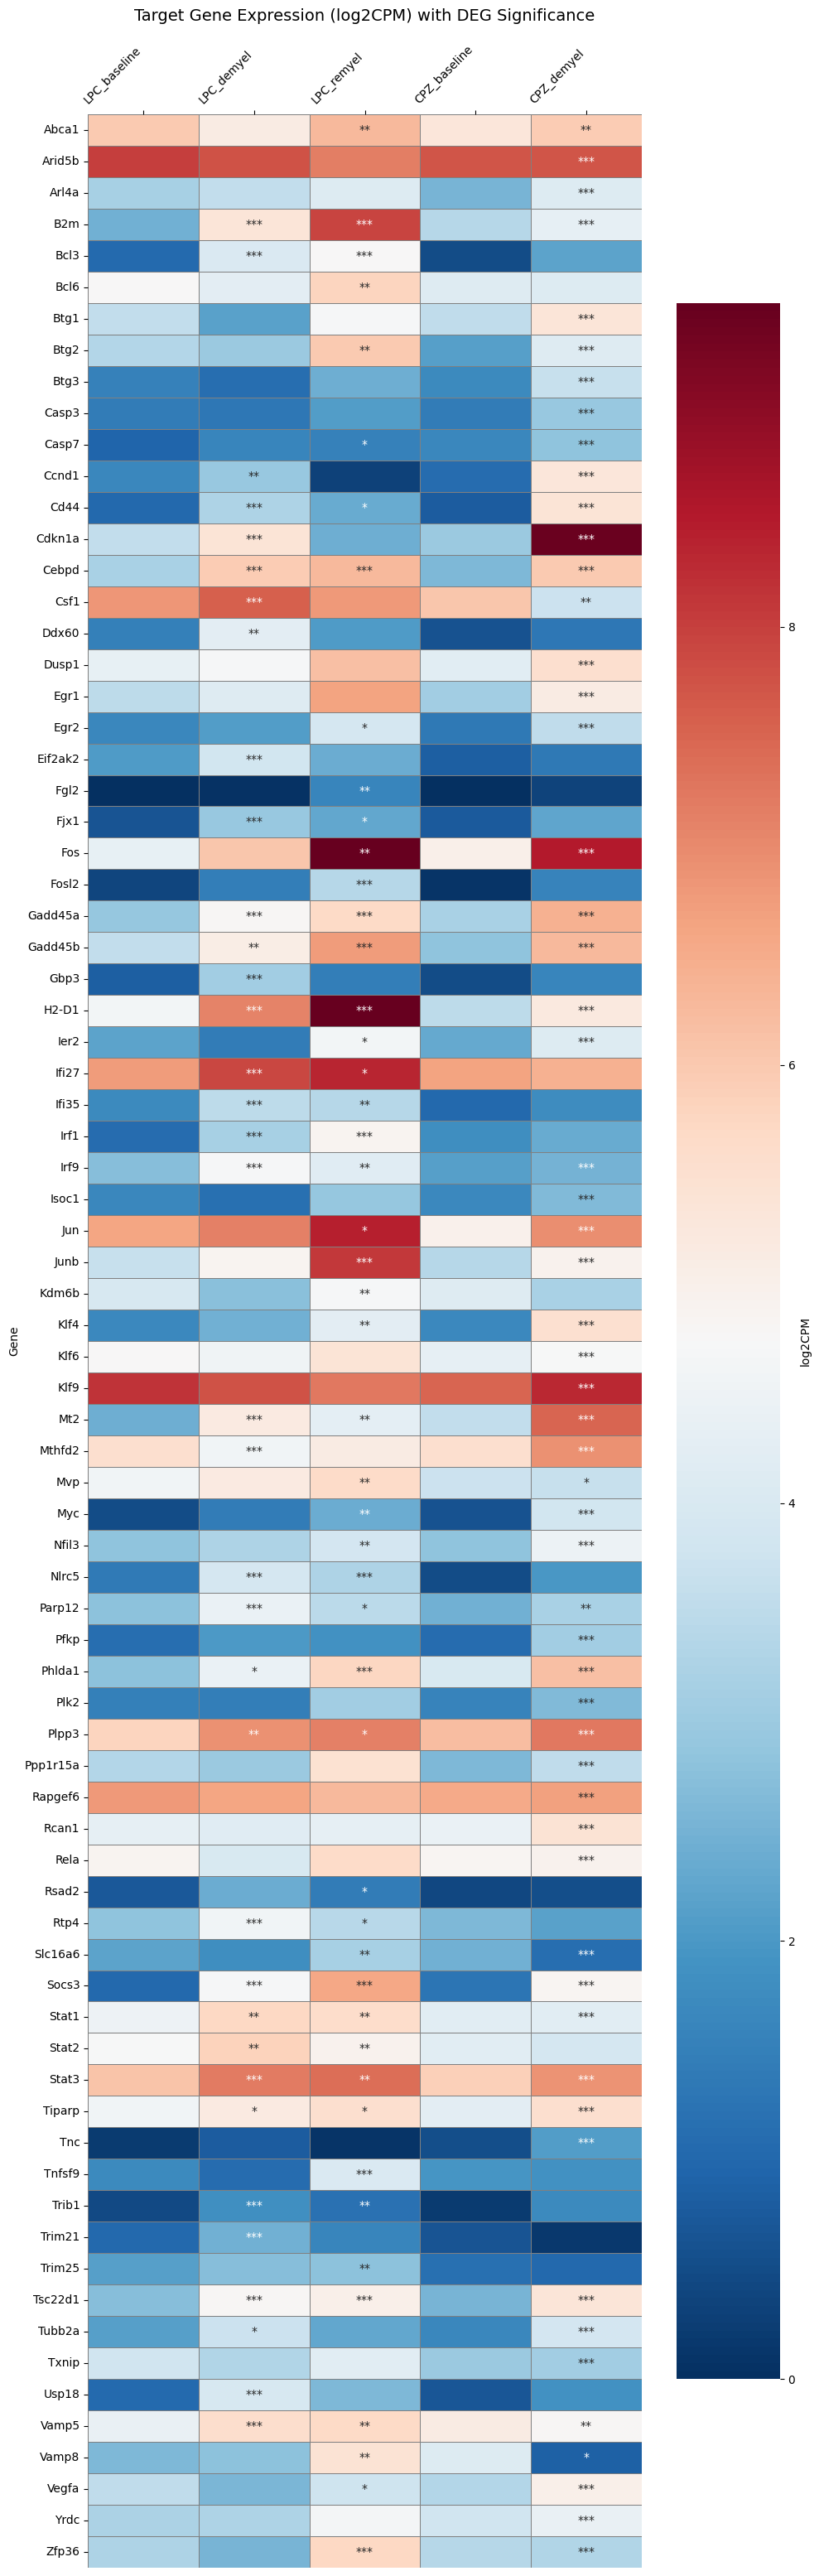

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define desired column order
column_order = ['LPC_baseline', 'LPC_demyel', 'LPC_remyel', 'CPZ_baseline', 'CPZ_demyel']

# Subset and reorder
heatmap_data = heatmap_df[column_order]
sig_map = sig_map[column_order]

# Create the heatmap
plt.figure(figsize=(10, len(heatmap_data) * 0.4))
ax = sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    annot=sig_map,
    fmt='',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'log2CPM'},
    xticklabels=True,
    yticklabels=True
)

# Customize labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title("Target Gene Expression (log2CPM) with DEG Significance", fontsize=14, pad=20)
ax.set_xlabel("")
ax.set_ylabel("Gene")

# Move x-axis labels to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.show()

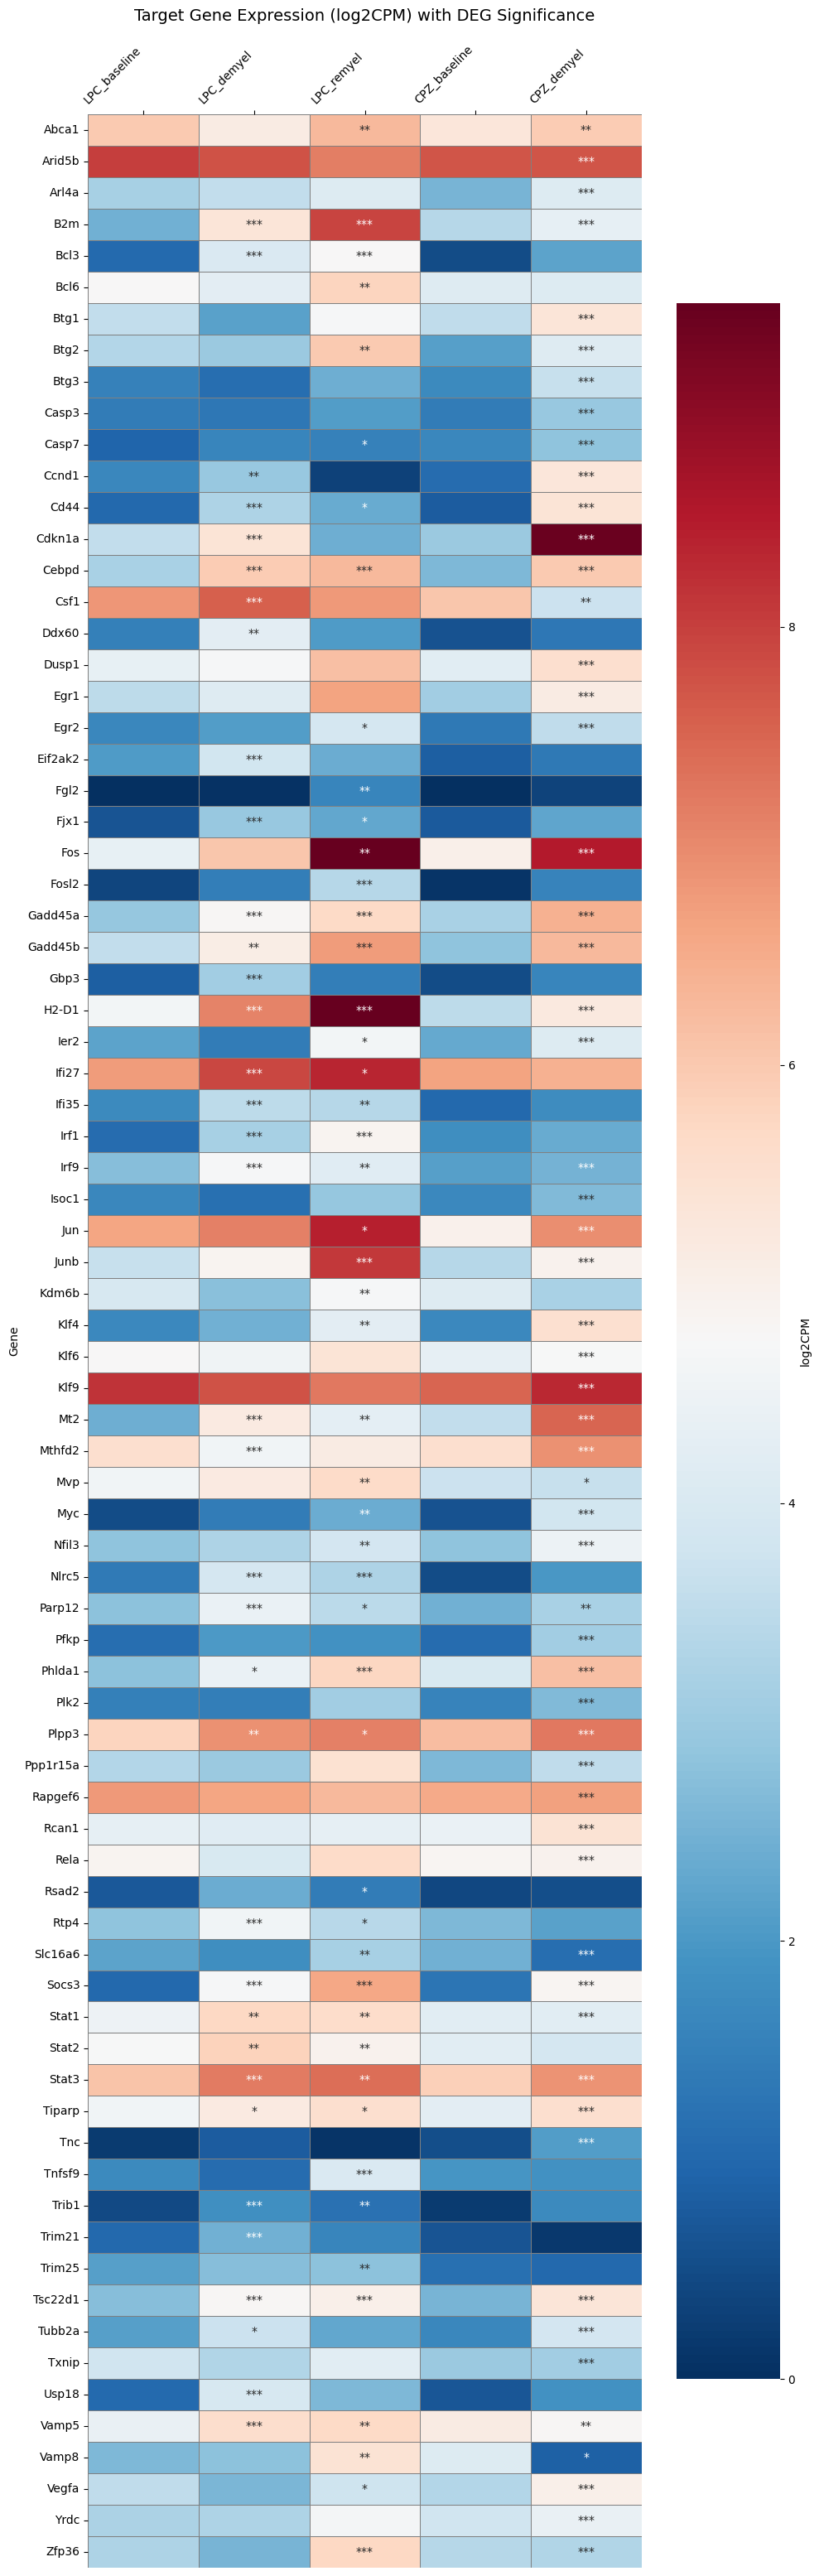

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define desired column order
column_order = ['LPC_baseline', 'LPC_demyel', 'LPC_remyel', 'CPZ_baseline', 'CPZ_demyel']

# Subset and reorder
heatmap_data = heatmap_df[column_order]
sig_map = sig_map[column_order]

# Create the heatmap
plt.figure(figsize=(10, len(heatmap_data) * 0.4))
ax = sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    annot=sig_map,
    fmt='',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'log2CPM'},
    xticklabels=True,
    yticklabels=True
)

# Customize labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title("Target Gene Expression (log2CPM) with DEG Significance", fontsize=14, pad=20)
ax.set_xlabel("")
ax.set_ylabel("Gene")

# Move x-axis labels to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.show()


In [49]:
# Save merged_df with DEGs and asterisks
merged_df.to_csv("merged_deg_expression_df.csv")

# Save pseudobulk log2CPM expression data
pseudobulk_df.to_csv("pseudobulk_log2CPM_df.csv")

# Save DEG significance data
deg_sig.to_csv("deg_significance_df.csv")

## Lets do it with R

In [72]:
%load_ext autoreload
%autoreload 2

import matplotlib
import matplotlib.pyplot as plt
import pertpy as pt
import scanpy as sc
import pandas as pd
import seaborn as sb

plt.rcParams["figure.figsize"] = (7, 7)
import numpy as np

sc.settings.verbosity = 3


import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.7,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

## r2py setup
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

## Define color palette
pal = sb.color_palette('Paired').as_hex()
design_palette = {'ACR':pal[3], 'CR':pal[7], 'AR':pal[9], 'joint_CR':pal[6]}
design_palette_df = pd.DataFrame(design_palette.values(), index =design_palette.keys() )
design_palette_df.columns = ['color']

import os,sys

figdir = './figures/'
if not os.path.exists(figdir):
    os.mkdir(figdir)
sc.settings.figdir = figdir

In [73]:
%%R
library(tidyverse)
library(reshape2)
library(patchwork)
library(ggrastr)
library(shadowtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(forcats)
library(data.table)

remove_x_axis <- function(){
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), axis.title.x = element_blank())  
}

remove_y_axis <- function(){
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.title.y = element_blank())  
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘reshape2’

The following object is masked from ‘package:tidyr’:

    smiths

data.table 1.16.4 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘data.table’

The following objects are masked from ‘package:reshape2’:

    dcast, melt

The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year

The following objects are masked from ‘package:dplyr’:

    between, first, last

The following object is masked from ‘package:purrr’:

    transpose



In [62]:
%%R

merged_df <- fread("merged_deg_expression_df.csv")

In [63]:
%%R

head(merged_df)

      V1          gene logFC_LPC_demyel Padj_LPC_demyel logFC_LPC_remyel
   <int>        <char>            <num>           <num>            <num>
1:     0 0610009B22Rik       0.31257840     0.618238775        0.2000952
2:     4 0610010K14Rik      -0.07389651     0.938292015        0.3111303
3:     5 0610012G03Rik       0.91084740     0.008919824        0.2286671
4:     9 0610040J01Rik      -3.10984252     0.097725882       -0.3275416
5:    14 1110004F10Rik       0.06718931     0.840715511       -0.1333746
6:    16 1110008P14Rik       0.24295712     0.749720146        0.6242309
   Padj_LPC_remyel logFC_Cupr_demyel Padj_Cupr_demyel DEG_LPC_demyel
             <num>             <num>            <num>         <lgcl>
1:      0.49856230         0.7832069      0.002058835          FALSE
2:      0.28695437         0.6190066      0.027335094          FALSE
3:      0.48139550         0.2733605      0.296830447           TRUE
4:      0.41121535        -3.8999444      0.001020450          FALSE
5:

In [64]:
%%R

# Define updated gene sets from each cytokine
TNFa_genes <- unique(c(
  # LPC_demyel
  "Cebpd", "Cdkn1a", "Fjx1", "Bcl3", "Socs3", "Irf1", "Trib1", "Cd44", "Tsc22d1",
  # LPC_remyel
  "Gadd45b", "Gadd45a", "Tsc22d1", "Irf1", "Tnfsf9", "Junb", "Zfp36", "Phlda1", "Fosl2",
  "Klf4", "Fos", "Slc16a6", "Abca1", "Myc", "Bcl6", "Kdm6b", "Nfil3", "Trib1", "Btg2",
  "Cebpd", "Socs3", "Bcl3",
  # CPZ_demyel
  "Cdkn1a", "Cebpd", "Ccnd1", "Btg3", "Cd44", "Vegfa", "Gadd45a", "Tsc22d1", "Nfil3",
  "Gadd45b", "Klf9", "Tubb2a", "Tiparp", "Egr2", "Socs3", "Plk2", "Klf4", "Myc", "Rcan1",
  "Btg1", "Tnc", "Phlda1", "Ppp1r15a", "Dusp1", "Egr1", "Fos", "Jun", "Plpp3", "Junb",
  "Klf6", "Btg2", "Rela", "Ier2", "Zfp36", "Yrdc"
))

IFNg_genes <- unique(c(
  # LPC_demyel
  "Ifi35", "Cdkn1a", "Irf9", "Mt2", "Rtp4", "Socs3", "Irf1", "Nlrc5", "Stat3",
  "H2-D1", "Gbp3", "B2m", "Eif2ak2", "Parp12", "Vamp5", "Usp18", "Trim21", "Ifi27",
  "Stat1", "Stat2", "Ddx60",
  # LPC_remyel
  "Socs3", "B2m", "Irf1", "H2-D1", "Nlrc5", "Fgl2", "Mvp", "Mt2", "Ifi35", "Stat1",
  "Stat3", "Vamp8", "Trim25", "Irf9", "Vamp5", "Stat2", "Rsad2", "Ifi27",
  # CPZ_demyel
  "Cdkn1a", "Mthfd2", "Mt2", "Casp3", "Casp7", "Socs3", "Arl4a", "Isoc1", "Stat3",
  "Btg1", "H2-D1", "Rapgef6", "Pfkp", "Txnip", "Arid5b", "B2m", "Irf9"
))

IFNa_genes <- unique(c(
  # LPC_demyel
  "Ifi35", "Irf9", "Rtp4", "Irf1", "Gbp3", "B2m", "Eif2ak2", "Parp12", "Usp18",
  "Trim21", "Csf1", "Ifi27", "Stat2", "Ddx60"
))

# All genes mentioned in annotations
all_genes <- unique(c(TNFa_genes, IFNg_genes, IFNa_genes))

# ---- 2. Create annotation dataframe (wide) ----
annotation_df <- data.frame(
  gene = all_genes,
  `TNF-α` = all_genes %in% TNFa_genes,
  `IFN-γ` = all_genes %in% IFNg_genes,
  `IFN-α` = all_genes %in% IFNa_genes
)

colnames(annotation_df)

[1] "gene"  "TNF.α" "IFN.γ" "IFN.α"


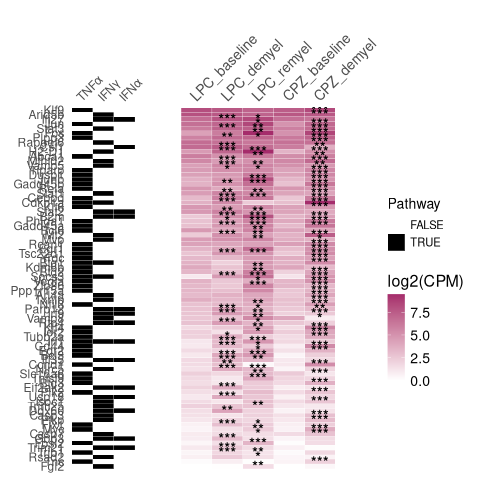

In [65]:
%%R

# Gene list you want to plot
target_genes <- unique(c(TNFa_genes, IFNg_genes, IFNa_genes))

# Reorder columns
group_order <- c("LPC_baseline", "LPC_demyel", "LPC_remyel", "CPZ_baseline", "CPZ_demyel")

# Select expression values and gather
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_LPC_demyel, Sig_LPC_remyel, Sig_Cupr_demyel) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM")

# Add significance asterisks
df_expr <- df_expr %>%
  mutate(Signif = case_when(
    Group == "LPC_demyel" ~ Sig_LPC_demyel,
    Group == "LPC_remyel" ~ Sig_LPC_remyel,
    Group == "CPZ_demyel" ~ Sig_Cupr_demyel,
    TRUE ~ ""
  ))

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Reorder genes for plotting
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `TNFα` = `TNF.α`,
  `IFNγ` = `IFN.γ`,
  `IFNα` = `IFN.α`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("TNFα", "IFNγ", "IFNα"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=12),  # consistent with heatmap
    axis.text.y = element_text(size = 12),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- 2. Heatmap (hide gene labels) ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Signif), color = "black", size = 5, vjust = 0.5, fontface = "bold") +  # bigger, bold asterisks
  scale_fill_gradient(low = "white", high = "#a52c6b", name = "log2(CPM)") +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 14),  # bigger text
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 14),       # legend text size
    legend.title = element_text(size = 16),      # legend title size
    plot.title = element_text(hjust = 0.5, size = 16)
  ) +
  coord_fixed(ratio = 0.15)

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(legend.position = "right",
        text = element_text(size = 14))   # increase all base text size as a backup

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("final_heatmap_corrections.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

In [66]:
%%R
summary(df_expr$log2CPM)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.090   3.535   3.687   5.104   9.479 


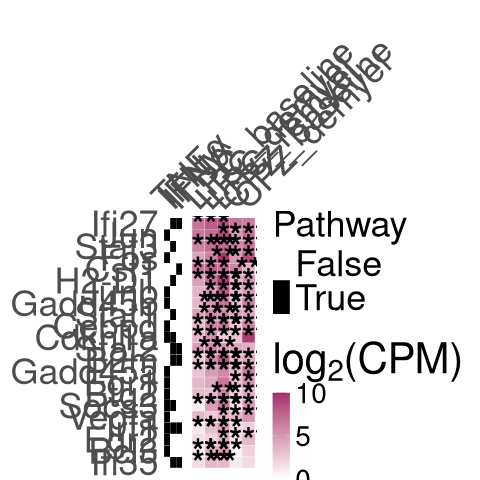

In [67]:
%%R

# REDUCED HEATMAP

genes_to_keep <- c(
  "Ifi27", "Jun", "Stat3", "Fos", "Csf1", "H2-D1", "Junb", "Stat1", "Gadd45b", "Cdkn1a", 
  "Cebpd", "Stat2", "B2m", "Gadd45a", "Egr1", "Btg2", "Socs3", "Vegfa", "Irf1", 
  "Cd22", "Bcl3", "Egr2", "Ifi35"
)

# Gene list you want to plot
target_genes <- genes_to_keep

# Reorder columns
group_order <- c("LPC_baseline", "LPC_demyel", "LPC_remyel", "CPZ_baseline", "CPZ_demyel")

# Select expression values and gather
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_LPC_demyel, Sig_LPC_remyel, Sig_Cupr_demyel,
         logFC_LPC_demyel, logFC_LPC_remyel, logFC_Cupr_demyel) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    # assign asterisk significance
    Signif = case_when(
      Group == "LPC_demyel" ~ Sig_LPC_demyel,
      Group == "LPC_remyel" ~ Sig_LPC_remyel,
      Group == "CPZ_demyel" ~ Sig_Cupr_demyel,
      TRUE ~ ""   # no sig for baselines
    ),
    # match logFC value
    logFC_val = case_when(
      Group == "LPC_demyel" ~ logFC_LPC_demyel,
      Group == "LPC_remyel" ~ logFC_LPC_remyel,
      Group == "CPZ_demyel" ~ logFC_Cupr_demyel,
      TRUE ~ NA_real_        # NA for baselines
    ),
    # color asterisks by direction
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,   # no asterisk shown
      logFC_val > 0 ~ "blue",         # upregulated
      logFC_val < 0 ~ "red",          # downregulated
      TRUE ~ "blue"
    )
  )

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Reorder genes for plotting
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `TNFα` = `TNF.α`,
  `IFNγ` = `IFN.γ`,
  `IFNα` = `IFN.α`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("TNFα", "IFNγ", "IFNα"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    labels = c("TRUE" = "True", "FALSE" = "False"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=36),
    axis.text.y = element_text(size = 36),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5),
    legend.text = element_text(size = 36),
    legend.title = element_text(size = 36)
  )

# ---- 2. Heatmap (hide gene labels) ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Signif), color = "black", size = 12, vjust = 0.5, fontface = "bold") +  # bigger, bold asterisks
  scale_fill_gradient(low = "white", high = "#a52c6b", name = expression(log[2]*"(CPM)"),
                        breaks = c(0, 5, 10), limits = c(0, 10)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 36),  # bigger text
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 28),       # legend text size
    legend.title = element_text(size = 42),      # legend title size
    plot.title = element_text(hjust = 0.5, size = 16)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(legend.position = "right",
        text = element_text(size = 14))   # increase all base text size as a backup

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("final_heatmap_reduced.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

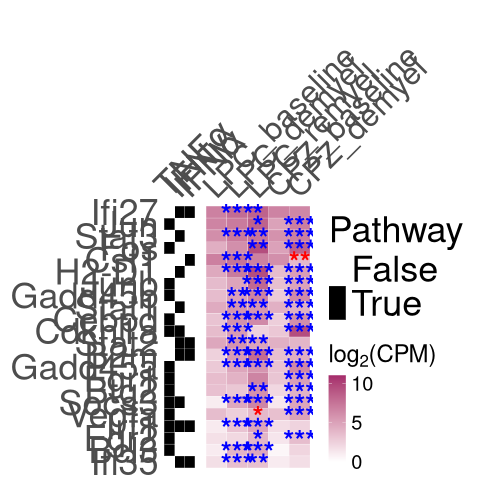

In [68]:
%%R

# REDUCED HEATMAP

genes_to_keep <- c(
  "Ifi27", "Jun", "Stat3", "Fos", "Csf1", "H2-D1", "Junb", "Stat1", "Gadd45b", "Cdkn1a", 
  "Cebpd", "Stat2", "B2m", "Gadd45a", "Egr1", "Btg2", "Socs3", "Vegfa", "Irf1", 
  "Cd22", "Bcl3", "Egr2", "Ifi35"
)

# Gene list you want to plot
target_genes <- genes_to_keep

# Reorder columns
group_order <- c("LPC_baseline", "LPC_demyel", "LPC_remyel", "CPZ_baseline", "CPZ_demyel")

df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_LPC_demyel, Sig_LPC_remyel, Sig_Cupr_demyel,
         logFC_LPC_demyel, logFC_LPC_remyel, logFC_Cupr_demyel) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "LPC_demyel"   ~ Sig_LPC_demyel,
      Group == "LPC_remyel"   ~ Sig_LPC_remyel,
      Group == "CPZ_demyel"   ~ Sig_Cupr_demyel,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "LPC_demyel"   ~ logFC_LPC_demyel,
      Group == "LPC_remyel"   ~ logFC_LPC_remyel,
      Group == "CPZ_demyel"   ~ logFC_Cupr_demyel,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,
      logFC_val > 0 ~ "blue",   # upregulated
      logFC_val < 0 ~ "red",    # downregulated
      TRUE ~ "blue"
    )
  )

# Factor ordering
df_expr$Group <- factor(df_expr$Group, levels = group_order)
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `TNFα` = `TNF.α`,
  `IFNγ` = `IFN.γ`,
  `IFNα` = `IFN.α`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("TNFα", "IFNγ", "IFNα"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    labels = c("TRUE" = "True", "FALSE" = "False"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=36),
    axis.text.y = element_text(size = 36),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5),
    legend.text = element_text(size = 36),
    legend.title = element_text(size = 36)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )
# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("final_heatmap_reduced_colored.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

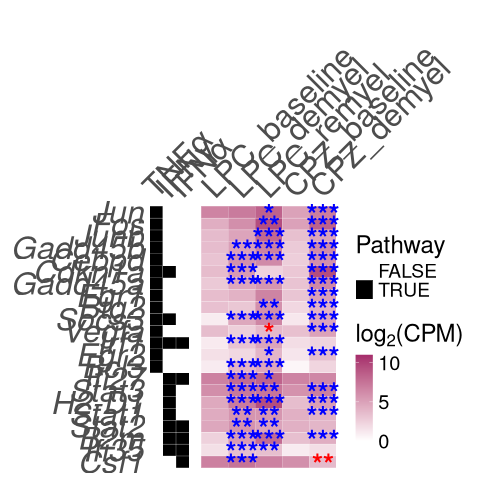

In [70]:
%%R

genes_to_keep <- c(
  "Ifi27", "Jun", "Stat3", "Fos", "Csf1", "H2-D1", "Junb", "Stat1", "Gadd45b", "Cdkn1a", 
  "Cebpd", "Stat2", "B2m", "Gadd45a", "Egr1", "Btg2", "Socs3", "Vegfa", "Irf1", 
  "Cd22", "Bcl3", "Egr2", "Ifi35"
)

# Gene list you want to plot
target_genes <- genes_to_keep

# Reorder columns
group_order <- c("LPC_baseline", "LPC_demyel", "LPC_remyel", "CPZ_baseline", "CPZ_demyel")

df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_LPC_demyel, Sig_LPC_remyel, Sig_Cupr_demyel,
         logFC_LPC_demyel, logFC_LPC_remyel, logFC_Cupr_demyel) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "LPC_demyel"   ~ Sig_LPC_demyel,
      Group == "LPC_remyel"   ~ Sig_LPC_remyel,
      Group == "CPZ_demyel"   ~ Sig_Cupr_demyel,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "LPC_demyel"   ~ logFC_LPC_demyel,
      Group == "LPC_remyel"   ~ logFC_LPC_remyel,
      Group == "CPZ_demyel"   ~ logFC_Cupr_demyel,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,
      logFC_val > 0 ~ "blue",   # upregulated
      logFC_val < 0 ~ "red",    # downregulated
      TRUE ~ "blue"
    )
  )




# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `TNFα` = `TNF.α`,
  `IFNγ` = `IFN.γ`,
  `IFNα` = `IFN.α`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# ---- Calculate mean log2CPM per gene for ordering ----
gene_mean_expr <- df_expr %>%
  group_by(gene) %>%
  summarize(mean_log2CPM = mean(log2CPM, na.rm = TRUE), .groups = "drop")

# ---- Create gene ordering by pathway priority, then by mean logCPM ----
# Start with all genes and their pathway memberships
gene_pathway_order <- tibble(gene = unique(df_expr$gene)) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  left_join(gene_mean_expr, by = "gene") %>%
  mutate(
    # Assign pathway priority: 1 = MTORC1, 2 = Glycolysis, 3 = Hypoxia, 4 = None
    pathway_priority = case_when(
      TNFα ~ 1,
      IFNγ ~ 2,
      IFNα ~ 3,
      TRUE ~ 4
    )
  ) %>%
  arrange(pathway_priority, desc(mean_log2CPM))

# Extract the ordered gene levels and reverse them
gene_levels <- rev(gene_pathway_order$gene)

# Apply the custom gene order to df_expr
df_expr$gene <- factor(df_expr$gene, levels = gene_levels)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("TNFα", "IFNγ", "IFNα"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=32),  # consistent with heatmap
    axis.text.y = element_text(size = 32, face = "italic"),   # ← **Make gene names italic**
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("MOL_heatmap_ordered.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

## Now do CPZ genes:

In [74]:
%%R

# Load the data.table package
library(data.table)

Cupr_de <- fread("./files/filtered_fgseaResSignificant_Cupr_demyel_MOL_NEW.csv")

In [75]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
Cupr_de$pathway <- gsub("^HALLMARK_", "", Cupr_de$pathway)
head(Cupr_de)

                             pathway         pval        padj   log2err
                              <char>        <num>       <num>     <num>
1:                   APICAL_JUNCTION 0.0095090259 0.029206294 0.3807304
2:                         APOPTOSIS 0.0032777164 0.013812758 0.4317077
3:                        DNA_REPAIR 0.0003170417 0.002165469 0.4984931
4:                       E2F_TARGETS 0.0004028779 0.002165469 0.4984931
5: EPITHELIAL_MESENCHYMAL_TRANSITION 0.0082391261 0.029206294 0.3807304
6:           ESTROGEN_RESPONSE_EARLY 0.0146994584 0.035679774 0.3807304
           ES       NES  size
        <num>     <num> <int>
1: -0.3009787 -1.718554    47
2:  0.3642422  1.880353    49
3:  0.4312876  2.121297    42
4:  0.3828979  2.081106    58
5:  0.3568507  1.755178    42
6:  0.3104098  1.672379    56
                                                                                                                                                                                        

In [ ]:
%%R
unique(Cupr_de$pathway)

 [1] "APICAL_JUNCTION"                  

In [87]:
%%R

# Define the pathway of interest
pathway_of_interest <- "MYC_TARGETS_V1"

# Subset the data to get the row with the specified pathway
selected_row <- Cupr_de[Cupr_de$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list, collapse = ", "))

Odc1, Eprs, Gnl3, Ifrd1, Rrp9, Xpot, Ddx18, Myc, Hnrnpc, Eif2s2, Serbp1, Mcm7, Pwp1, Syncrip, Ddx21, Sf3b3, Nolc1, Nop56, Sf3a1, Eif3b, Ube2e1, Mrps18b, Hnrnpu, Abce1, Srpk1, Mrpl9, Psmd1, Rsl1d1, Rad23b, Ncbp1, Hnrnpd, Phb2, Lsm2, Apex1, Tardbp, Usp1, Cdk4, Etf1, Psmc6, Tomm70a, Dhx15, Eif2s1, Dut, Tra2b, Srsf7, Mrpl23, Eif4e, Rack1, Hspd1, Rnps1, Rfc4, Rrm1, Ssb, Tufm, Got2, Nhp2, Exosc7, Ran, Trim28, G3bp1, Psmd14, C1qbp, Cct2, Kars, Hspe1, Nap1l1, Eif4a1, Psmc4, Snrpd1, Cct4, Cad, Npm1, Ctps, Nme1, Rpl18, Cct7, Eif3d, Rps2, Eef1b2, Pcna, Cct3

In [88]:
%%R

# Define the pathway of interest
pathway_of_interest <- "P53_PATHWAY"

# Subset the data to get the row with the specified pathway
selected_row <- Cupr_de[Cupr_de$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list, collapse = ", "))

Nupr1, Cdkn1a, Aen, Ccng1, Ddit3, Notch1, Gadd45a, Tsc22d1, Cdh13, Rrp8, Plk2, Klf4, Trp53, Ephx1, Slc3a2, Trib3, Ip6k2, Zmat3, Mdm2, Traf4, Btg1, Cdkn2aip, Hexim1, Bax, Dnttip2, Ppp1r15a, Steap3, Txnip, Fos, Jun, Dcxr, Xpc, Nol8, Btg2, Sec61a1, Slc19a2, Rchy1, Sp1, Wrap73, Prkab1, Blcap, Csrnp2, Vwa5a, Ccnk, Rps27l

In [89]:
%%R

# Define the pathway of interest
pathway_of_interest <- "UNFOLDED_PROTEIN_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- Cupr_de[Cupr_de$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list, collapse = ", "))

Slc1a4, Slc7a5, Cebpg, Vegfa, Asns, Mthfd2, Tubb2a, Rrp9, Xpot, Bag3, Hspa9, Eif4ebp1, Nolc1, Nop14, Nop56, Sec11a, Srprb, Tars, Exosc1, Atf4, Wfs1, Kif5b, Ddx10, Dnajb9, Eif2s1, Hspa5, Sdad1, Cnot6, Eif4e, Xbp1, Lsm1, Gosr2, Exosc10, Nhp2, Sec31a

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "DNA_REPAIR"

# Subset the data to get the row with the specified pathway
selected_row <- Cupr_de[Cupr_de$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list, collapse = ", "))

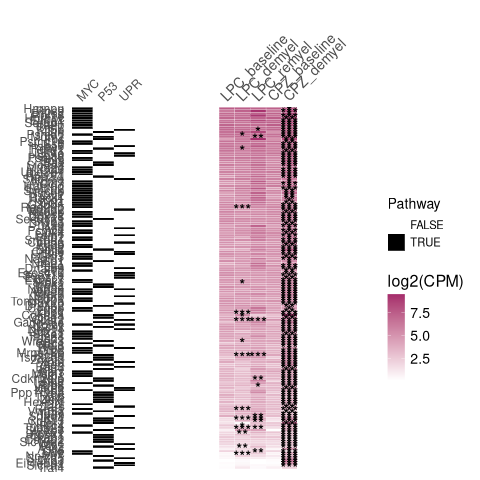

In [71]:
%%R

# Define gene sets
myc_genes <- c("Odc1", "Eprs", "Gnl3", "Ifrd1", "Rrp9", "Xpot", "Ddx18", "Myc", "Hnrnpc",
               "Eif2s2", "Serbp1", "Mcm7", "Pwp1", "Syncrip", "Ddx21", "Sf3b3", "Nolc1",
               "Nop56", "Sf3a1", "Eif3b", "Ube2e1", "Mrps18b", "Hnrnpu", "Abce1", "Srpk1",
               "Mrpl9", "Psmd1", "Rsl1d1", "Rad23b", "Ncbp1", "Hnrnpd", "Phb2", "Lsm2",
               "Apex1", "Tardbp", "Usp1", "Cdk4", "Etf1", "Psmc6", "Tomm70a", "Dhx15",
               "Eif2s1", "Dut", "Tra2b", "Srsf7", "Mrpl23", "Eif4e", "Rack1", "Hspd1",
               "Rnps1", "Rfc4", "Rrm1", "Ssb", "Tufm", "Got2", "Nhp2", "Exosc7", "Ran",
               "Trim28", "G3bp1", "Psmd14", "C1qbp", "Cct2", "Kars", "Hspe1", "Nap1l1",
               "Eif4a1", "Psmc4", "Snrpd1", "Cct4", "Cad", "Npm1", "Ctps", "Nme1", "Rpl18",
               "Cct7", "Eif3d", "Rps2", "Eef1b2", "Pcna", "Cct3")

p53_genes <- c("Nupr1", "Cdkn1a", "Aen", "Ccng1", "Ddit3", "Notch1", "Gadd45a", "Tsc22d1",
               "Cdh13", "Rrp8", "Plk2", "Klf4", "Trp53", "Ephx1", "Slc3a2", "Trib3", "Ip6k2",
               "Zmat3", "Mdm2", "Traf4", "Btg1", "Cdkn2aip", "Hexim1", "Bax", "Dnttip2",
               "Ppp1r15a", "Steap3", "Txnip", "Fos", "Jun", "Dcxr", "Xpc", "Nol8", "Btg2",
               "Sec61a1", "Slc19a2", "Rchy1", "Sp1", "Wrap73", "Prkab1", "Blcap", "Csrnp2",
               "Vwa5a", "Ccnk", "Rps27l")

upr_genes <- c("Slc1a4", "Slc7a5", "Cebpg", "Vegfa", "Asns", "Mthfd2", "Tubb2a", "Rrp9",
               "Xpot", "Bag3", "Hspa9", "Eif4ebp1", "Nolc1", "Nop14", "Nop56", "Sec11a",
               "Srprb", "Tars", "Exosc1", "Atf4", "Wfs1", "Kif5b", "Ddx10", "Dnajb9",
               "Eif2s1", "Hspa5", "Sdad1", "Cnot6", "Eif4e", "Xbp1", "Lsm1", "Gosr2",
               "Exosc10", "Nhp2", "Sec31a")


# All genes mentioned in the three pathways
all_genes <- unique(c(myc_genes, p53_genes, upr_genes))

# Create annotation dataframe
annotation_df <- data.frame(
  gene = all_genes,
  MYC = all_genes %in% myc_genes,
  P53 = all_genes %in% p53_genes,
  UPR = all_genes %in% upr_genes
)

target_genes <- all_genes

# Reorder columns
group_order <- c("LPC_baseline", "LPC_demyel", "LPC_remyel", "CPZ_baseline", "CPZ_demyel")

# Select expression values and gather
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_LPC_demyel, Sig_LPC_remyel, Sig_Cupr_demyel) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM")

# Add significance asterisks
df_expr <- df_expr %>%
  mutate(Signif = case_when(
    Group == "LPC_demyel" ~ Sig_LPC_demyel,
    Group == "LPC_remyel" ~ Sig_LPC_remyel,
    Group == "CPZ_demyel" ~ Sig_Cupr_demyel,
    TRUE ~ ""
  ))

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Reorder genes for plotting
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)


# Fix column labels to display pathway names
annotation_long <- annotation_df %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Set factor order for your plot
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("MYC", "P53", "UPR"))
  )


# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=12),  # consistent with heatmap
    axis.text.y = element_text(size = 12),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- 2. Heatmap (hide gene labels) ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Signif), color = "black", size = 5, vjust = 0.5, fontface = "bold") +  # bigger, bold asterisks
  scale_fill_gradient(low = "white", high = "#a52c6b", name = "log2(CPM)") +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 14),  # bigger text
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 14),       # legend text size
    legend.title = element_text(size = 16),      # legend title size
    plot.title = element_text(hjust = 0.5, size = 16)
  ) +
  coord_fixed(ratio = 0.15)

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(legend.position = "right",
        text = element_text(size = 14))   # increase all base text size as a backup

# ---- 4. Print & save ----
print(final_plot)

# Optional save
#ggsave("final_heatmap_corrections.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

In [72]:
%%R

# Add pathway label to each list
myc_df <- data.frame(gene = myc_genes, pathway = "MYC")
p53_df <- data.frame(gene = p53_genes, pathway = "P53")
upr_df <- data.frame(gene = upr_genes, pathway = "UPR")

# Combine into one dataframe
pathway_df <- bind_rows(myc_df, p53_df, upr_df)

# Step 2: Join with expression data
# Assumes `merged_df` contains log2CPM values per condition
# Use average expression (or a relevant group) to sort
avg_expr <- merged_df %>%
  rowwise() %>%
  mutate(avg_expr = mean(c_across(starts_with("LPC_")), na.rm = TRUE)) %>%
  ungroup() %>%
  select(gene, avg_expr)

# Merge gene sets with expression
pathway_expr <- left_join(pathway_df, avg_expr, by = "gene")

# Step 3: Select top 10 genes per pathway
top_pathway_genes <- pathway_expr %>%
  group_by(pathway) %>%
  arrange(desc(avg_expr)) %>%
  slice_head(n = 10) %>%
  pull(gene)

# Print or save the result
print(top_pathway_genes)

 [1] "Rps2"    "Rpl18"   "Hnrnpu"  "Eif4a1"  "Eif2s2"  "Hnrnpc"  "Srsf7"  
 [8] "Serbp1"  "Tra2b"   "Psmd1"   "Jun"     "Fos"     "Mdm2"    "Rchy1"  
[15] "Slc3a2"  "Bax"     "Rps27l"  "Sec61a1" "Dnttip2" "Sp1"     "Kif5b"  
[22] "Hspa5"   "Eif4e"   "Hspa9"   "Sec11a"  "Atf4"    "Lsm1"    "Dnajb9" 
[29] "Eif2s1"  "Cnot6"  


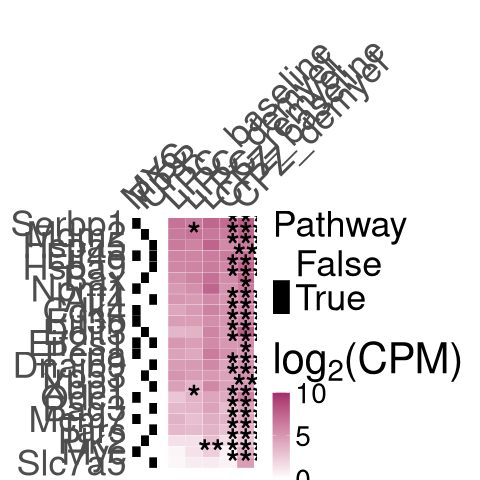

In [73]:
%%R

# REDUCED HEATMAP

genes_to_keep <- c(
  "Myc", "Odc1", "Mcm7", "Npm1", "Eif4e", "Eif3b", "Cdk4", "Pcna", "Serbp1",
  "Mdm2", "Ddit3", "Plk2", "Trp53", "Bax",
  "Atf4", "Xbp1", "Hspa5", "Eif2s1", "Dnajb9", "Hspa9", "Bag3", "Slc7a5", "Tars"
)

# Gene list you want to plot
target_genes <- genes_to_keep

# Reorder columns
group_order <- c("LPC_baseline", "LPC_demyel", "LPC_remyel", "CPZ_baseline", "CPZ_demyel")

# Create annotation dataframe
annotation_df <- data.frame(
  gene = all_genes,
  MYC = all_genes %in% myc_genes,
  P53 = all_genes %in% p53_genes,
  UPR = all_genes %in% upr_genes
)


# Select expression values and gather
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_LPC_demyel, Sig_LPC_remyel, Sig_Cupr_demyel) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM")

# Add significance asterisks
df_expr <- df_expr %>%
  mutate(Signif = case_when(
    Group == "LPC_demyel" ~ Sig_LPC_demyel,
    Group == "LPC_remyel" ~ Sig_LPC_remyel,
    Group == "CPZ_demyel" ~ Sig_Cupr_demyel,
    TRUE ~ ""
  ))

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Reorder genes for plotting
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix column labels to display pathway names
annotation_long <- annotation_df %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Set factor order for your plot
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("MYC", "P53", "UPR"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    labels = c("TRUE" = "True", "FALSE" = "False"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=36),
    axis.text.y = element_text(size = 36),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5),
    legend.text = element_text(size = 36),
    legend.title = element_text(size = 36)
  )

# ---- 2. Heatmap (hide gene labels) ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Signif), color = "black", size = 12, vjust = 0.5, fontface = "bold") +  # bigger, bold asterisks
  scale_fill_gradient(low = "white", high = "#a52c6b", name = expression(log[2]*"(CPM)"),
                        breaks = c(0, 5, 10), limits = c(0, 10)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 36),  # bigger text
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 28),       # legend text size
    legend.title = element_text(size = 42),      # legend title size
    plot.title = element_text(hjust = 0.5, size = 16)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(legend.position = "right",
        text = element_text(size = 14))   # increase all base text size as a backup

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("CPZ_pathway_heatmap_reduced.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

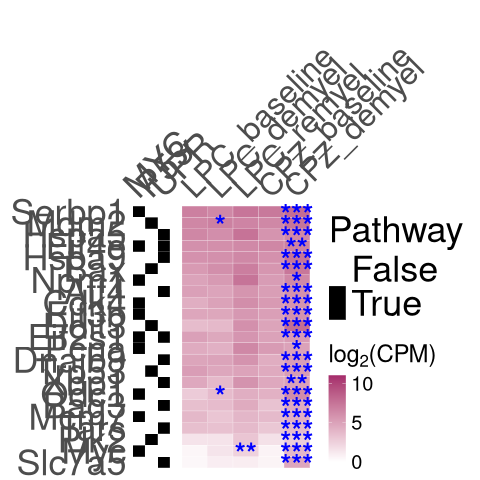

In [74]:
%%R

genes_to_keep <- c(
  "Myc", "Odc1", "Mcm7", "Npm1", "Eif4e", "Eif3b", "Cdk4", "Pcna", "Serbp1",
  "Mdm2", "Ddit3", "Plk2", "Trp53", "Bax",
  "Atf4", "Xbp1", "Hspa5", "Eif2s1", "Dnajb9", "Hspa9", "Bag3", "Slc7a5", "Tars"
)

# Gene list you want to plot
target_genes <- genes_to_keep

# Reorder columns
group_order <- c("LPC_baseline", "LPC_demyel", "LPC_remyel", "CPZ_baseline", "CPZ_demyel")

df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_LPC_demyel, Sig_LPC_remyel, Sig_Cupr_demyel,
         logFC_LPC_demyel, logFC_LPC_remyel, logFC_Cupr_demyel) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "LPC_demyel"   ~ Sig_LPC_demyel,
      Group == "LPC_remyel"   ~ Sig_LPC_remyel,
      Group == "CPZ_demyel"   ~ Sig_Cupr_demyel,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "LPC_demyel"   ~ logFC_LPC_demyel,
      Group == "LPC_remyel"   ~ logFC_LPC_remyel,
      Group == "CPZ_demyel"   ~ logFC_Cupr_demyel,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,
      logFC_val > 0 ~ "blue",   # upregulated
      logFC_val < 0 ~ "red",    # downregulated
      TRUE ~ "blue"
    )
  )

# Factor ordering
df_expr$Group <- factor(df_expr$Group, levels = group_order)
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix column labels to display pathway names
annotation_long <- annotation_df %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Set factor order for your plot
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("MYC", "P53", "UPR"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    labels = c("TRUE" = "True", "FALSE" = "False"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=36),
    axis.text.y = element_text(size = 36),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5),
    legend.text = element_text(size = 36),
    legend.title = element_text(size = 36)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )
# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("CPZ_pathway_heatmap_reduced_colored.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

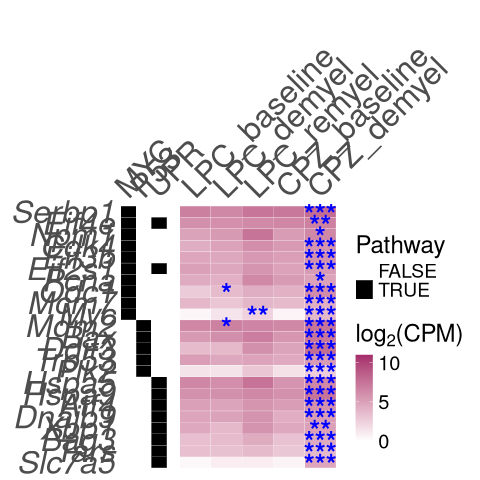

In [76]:
%%R

genes_to_keep <- c(
  "Myc", "Odc1", "Mcm7", "Npm1", "Eif4e", "Eif3b", "Cdk4", "Pcna", "Serbp1",
  "Mdm2", "Ddit3", "Plk2", "Trp53", "Bax",
  "Atf4", "Xbp1", "Hspa5", "Eif2s1", "Dnajb9", "Hspa9", "Bag3", "Slc7a5", "Tars"
)

# Gene list you want to plot
target_genes <- genes_to_keep

# Reorder columns
group_order <- c("LPC_baseline", "LPC_demyel", "LPC_remyel", "CPZ_baseline", "CPZ_demyel")

df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_LPC_demyel, Sig_LPC_remyel, Sig_Cupr_demyel,
         logFC_LPC_demyel, logFC_LPC_remyel, logFC_Cupr_demyel) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "LPC_demyel"   ~ Sig_LPC_demyel,
      Group == "LPC_remyel"   ~ Sig_LPC_remyel,
      Group == "CPZ_demyel"   ~ Sig_Cupr_demyel,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "LPC_demyel"   ~ logFC_LPC_demyel,
      Group == "LPC_remyel"   ~ logFC_LPC_remyel,
      Group == "CPZ_demyel"   ~ logFC_Cupr_demyel,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,
      logFC_val > 0 ~ "blue",   # upregulated
      logFC_val < 0 ~ "red",    # downregulated
      TRUE ~ "blue"
    )
  )

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `MYC` = `MYC`,
  `P53` = `P53`,
  `UPR` = `UPR`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# ---- Calculate mean log2CPM per gene for ordering ----
gene_mean_expr <- df_expr %>%
  group_by(gene) %>%
  summarize(mean_log2CPM = mean(log2CPM, na.rm = TRUE), .groups = "drop")

# ---- Create gene ordering by pathway priority, then by mean logCPM ----
# Start with all genes and their pathway memberships
gene_pathway_order <- tibble(gene = unique(df_expr$gene)) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  left_join(gene_mean_expr, by = "gene") %>%
  mutate(
    # Assign pathway priority: 1 = MTORC1, 2 = Glycolysis, 3 = Hypoxia, 4 = None
    pathway_priority = case_when(
      MYC ~ 1,
      P53 ~ 2,
      UPR ~ 3,
      TRUE ~ 4
    )
  ) %>%
  arrange(pathway_priority, desc(mean_log2CPM))

# Extract the ordered gene levels and reverse them
gene_levels <- rev(gene_pathway_order$gene)

# Apply the custom gene order to df_expr
df_expr$gene <- factor(df_expr$gene, levels = gene_levels)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("MYC", "P53", "UPR"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=32),  # consistent with heatmap
    axis.text.y = element_text(size = 32, face = "italic"),   # ← **Make gene names italic**
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("MOL_heatmap_ordered2.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)